# Mapping the Linear Representation Hypothesis in Vision Models

**6.8300 Advances in Computer Vision — Final Project**

Ayela Chughtai, Sarah Mokhtar


## Setup


In [1]:
# Check GPU and install dependencies
!nvidia-smi
!pip install -q open_clip_torch datasets scikit-learn umap-learn matplotlib seaborn torchvision
!pip install scikit-dimension


Sat May  2 12:24:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:61:00.0 Off |                    0 |
| N/A   34C    P8             33W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import sys
import json
import random
import hashlib
import pickle
import shutil
import subprocess
import warnings
from pathlib import Path
from io import BytesIO
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap
import skdim
import requests
from PIL import Image
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import open_clip

# Suppress noisy warnings
warnings.filterwarnings("ignore", message="n_jobs value")

# Global config
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})


/orcd/software/core/001/pkg/miniforge/25.11.0-0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using: cuda


## Load CLIP


In [3]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k",
)
model = model.to(device)
model.eval()


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [4]:
def extract_features(images, batch_size=64):
    """Extract L2-normalised CLIP image features. Returns an (N, 512) numpy array."""
    all_features = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        batch_tensors = torch.stack([preprocess(img) for img in batch]).to(device)

        with torch.no_grad():
            features = model.encode_image(batch_tensors)
            features = features / features.norm(dim=-1, keepdim=True)

        all_features.append(features.cpu().numpy())

    return np.concatenate(all_features, axis=0)


In [30]:
# save figs

FIGURE_DIR = os.path.join(os.getcwd(), "figures")
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_fig(name, fig=None, dpi=200):
    """Save current figure as PNG + PDF. Call before plt.show()."""
    if fig is None:
        fig = plt.gcf()
    fig.savefig(os.path.join(FIGURE_DIR, f"{name}.png"), dpi=dpi, bbox_inches='tight')
    fig.savefig(os.path.join(FIGURE_DIR, f"{name}.pdf"), bbox_inches='tight')
    print(f"Saved {name}.png + .pdf")

## Probe Infrastructure (5-Fold Cross-Validation)


In [6]:
# ============================================================
# Unified probe functions 
# ============================================================
N_FOLDS = 5

def run_linear_probe_cv(features, labels, n_folds=N_FOLDS, random_state=42):
    """5-fold CV logistic regression. Returns (mean_acc, std_acc, mean_auc, std_auc)."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    acc_scores = []
    auc_scores = []
    for train_idx, test_idx in skf.split(features, labels):
        X_train, X_test = features[train_idx], features[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]
        clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=random_state)
        clf.fit(X_train, y_train)
        acc_scores.append(accuracy_score(y_test, clf.predict(X_test)))
        probs = clf.predict_proba(X_test)
        if len(np.unique(labels)) == 2:
            auc_scores.append(roc_auc_score(y_test, probs[:, 1]))
        else:
            auc_scores.append(roc_auc_score(y_test, probs, multi_class='ovr'))
    return np.mean(acc_scores), np.std(acc_scores), np.mean(auc_scores), np.std(auc_scores)

def run_mlp_probe_cv(features, labels, hidden_layers=(128, 64), n_folds=N_FOLDS, random_state=42):
    """5-fold CV MLP probe. Returns (mean_acc, std_acc, mean_auc, std_auc)."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    acc_scores = []
    auc_scores = []
    for train_idx, test_idx in skf.split(features, labels):
        X_train, X_test = features[train_idx], features[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]
        clf = MLPClassifier(            hidden_layer_sizes=hidden_layers, max_iter=1000,            early_stopping=True, validation_fraction=0.15,            n_iter_no_change=20, activation='relu', solver='adam',            learning_rate='adaptive', random_state=random_state,        )
        clf.fit(X_train, y_train)
        acc_scores.append(accuracy_score(y_test, clf.predict(X_test)))
        probs = clf.predict_proba(X_test)
        if len(np.unique(labels)) == 2:
            auc_scores.append(roc_auc_score(y_test, probs[:, 1]))
        else:
            auc_scores.append(roc_auc_score(y_test, probs, multi_class='ovr'))
    return np.mean(acc_scores), np.std(acc_scores), np.mean(auc_scores), np.std(auc_scores)

def evaluate_concept(concept_name, features, labels):
    """
    Full probe battery with 5-fold CV.    Returns dict with mean ± std for all probes and linearity gaps.    """
    print(f"{'='*60}")
    print(f"Concept: {concept_name}")
    print(f"Dataset: {len(labels)} images, {len(np.unique(labels))} classes")
    print(f"Class balance: {dict(zip(*np.unique(labels, return_counts=True)))}")
    print(f"{'='*60}")
    # Linear probe (5-fold CV)
    lin_acc, lin_acc_std, lin_auc, lin_auc_std = run_linear_probe_cv(features, labels)
    print(f"\nLinear probe (5-fold CV):")
    print(f"  acc: {lin_acc:.3f} ± {lin_acc_std:.3f}  auc: {lin_auc:.3f} ± {lin_auc_std:.3f}")
    # Also fit a single linear probe for weight vector extraction (used in CKA)
    lin_clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
    lin_clf.fit(features, labels)
    # Nonlinear probes (5-fold CV)
    mlp_configs = {        'mlp_1layer': (128,),        'mlp_2layer': (128, 64),        'mlp_3layer': (128, 64, 32),    }
    nl_results = {}
    print(f"\nNonlinear probes (5-fold CV):")
    for name, hidden in mlp_configs.items():
        acc, acc_std, auc, auc_std = run_mlp_probe_cv(features, labels, hidden_layers=hidden)
        nl_results[name] = {            'test_acc': acc, 'acc_std': acc_std,            'test_auc': auc, 'auc_std': auc_std,            'hidden_layers': hidden,        }
        print(f"  {name} {str(hidden):>15s}  |  acc: {acc:.3f} ± {acc_std:.3f}  auc: {auc:.3f} ± {auc_std:.3f}")
    # Compute gaps
    acc_gaps = {n: r['test_acc'] - lin_acc for n, r in nl_results.items()}
    auc_gaps = {n: r['test_auc'] - lin_auc for n, r in nl_results.items()}
    # Summary
    print(f"\n{'─'*60}")
    print(f"Summary for: {concept_name}")
    print(f"  {'Probe':<20s} {'Acc':>6s} {'AUC':>6s} {'Acc gap':>8s} {'AUC gap':>8s}")
    print(f"  {'linear':<20s} {lin_acc:>6.3f} {lin_auc:>6.3f} {'---':>8s} {'---':>8s}")
    for name, res in nl_results.items():
        print(f"  {name:<20s} {res['test_acc']:>6.3f} {res['test_auc']:>6.3f} {acc_gaps[name]:>+8.3f} {auc_gaps[name]:>+8.3f}")
    print(f"{'─'*60}\n")
    return {        'concept': concept_name,        'linear_test_acc': lin_acc, 'linear_acc_std': lin_acc_std,        'linear_test_auc': lin_auc, 'linear_auc_std': lin_auc_std,        'linear_clf': lin_clf,        'nonlinear_results': nl_results,        'acc_gaps': acc_gaps,        'auc_gaps': auc_gaps,    }# Global results storeall_results = {}

def test_concept(concept_name, images, labels, cache_dir='feature_cache'):
    """End-to-end: images in, results out. Extracts features, runs all probes."""
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, f"{concept_name}.npz")
    if os.path.exists(cache_path):
        print(f"Loading cached features for '{concept_name}'...")
        data = np.load(cache_path)
        features, labels = data['features'], data['labels']
    else:
        print(f"Extracting features for '{concept_name}'...")
        features = extract_features(images)
        np.savez(cache_path, features=features, labels=labels)
    result = evaluate_concept(concept_name, features, labels)
    all_results[concept_name] = result
    return result


## CLEVR


In [7]:
# Download CLEVR

!wget -q --show-progress https://dl.fbaipublicfiles.com/clevr/CLEVR_v1.0.zip -O clevr_full.zip

clevr_full.zip      100%[===================>]  17.71G   278MB/s    in 69s     


In [8]:
# Extract val images only
print("Extracting validation images...")
!unzip -q -o -j clevr_full.zip "CLEVR_v1.0/images/val/*" -d clevr_val_images/

# Extract scene annotations
!unzip -q -o clevr_full.zip "CLEVR_v1.0/scenes/CLEVR_val_scenes.json" -d .

print(f"Images extracted: {len(os.listdir('clevr_val_images'))}")

# Load scene annotations
with open('CLEVR_v1.0/scenes/CLEVR_val_scenes.json') as f:
    clevr_scenes = json.load(f)['scenes']

print(f"Scenes loaded: {len(clevr_scenes)}")

# delete the zip to free up space
!rm clevr_full.zip
print("Zip deleted to free space.")

Extracting validation images...
Images extracted: 15000
Scenes loaded: 15000
Zip deleted to free space.


In [9]:
def load_clevr_concept(clevr_scenes, labeler_fn, max_per_class=500, img_dir='clevr_val_images'):
    """
    Generic concept loader.
    labeler_fn: takes a scene dict, returns a label (int) or None to skip.
    Returns (images, labels) balanced across classes.
    """
    # Collect indices by class
    class_indices = {}
    for i, scene in enumerate(clevr_scenes):
        label = labeler_fn(scene)
        if label is not None:
            if label not in class_indices:
                class_indices[label] = []
            class_indices[label].append(i)

    # Balance classes
    min_count = min(len(v) for v in class_indices.values())
    n_per_class = min(min_count, max_per_class)

    print(f"  Classes found: {list(class_indices.keys())}")
    print(f"  Raw counts: {dictionary_to_count_string(class_indices)}")
    print(f"  Using {n_per_class} per class")

    # Sample and load images
    images = []
    labels = []
    np.random.seed(42)
    for label, indices in sorted(class_indices.items()):
        sampled = np.random.choice(indices, size=n_per_class, replace=False)
        for idx in sampled:
            filename = clevr_scenes[idx]['image_filename']
            img = Image.open(os.path.join(img_dir, filename)).convert('RGB')
            images.append(img)
            labels.append(label)

    return images, np.array(labels)


def dictionary_to_count_string(class_indices):
    return {k: len(v) for k, v in sorted(class_indices.items())}

# tier 2: single attribute labelers

def has_red_object(scene):
    """Does scene contain a red object? 0=no, 1=yes"""
    colors = [obj['color'] for obj in scene['objects']]
    return 1 if 'red' in colors else 0

def has_sphere(scene):
    """Does scene contain a sphere? 0=no, 1=yes"""
    shapes = [obj['shape'] for obj in scene['objects']]
    return 1 if 'sphere' in shapes else 0

def has_large_object(scene):
    """Does scene contain a large object? 0=no, 1=yes"""
    sizes = [obj['size'] for obj in scene['objects']]
    return 1 if 'large' in sizes else 0

def has_metal_object(scene):
    """Does scene contain a metal object? 0=no, 1=yes"""
    materials = [obj['material'] for obj in scene['objects']]
    return 1 if 'metal' in materials else 0

# tier 3: attribute binding

def has_red_sphere(scene):
    """Does scene contain a RED SPHERE specifically? 0=no, 1=yes"""
    for obj in scene['objects']:
        if obj['color'] == 'red' and obj['shape'] == 'sphere':
            return 1
    return 0

def red_cube_vs_blue_cube(scene):
    """Scene has red cube (0) vs blue cube (1). Skip if both or neither."""
    has_red = any(o['color'] == 'red' and o['shape'] == 'cube' for o in scene['objects'])
    has_blue = any(o['color'] == 'blue' and o['shape'] == 'cube' for o in scene['objects'])
    if has_red and not has_blue:
        return 0
    elif has_blue and not has_red:
        return 1
    return None  # skip ambiguous cases

# tier 4: spatial relations

def red_left_of_blue(scene):
    """Is there a red object to the LEFT of a blue object?
    0=no red-left-of-blue pair, 1=yes there is."""
    objects = scene['objects']
    left_relations = scene['relationships']['left']

    for i, obj_i in enumerate(objects):
        if obj_i['color'] != 'red':
            continue
        for j, obj_j in enumerate(objects):
            if obj_j['color'] == 'blue' and i in left_relations[j]:
                return 1
    return 0

def object_in_front(scene):
    """Is there any object in front of a larger object?
    Tests spatial depth understanding. 0=no, 1=yes."""
    objects = scene['objects']
    front_relations = scene['relationships']['front']

    for i, obj_i in enumerate(objects):
        if obj_i['size'] != 'small':
            continue
        for j, obj_j in enumerate(objects):
            if obj_j['size'] == 'large' and i in front_relations[j]:
                return 1
    return 0

# tier 5: counting

def count_objects(scene):
    """Number of objects: 3 (label 0), 6 (label 1), 9+ (label 2).
    Skip scenes that don't match these bins cleanly."""
    n = len(scene['objects'])
    if n <= 3:
        return 0
    elif n <= 6:
        return 1
    elif n >= 7:
        return 2
    return None

In [10]:
# Run all concepts

all_results = {}


concept_battery = {
    # Tier 2: atomic attributes
    'has_red_object': has_red_object,
    'has_sphere': has_sphere,
    'has_large_object': has_large_object,
    'has_metal_object': has_metal_object,

    # Tier 3: attribute binding
    'has_red_sphere': has_red_sphere,
    'red_cube_vs_blue_cube': red_cube_vs_blue_cube,

    # Tier 4: spatial relations
    'red_left_of_blue': red_left_of_blue,
    'small_in_front_of_large': object_in_front,

    # Tier 5: counting
    'count_objects': count_objects,
}

for name, labeler in concept_battery.items():
    if name in all_results:
        print(f"Skipping {name} (already done)\n")
        continue
    print(f"\nLoading concept: {name}")
    images, labels = load_clevr_concept(clevr_scenes, labeler)
    test_concept(name, images, labels)


Loading concept: has_red_object
  Classes found: [0, 1]
  Raw counts: {0: 6514, 1: 8486}
  Using 500 per class
Loading cached features for 'has_red_object'...
Concept: has_red_object
Dataset: 1000 images, 2 classes
Class balance: {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}

Linear probe (5-fold CV):
  acc: 0.975 ± 0.008  auc: 0.994 ± 0.003

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.970 ± 0.013  auc: 0.994 ± 0.003
  mlp_2layer       (128, 64)  |  acc: 0.981 ± 0.012  auc: 0.994 ± 0.003
  mlp_3layer   (128, 64, 32)  |  acc: 0.971 ± 0.012  auc: 0.993 ± 0.004

────────────────────────────────────────────────────────────
Summary for: has_red_object
  Probe                   Acc    AUC  Acc gap  AUC gap
  linear                0.975  0.994      ---      ---
  mlp_1layer            0.970  0.994   -0.005   -0.001
  mlp_2layer            0.981  0.994   +0.006   -0.000
  mlp_3layer            0.971  0.993   -0.004   -0.002
────────────────────────────────

In [11]:
tier_map = {
    'has_red_object': 2, 'has_sphere': 2, 'has_large_object': 2, 'has_metal_object': 2,
    'has_red_sphere': 3, 'red_cube_vs_blue_cube': 3,
    'red_left_of_blue': 4, 'small_in_front_of_large': 4,
    'count_objects': 5
}

summary_rows = []
for name, res in all_results.items():
    best_nl_auc = max(r['test_auc'] for r in res['nonlinear_results'].values())
    best_nl_acc = max(r['test_acc'] for r in res['nonlinear_results'].values())

    summary_rows.append({
        'Concept': name,
        'Tier': tier_map.get(name, 0),
        'Linear Acc': res['linear_test_acc'],
        'Linear AUC': res['linear_test_auc'],
        'Best NL Acc': best_nl_acc,
        'Best NL AUC': best_nl_auc,
        'Acc Gap': best_nl_acc - res['linear_test_acc'],
        'AUC Gap': best_nl_auc - res['linear_test_auc'],
    })

df = pd.DataFrame(summary_rows).sort_values('Tier')
print(df.to_string(index=False, float_format='%.3f'))

                Concept  Tier  Linear Acc  Linear AUC  Best NL Acc  Best NL AUC  Acc Gap  AUC Gap
         has_red_object     2       0.975       0.994        0.981        0.994    0.006   -0.000
             has_sphere     2       0.961       0.996        0.981        0.995    0.020   -0.000
       has_large_object     2       0.941       0.983        0.977        0.994    0.036    0.012
       has_metal_object     2       0.951       0.993        0.980        0.996    0.030    0.002
         has_red_sphere     3       0.799       0.881        0.829        0.906    0.030    0.025
  red_cube_vs_blue_cube     3       0.844       0.923        0.854        0.931    0.010    0.007
       red_left_of_blue     4       0.818       0.901        0.847        0.915    0.029    0.013
small_in_front_of_large     4       0.750       0.839        0.778        0.873    0.028    0.034
          count_objects     5       0.878       0.970        0.924        0.989    0.046    0.019


Saved clevr_lin_gap.png + .pdf


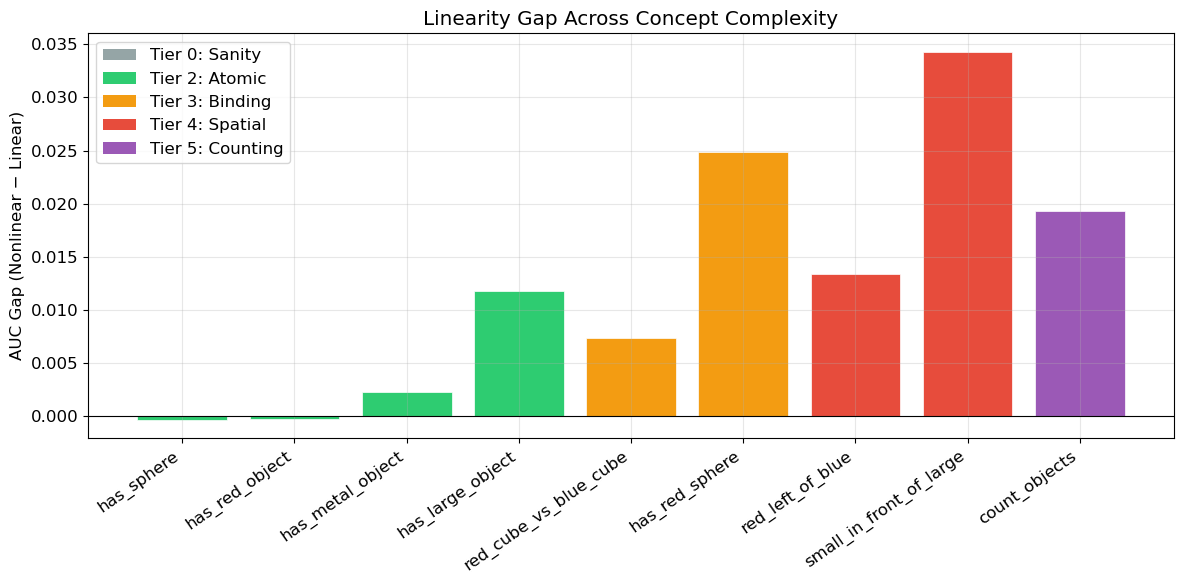

Saved clevr_probe_accuracies.png + .pdf


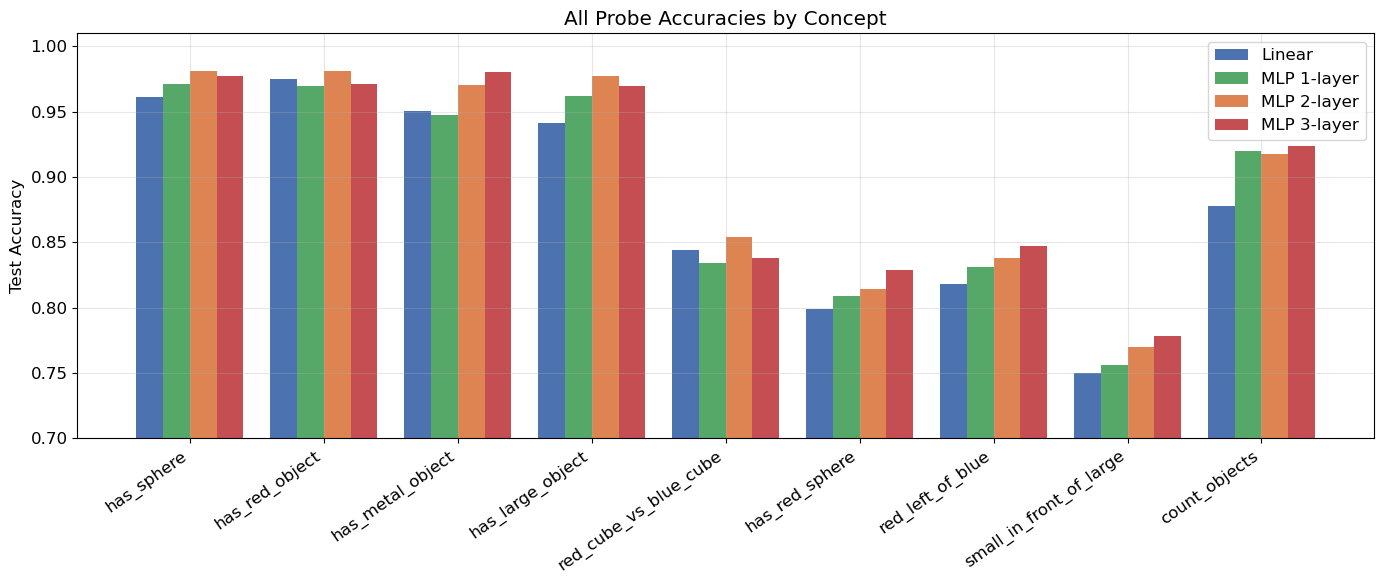

In [31]:
# Set style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})

# Prepare data sorted by tier
df_sorted = df[df['Tier'] > 0].sort_values(['Tier', 'AUC Gap'])


# Add tier brackets at top
tier_labels = {0: 'Sanity', 2: 'Atomic', 3: 'Binding', 4: 'Spatial', 5: 'Counting'}
tier_colors = {0: '#95a5a6', 2: '#2ecc71', 3: '#f39c12', 4: '#e74c3c', 5: '#9b59b6'}

# AUC Gap by concept

fig, ax = plt.subplots(figsize=(12, 6))

colors = [tier_colors[t] for t in df_sorted['Tier']]
bars = ax.bar(range(len(df_sorted)), df_sorted['AUC Gap'], color=colors, edgecolor='white', linewidth=0.5)

ax.set_ylabel('AUC Gap (Nonlinear − Linear)')
ax.set_title('Linearity Gap Across Concept Complexity')
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(df_sorted['Concept'], rotation=35, ha='right')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Legend for tiers
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=tier_colors[t], label=f'Tier {t}: {tier_labels[t]}')
                   for t in sorted(tier_colors.keys())]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
save_fig("clevr_lin_gap")
plt.show()

# Accuracy across all 4 probe types per concept
fig, ax = plt.subplots(figsize=(14, 6))

concepts = df_sorted['Concept'].values
x = np.arange(len(concepts))
width = 0.2

# Gather all probe accuracies
linear_accs = []
mlp1_accs = []
mlp2_accs = []
mlp3_accs = []

for concept in concepts:
    res = all_results[concept]
    linear_accs.append(res['linear_test_acc'])
    mlp1_accs.append(res['nonlinear_results']['mlp_1layer']['test_acc'])
    mlp2_accs.append(res['nonlinear_results']['mlp_2layer']['test_acc'])
    mlp3_accs.append(res['nonlinear_results']['mlp_3layer']['test_acc'])

ax.bar(x - 1.5*width, linear_accs, width, label='Linear', color='#4C72B0')
ax.bar(x - 0.5*width, mlp1_accs, width, label='MLP 1-layer', color='#55A868')
ax.bar(x + 0.5*width, mlp2_accs, width, label='MLP 2-layer', color='#DD8452')
ax.bar(x + 1.5*width, mlp3_accs, width, label='MLP 3-layer', color='#C44E52')

ax.set_ylabel('Test Accuracy')
ax.set_title('All Probe Accuracies by Concept')
ax.set_xticks(x)
ax.set_xticklabels(concepts, rotation=35, ha='right')
ax.legend()
ax.set_ylim(0.7, 1.01)

plt.tight_layout()
save_fig("clevr_probe_accuracies")
plt.show()

## ImageNet-Mini


In [13]:
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Write the access_token
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write('YOUR_NEW_TOKEN_HERE')
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

# Also set the env var so the kaggle CLI picks it up
os.environ['KAGGLE_API_TOKEN'] = 'TOKEN'

In [14]:
import sys
import shutil
import subprocess

IMAGENETMINI_KAGGLE_DATASET = "ifigotin/imagenetmini-1000"
COLAB_DATA_DIR = Path("/content/data")
LOCAL_DATA_DIR = Path("./data")
IMAGENET_MINI_ROOT_OVERRIDE = None  # Optional: set to a folder containing train/ and val/


def _run(cmd: list[str]) -> None:
    print("Running:", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)


def _in_colab() -> bool:
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


def _looks_like_imagenetmini_root(path: Path | None) -> bool:
    if path is None:
        return False
    return (
        (path / "train").is_dir()
        and (path / "val").is_dir()
        and any((path / "train").iterdir())
        and any((path / "val").iterdir())
    )


def find_imagenetmini_root(search_base: Path | None = None) -> Path | None:
    candidates: list[Path] = []

    if IMAGENET_MINI_ROOT_OVERRIDE:
        candidates.append(Path(IMAGENET_MINI_ROOT_OVERRIDE))

    candidates.extend([
        # Colab direct-download locations
        COLAB_DATA_DIR / "imagenet-mini",
        COLAB_DATA_DIR / "imagenetmini-1000" / "imagenet-mini",
        COLAB_DATA_DIR / "input" / "imagenetmini-1000" / "imagenet-mini",

        # Kaggle notebook mounted locations
        Path("/kaggle/input/imagenetmini-1000/imagenet-mini"),
        Path("/kaggle/input/imagenet-mini/imagenet-mini"),

        # Local fallback locations
        LOCAL_DATA_DIR / "imagenet-mini",
        Path("./imagenet-mini"),
    ])

    if search_base is not None and search_base.exists():
        candidates.extend([p for p in search_base.rglob("imagenet-mini") if p.is_dir()])

    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        if candidate in seen:
            continue
        seen.add(candidate)
        if _looks_like_imagenetmini_root(candidate):
            return candidate.resolve()

    return None


def install_kaggle_cli() -> None:
    try:
        import kaggle  # type: ignore  # noqa: F401
        return
    except Exception:
        pass

    _run([sys.executable, "-m", "pip", "install", "-q", "kaggle"])

# Override the credential check to skip the upload prompt
def ensure_kaggle_credentials():
    print("Using KAGGLE_API_TOKEN from environment.")
    return

# Overwrite the original function
globals()['ensure_kaggle_credentials'] = ensure_kaggle_credentials

# def ensure_kaggle_credentials() -> None:
#     """
#     Makes ~/.kaggle/kaggle.json available for the Kaggle CLI.

#     Priority:
#     1. Existing ~/.kaggle/kaggle.json
#     2. KAGGLE_USERNAME and KAGGLE_KEY environment variables
#     3. /content/kaggle.json if you manually uploaded it in Colab's file pane
#     4. Colab upload prompt
#     """
#     kaggle_dir = Path.home() / ".kaggle"
#     kaggle_json = kaggle_dir / "kaggle.json"

#     if kaggle_json.exists():
#         os.chmod(kaggle_json, 0o600)
#         print(f"Using Kaggle credentials at {kaggle_json}")
#         return

#     if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
#         print("Using Kaggle credentials from KAGGLE_USERNAME and KAGGLE_KEY environment variables.")
#         return

#     colab_uploaded_json = Path("/content/kaggle.json")
#     if colab_uploaded_json.exists():
#         kaggle_dir.mkdir(parents=True, exist_ok=True)
#         shutil.copy2(colab_uploaded_json, kaggle_json)
#         os.chmod(kaggle_json, 0o600)
#         print(f"Copied /content/kaggle.json to {kaggle_json}")
#         return

#     if _in_colab():
#         from google.colab import files  # type: ignore

#         print("Upload kaggle.json now.")
#         uploaded = files.upload()
#         if "kaggle.json" not in uploaded:
#             raise FileNotFoundError(
#                 "No kaggle.json was uploaded. Download it from Kaggle Account -> Settings -> API."
#             )

#         kaggle_dir.mkdir(parents=True, exist_ok=True)
#         with open(kaggle_json, "wb") as f:
#             f.write(uploaded["kaggle.json"])
#         os.chmod(kaggle_json, 0o600)
#         print(f"Saved Kaggle credentials to {kaggle_json}")
#         return

#     raise RuntimeError(
#         "Kaggle credentials not found. Put kaggle.json at ~/.kaggle/kaggle.json, "
#         "set KAGGLE_USERNAME/KAGGLE_KEY, or run this cell in Colab and upload kaggle.json."
#     )


def download_imagenetmini_to_colab(force: bool = False) -> Path:
    """
    Downloads ImageNet-Mini into /content/data on Colab.

    Set force=True to redownload even if an existing imagenet-mini folder is found.
    """
    data_dir = COLAB_DATA_DIR if _in_colab() else LOCAL_DATA_DIR
    data_dir.mkdir(parents=True, exist_ok=True)

    if not force:
        existing = find_imagenetmini_root(data_dir)
        if existing is not None:
            print(f"ImageNet-Mini already exists at: {existing}")
            return existing

    install_kaggle_cli()
    ensure_kaggle_credentials()

    print(f"Downloading Kaggle dataset {IMAGENETMINI_KAGGLE_DATASET} to {data_dir} ...")
    _run([
        "/home/ayela/.local/bin/kaggle", "datasets", "download",
        "-d", IMAGENETMINI_KAGGLE_DATASET,
        "-p", str(data_dir),
        "--unzip",
    ])

    root = find_imagenetmini_root(data_dir)
    if root is None:
        raise FileNotFoundError(
            f"Download finished, but no imagenet-mini folder with train/ and val/ was found under {data_dir}."
        )

    print(f"ImageNet-Mini ready at: {root}")
    return root


IMAGENET_MINI_ROOT = download_imagenetmini_to_colab(force=False)
print("IMAGENET_MINI_ROOT =", IMAGENET_MINI_ROOT)


ImageNet-Mini already exists at: /home/ayela/CV/data/imagenet-mini
IMAGENET_MINI_ROOT = /home/ayela/CV/data/imagenet-mini


In [15]:
from torchvision.datasets import ImageFolder


def load_imagenet_class_names(class_to_idx: dict[str, int]) -> dict[str, str]:
    """
    Returns a synset/folder-name -> human-readable ImageNet class name mapping.

    The Kaggle ImageNet-Mini folders are WordNet synsets such as n02085620.
    We try the canonical class-index json first, then fall back to torchvision
    categories. If neither is available, we use the synset ids directly.
    """
    try:
        url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
        class_index = requests.get(url, timeout=10).json()
        synset_to_name = {
            value[0]: value[1].replace("_", " ")
            for value in class_index.values()
        }
        if all(synset in synset_to_name for synset in class_to_idx):
            return {synset: synset_to_name[synset] for synset in class_to_idx}
    except Exception as exc:
        print(f"Could not fetch canonical ImageNet class names: {exc}")

    # Fallback: torchvision's 1K class names. This assumes ImageFolder's sorted
    # synset order matches the standard ImageNet-1K order, which is true for the
    # common imagenet-mini Kaggle layout.
    try:
        from torchvision.models import ResNet50_Weights
        categories = ResNet50_Weights.IMAGENET1K_V2.meta["categories"]
        return {
            synset: categories[idx].replace("_", " ")
            for synset, idx in class_to_idx.items()
            if idx < len(categories)
        }
    except Exception as exc:
        print(f"Could not load torchvision ImageNet categories: {exc}")

    print("Falling back to synset ids as class names; text-based concept labelers may be less useful.")
    return {synset: synset for synset in class_to_idx}


def make_imagenetmini_rows(root: str | Path = IMAGENET_MINI_ROOT, split: str = "val"):
    """
    Build metadata rows from ImageNet-Mini without applying transforms.
    Each row has path, ImageFolder class_idx, synset/folder, and readable name.
    """
    split_dir = Path(root) / split
    ds = ImageFolder(str(split_dir))
    class_names = load_imagenet_class_names(ds.class_to_idx)

    rows = []
    for path, class_idx in ds.samples:
        synset = ds.classes[class_idx]
        rows.append({
            "path": path,
            "class_idx": int(class_idx),
            "synset": synset,
            "name": class_names.get(synset, synset),
        })

    print(f"{split}: {len(rows)} images, {len(ds.classes)} classes")
    preview = rows[:5]
    print("Preview:", [(r["synset"], r["class_idx"], r["name"]) for r in preview])
    return rows, ds.class_to_idx


def load_imagenetmini_concept(
    labeler_fn,
    root: str | Path = IMAGENET_MINI_ROOT,
    split: str = "val",
    max_per_class: int = 500,
    seed: int = 42,
):
    """

    labeler_fn(row) returns:
      - 0/1 for binary concepts,
      - 0..K-1 for multiclass concepts,
      - None to skip examples outside the controlled comparison.

    Returns balanced (images, labels), ready for test_concept(...).
    """
    rows, _ = make_imagenetmini_rows(root=root, split=split)

    class_rows = {}
    for row in rows:
        label = labeler_fn(row)
        if label is None:
            continue
        class_rows.setdefault(label, []).append(row)

    if len(class_rows) < 2:
        raise ValueError(f"Need at least 2 labels, got {list(class_rows.keys())}")

    min_count = min(len(v) for v in class_rows.values())
    n_per_class = min(min_count, max_per_class)
    if n_per_class < 2:
        raise ValueError(f"Not enough examples per class after filtering: { {k: len(v) for k, v in class_rows.items()} }")

    print(f"  Labels found: {sorted(class_rows.keys())}")
    print(f"  Raw counts: { {k: len(v) for k, v in sorted(class_rows.items(), key=lambda kv: str(kv[0]))} }")
    print(f"  Using {n_per_class} per label from split='{split}'")

    # Remap any non-integer labels to contiguous ints.
    label_values = sorted(class_rows.keys(), key=lambda x: str(x))
    label_to_int = {label: i for i, label in enumerate(label_values)}
    print(f"  Label mapping: {label_to_int}")

    rng = np.random.default_rng(seed)
    images, labels = [], []
    for label in label_values:
        rows_for_label = class_rows[label]
        selected_positions = rng.choice(len(rows_for_label), size=n_per_class, replace=False)
        for pos in selected_positions:
            row = rows_for_label[int(pos)]
            img = Image.open(row["path"]).convert("RGB")
            images.append(img)
            labels.append(label_to_int[label])

    return images, np.array(labels, dtype=np.int64)


In [16]:
# ImageNet-Mini concept labelers
#
# These use ImageNet class names/synset order to create controlled superclass
# concepts. ImageNet-Mini does not include explicit attribute annotations, so
# these are semantic object-category tests rather than color/texture attributes.

def _text(row):
    return row["name"].replace("_", " ").lower()


def _has_any_term(row, terms):
    name = f" {_text(row)} "
    return any(f" {term} " in name or term in name for term in terms)


DOG_TERMS = [
    "dog", "hound", "terrier", "retriever", "spaniel", "shepherd", "setter",
    "poodle", "corgi", "collie", "schnauzer", "mastiff", "husky", "malamute",
    "beagle", "boxer", "chihuahua", "rottweiler", "pinscher", "dachshund",
    "basenji", "pug", "keeshond", "samoyed", "dalmatian", "great dane",
]

CAT_TERMS = ["cat", "tabby", "tiger cat", "persian", "siamese", "egyptian cat"]

BIRD_TERMS = [
    "bird", "cock", "hen", "ostrich", "brambling", "goldfinch", "finch",
    "junco", "indigo bunting", "robin", "bulbul", "jay", "magpie", "chickadee",
    "water ouzel", "kite", "eagle", "vulture", "owl", "goose", "duck",
]

INSECT_TERMS = [
    "bee", "ant", "grasshopper", "cricket", "mantis", "cicada", "leafhopper",
    "dragonfly", "damselfly", "admiral", "ringlet", "monarch", "cabbage butterfly",
    "sulphur butterfly", "lycaenid", "beetle", "fly", "weevil",
]

VEHICLE_TERMS = [
    "car", "truck", "bus", "minibus", "limousine", "jeep", "taxi", "cab",
    "motor scooter", "bicycle", "mountain bike", "moped", "trailer", "wagon",
    "locomotive", "train", "airliner", "airship", "aircraft", "plane", "boat",
    "ship", "vessel", "canoe", "yawl", "catamaran", "trimaran", "fire engine",
    "ambulance", "snowmobile", "go-kart", "tank",
]

FOOD_TERMS = [
    "pizza", "cheeseburger", "hotdog", "burrito", "bagel", "pretzel", "ice cream",
    "ice lolly", "banana", "orange", "lemon", "fig", "pineapple", "pomegranate",
    "carbonara", "guacamole", "consomme", "trifle", "meat loaf", "plate",
]

INSTRUMENT_TERMS = [
    "guitar", "banjo", "cello", "violin", "harp", "piano", "drum", "flute",
    "sax", "cornet", "organ", "accordion", "maraca",
]


def imagenet_is_dog(row):
    # Standard ImageNet-1K dog breeds are class indices 151..268 in the usual ordering.
    return 1 if (151 <= row["class_idx"] <= 268 or _has_any_term(row, DOG_TERMS)) else 0


def imagenet_is_bird(row):
    # Common ImageNet-1K birds are near the start of the class index order.
    return 1 if (7 <= row["class_idx"] <= 24 or _has_any_term(row, BIRD_TERMS)) else 0


def imagenet_is_vehicle(row):
    return 1 if _has_any_term(row, VEHICLE_TERMS) else 0


def imagenet_dog_vs_cat(row):
    if imagenet_is_dog(row):
        return "dog"
    if _has_any_term(row, CAT_TERMS) or (281 <= row["class_idx"] <= 285):
        return "cat"
    return None


def imagenet_bird_vs_insect(row):
    if imagenet_is_bird(row):
        return "bird"
    if _has_any_term(row, INSECT_TERMS) or (300 <= row["class_idx"] <= 319):
        return "insect"
    return None


def imagenet_animal_vs_vehicle(row):
    is_animal = (
        imagenet_is_dog(row)
        or imagenet_is_bird(row)
        or _has_any_term(row, CAT_TERMS)
        or _has_any_term(row, INSECT_TERMS)
        or (281 <= row["class_idx"] <= 319)
    )
    is_vehicle = imagenet_is_vehicle(row)
    if is_animal and not is_vehicle:
        return "animal"
    if is_vehicle and not is_animal:
        return "vehicle"
    return None


def imagenet_supercategory_4way(row):
    # Return None when labels overlap or none match; this keeps the task controlled.
    matches = []
    if imagenet_is_dog(row):
        matches.append("dog")
    if imagenet_is_bird(row):
        matches.append("bird")
    if imagenet_is_vehicle(row):
        matches.append("vehicle")
    if _has_any_term(row, FOOD_TERMS):
        matches.append("food")
    if len(matches) == 1:
        return matches[0]
    return None


imagenetmini_concept_battery = {
    # Binary superclass concepts: concept present vs absent.
    "imagenetmini_has_dog": imagenet_is_dog,
    "imagenetmini_has_bird": imagenet_is_bird,
    "imagenetmini_has_vehicle": imagenet_is_vehicle,

    # Controlled binary comparisons.
    "imagenetmini_dog_vs_cat": imagenet_dog_vs_cat,
    "imagenetmini_bird_vs_insect": imagenet_bird_vs_insect,
    "imagenetmini_animal_vs_vehicle": imagenet_animal_vs_vehicle,

    # Small multiclass probe.
    "imagenetmini_supercategory_4way": imagenet_supercategory_4way,
}


In [17]:
# Run ImageNet-Mini concepts through the same CLIP linear-vs-nonlinear

IMAGENETMINI_SPLIT = "val"       # "val" is quick; use "train" for more examples
IMAGENETMINI_MAX_PER_CLASS = 500 # reduce to 100 or 200 for faster debugging

imagenetmini_result_names = []

for concept_name, labeler in imagenetmini_concept_battery.items():
    if concept_name in all_results:
        print(f"Skipping {concept_name} (already done)\n")
        imagenetmini_result_names.append(concept_name)
        continue

    print(f"\nLoading ImageNet-Mini concept: {concept_name}")
    images, labels = load_imagenetmini_concept(
        labeler,
        root=IMAGENET_MINI_ROOT,
        split=IMAGENETMINI_SPLIT,
        max_per_class=IMAGENETMINI_MAX_PER_CLASS,
        seed=42,
    )
    test_concept(concept_name, images, labels, cache_dir="imagenetmini_feature_cache")
    imagenetmini_result_names.append(concept_name)



Loading ImageNet-Mini concept: imagenetmini_has_dog
val: 3923 images, 1000 classes
Preview: [('n01440764', 0, 'tench'), ('n01440764', 0, 'tench'), ('n01440764', 0, 'tench'), ('n01443537', 1, 'goldfish'), ('n01443537', 1, 'goldfish')]
  Labels found: [0, 1]
  Raw counts: {0: 3481, 1: 442}
  Using 442 per label from split='val'
  Label mapping: {0: 0, 1: 1}
Loading cached features for 'imagenetmini_has_dog'...
Concept: imagenetmini_has_dog
Dataset: 884 images, 2 classes
Class balance: {np.int64(0): np.int64(442), np.int64(1): np.int64(442)}

Linear probe (5-fold CV):
  acc: 0.983 ± 0.006  auc: 0.999 ± 0.001

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.971 ± 0.010  auc: 0.998 ± 0.001
  mlp_2layer       (128, 64)  |  acc: 0.981 ± 0.004  auc: 0.998 ± 0.002
  mlp_3layer   (128, 64, 32)  |  acc: 0.984 ± 0.006  auc: 0.998 ± 0.003

────────────────────────────────────────────────────────────
Summary for: imagenetmini_has_dog
  Probe                   Acc    AUC  Acc g

In [18]:
imagenet_tier_map = {
    "imagenetmini_has_dog": 1,
    "imagenetmini_has_bird": 1,
    "imagenetmini_has_vehicle": 1,
    "imagenetmini_dog_vs_cat": 1,
    "imagenetmini_bird_vs_insect": 1,
    "imagenetmini_animal_vs_vehicle": 1,
    "imagenetmini_supercategory_4way": 1,
}

summary_rows = []
for name in imagenetmini_result_names:
    res = all_results[name]
    best_nl_auc = max(r["test_auc"] for r in res["nonlinear_results"].values())
    best_nl_acc = max(r["test_acc"] for r in res["nonlinear_results"].values())

    summary_rows.append({
        "Concept": name,
        "Tier": imagenet_tier_map.get(name, 1),
        "Linear Acc": res["linear_test_acc"],
        "Linear AUC": res["linear_test_auc"],
        "Best NL Acc": best_nl_acc,
        "Best NL AUC": best_nl_auc,
        "Acc Gap": best_nl_acc - res["linear_test_acc"],
        "AUC Gap": best_nl_auc - res["linear_test_auc"],
    })

imagenet_df = pd.DataFrame(summary_rows).sort_values(["Tier", "AUC Gap"])
print(imagenet_df.to_string(index=False, float_format="%.3f"))

                        Concept  Tier  Linear Acc  Linear AUC  Best NL Acc  Best NL AUC  Acc Gap  AUC Gap
    imagenetmini_bird_vs_insect     1       0.920       0.967        0.873        0.946   -0.047   -0.021
          imagenetmini_has_bird     1       0.802       0.899        0.782        0.892   -0.019   -0.007
       imagenetmini_has_vehicle     1       0.796       0.864        0.796        0.859    0.000   -0.004
 imagenetmini_animal_vs_vehicle     1       0.949       0.985        0.940        0.983   -0.009   -0.001
           imagenetmini_has_dog     1       0.983       0.999        0.984        0.998    0.001   -0.001
        imagenetmini_dog_vs_cat     1       0.989       1.000        0.931        1.000   -0.058    0.000
imagenetmini_supercategory_4way     1       0.916       0.978        0.899        0.980   -0.017    0.002


Saved imagenet_lin_gap.png + .pdf


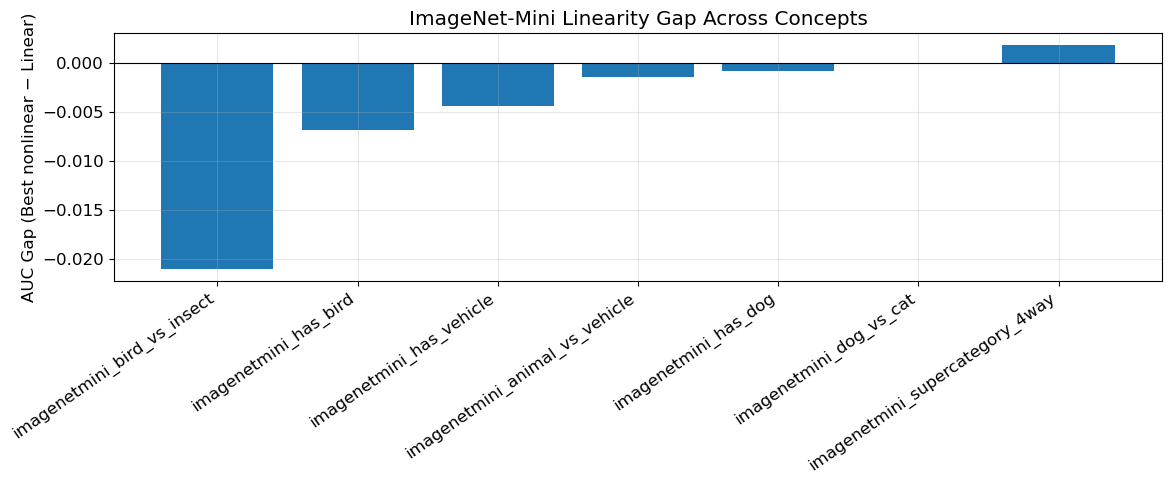

Saved imagenet_probe_acc.png + .pdf


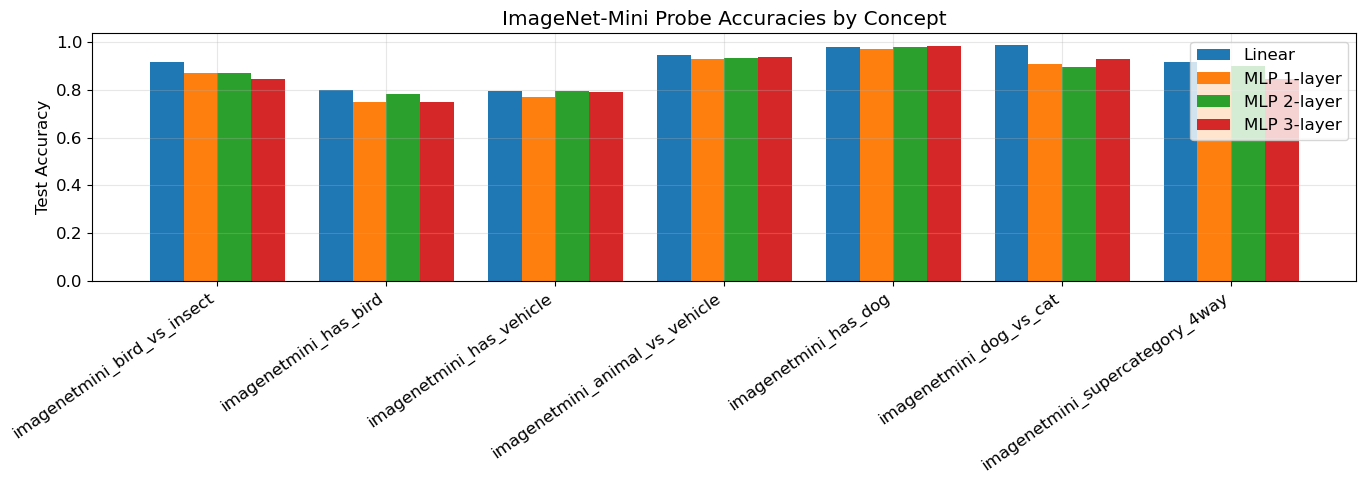

In [32]:
# Plot ImageNet-Mini linearity gaps and probe accuracies

if len(imagenet_df) > 0:
    df_sorted = imagenet_df.sort_values(["Tier", "AUC Gap"])
    concepts = df_sorted["Concept"].values

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(df_sorted)), df_sorted["AUC Gap"])
    ax.set_ylabel("AUC Gap (Best nonlinear − Linear)")
    ax.set_title("ImageNet-Mini Linearity Gap Across Concepts")
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(concepts, rotation=35, ha="right")
    ax.axhline(y=0, color="black", linewidth=0.8)
    plt.tight_layout()
    save_fig("imagenet_lin_gap")
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(concepts))
    width = 0.2

    linear_accs, mlp1_accs, mlp2_accs, mlp3_accs = [], [], [], []
    for concept in concepts:
        res = all_results[concept]
        linear_accs.append(res["linear_test_acc"])
        mlp1_accs.append(res["nonlinear_results"]["mlp_1layer"]["test_acc"])
        mlp2_accs.append(res["nonlinear_results"]["mlp_2layer"]["test_acc"])
        mlp3_accs.append(res["nonlinear_results"]["mlp_3layer"]["test_acc"])

    ax.bar(x - 1.5 * width, linear_accs, width, label="Linear")
    ax.bar(x - 0.5 * width, mlp1_accs, width, label="MLP 1-layer")
    ax.bar(x + 0.5 * width, mlp2_accs, width, label="MLP 2-layer")
    ax.bar(x + 1.5 * width, mlp3_accs, width, label="MLP 3-layer")

    ax.set_ylabel("Test Accuracy")
    ax.set_title("ImageNet-Mini Probe Accuracies by Concept")
    ax.set_xticks(x)
    ax.set_xticklabels(concepts, rotation=35, ha="right")
    ax.legend()
    plt.tight_layout()
    save_fig("imagenet_probe_acc")
    plt.show()


## ARO Benchmark


In [20]:
 # ============================================================
# ARO setup
# ============================================================

import os, sys, subprocess
from pathlib import Path

ARO_REPO = Path("/content/vision-language-models-are-bows")
ARO_DATA_ROOT = Path("/content/aro_datasets")
ARO_DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Clone ARO repo if needed
if not ARO_REPO.exists():
    subprocess.run([
        "git", "clone",
        "https://github.com/mertyg/vision-language-models-are-bows.git",
        str(ARO_REPO)
    ], check=True)

# Install small dependency used by ARO dataset code
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown", "easydict"], check=True)

# Add repo to path
sys.path.append(str(ARO_REPO))

# Import ARO datasets
from dataset_zoo import VG_Attribution, VG_Relation

print("ARO repo ready:", ARO_REPO)
print("ARO data root:", ARO_DATA_ROOT)

ARO repo ready: /content/vision-language-models-are-bows
ARO data root: /content/aro_datasets


In [21]:
def gdown_file(file_id, output_path):
    output_path = str(output_path)
    url = f"https://drive.google.com/uc?id={file_id}"
    subprocess.run(
        [sys.executable, "-m", "gdown", url, "-O", output_path],
        check=True
    )

files_to_download = {
    "visual_genome_attribution.json": "13tWvOrNOLHxl3Rm9cR3geAdHx2qR3-Tw",
    "visual_genome_relation.json": "1kX2iCHEv0CADL8dSO1nMdW-V0NqIAiP3",
    "vgr_vga_images.zip": "1qaPlrwhGNMrR3a11iopZUT_GPP_LrgP9",
}

for filename, file_id in files_to_download.items():
    out_path = ARO_DATA_ROOT / filename
    if not out_path.exists():
        print("Downloading", filename)
        gdown_file(file_id, out_path)
    else:
        print("Already exists:", filename)

Already exists: visual_genome_attribution.json
Already exists: visual_genome_relation.json
Already exists: vgr_vga_images.zip


In [22]:
import zipfile

zip_path = ARO_DATA_ROOT / "vgr_vga_images.zip"
images_dir = ARO_DATA_ROOT / "images"

if not images_dir.exists():
    print("Unzipping images...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(ARO_DATA_ROOT)
else:
    print("Images already unzipped.")

Images already unzipped.


In [23]:
# ============================================================
# ARO evaluation helpers
# ============================================================

def _tokenize_captions(captions):
    try:
        return open_clip.tokenize(captions, truncate=True)
    except TypeError:
        return open_clip.tokenize(captions)


@torch.no_grad()
def score_aro_items(dataset, indices, batch_size=64):
    """
    Returns CLIP similarity scores with shape [N, num_caption_options].
    For VG-A/VG-R, caption_options = [false_caption, true_caption].
    """
    model.eval()
    all_scores = []

    for start in tqdm(range(0, len(indices), batch_size), desc="Scoring ARO"):
        batch_indices = indices[start:start + batch_size]

        image_tensors = []
        caption_options = []

        for idx in batch_indices:
            item = dataset[int(idx)]

            image_options = item["image_options"]
            captions = list(item["caption_options"])

            image = image_options[0]

            # ARO may already apply preprocessing
            if not torch.is_tensor(image):
                image = preprocess(image)

            image_tensors.append(image)
            caption_options.append(captions)

        num_options = len(caption_options[0])

        image_batch = torch.stack(image_tensors).to(device)
        flat_captions = [caption for options in caption_options for caption in options]
        text_tokens = _tokenize_captions(flat_captions).to(device)

        image_features = model.encode_image(image_batch)
        text_features = model.encode_text(text_tokens)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        text_features = text_features.reshape(len(batch_indices), num_options, -1)

        scores = (image_features[:, None, :] * text_features).sum(dim=-1)
        all_scores.append(scores.cpu().numpy())

    return np.concatenate(all_scores, axis=0)


def evaluate_aro_dataset(dataset_name, dataset, max_examples=None, batch_size=64, seed=42, verbose=True):
    rng = np.random.default_rng(seed)

    n_total = len(dataset)
    n_eval = n_total if max_examples is None else min(n_total, max_examples)

    if n_eval == n_total:
        indices = np.arange(n_total)
    else:
        indices = rng.choice(n_total, size=n_eval, replace=False)

    # ARO VG caption_options = [false_caption, true_caption]
    correct_index = 1

    if verbose:
        print(f"\nEvaluating {dataset_name}: {n_eval}/{n_total} examples")

    scores = score_aro_items(dataset, indices, batch_size=batch_size)
    preds = scores.argmax(axis=1)
    correct = preds == correct_index

    result = {
        "Dataset": dataset_name,
        "N evaluated": int(n_eval),
        "N total": int(n_total),
        "Accuracy": float(correct.mean()),
    }

    raw_items = [dataset.dataset[int(i)] for i in indices]
    group_df = None

    if dataset_name == "VG_Attribution":
        rows = []

        # Each item has attributes like ["open", "crouched"]
        # We count the item under both attributes.
        all_attrs = sorted({
            attr
            for item in raw_items
            for attr in item["attributes"]
        })

        for attr in all_attrs:
            mask = np.array([
                attr in item["attributes"]
                for item in raw_items
            ])

            rows.append({
                "Group": attr,
                "Accuracy": float(correct[mask].mean()),
                "Count": int(mask.sum()),
            })

        group_df = pd.DataFrame(rows).sort_values(
            ["Accuracy", "Count"],
            ascending=[True, False],
        )

    elif dataset_name == "VG_Relation":
        relation_values = np.array([
            item["relation_name"]
            for item in raw_items
        ], dtype=object)

        rows = []

        for rel in sorted(set(relation_values), key=str):
            mask = relation_values == rel

            rows.append({
                "Group": rel,
                "Accuracy": float(correct[mask].mean()),
                "Count": int(mask.sum()),
            })

        group_df = pd.DataFrame(rows).sort_values(
            ["Accuracy", "Count"],
            ascending=[True, False],
        )

    if verbose:
        print(f"{dataset_name} accuracy: {correct.mean():.3f}")

    return result, group_df, scores, preds, correct, indices

In [24]:
# ============================================================
# Run ARO benchmark
# ============================================================

aro_vg_attr = VG_Attribution(
    image_preprocess=preprocess,
    download=False,
    root_dir=str(ARO_DATA_ROOT),
)

aro_vg_rel = VG_Relation(
    image_preprocess=preprocess,
    download=False,
    root_dir=str(ARO_DATA_ROOT),
)

aro_results = {}
aro_group_tables = {}

for name, ds in [
    ("VG_Attribution", aro_vg_attr),
    ("VG_Relation", aro_vg_rel),
]:
    result, group_df, scores, preds, correct, indices = evaluate_aro_dataset(
        name,
        ds,
        max_examples=None,
        batch_size=64,
        seed=42,
        verbose=False,      # add this if you update the function below
    )

    aro_results[name] = {
        "summary": result,
        "scores": scores,
        "preds": preds,
        "correct": correct,
        "indices": indices,
    }

    if group_df is not None:
        aro_group_tables[name] = group_df

aro_df = pd.DataFrame([v["summary"] for v in aro_results.values()])
aro_df

Scoring ARO: 100%|██████████| 375/375 [01:47<00:00,  3.49it/s]


,Dataset,N evaluated,N total,Accuracy
0,VG_Attribution,28748,28748,0.587589
1,VG_Relation,23937,23937,0.500731


Saved aro_lowest_acc_groups.png + .pdf


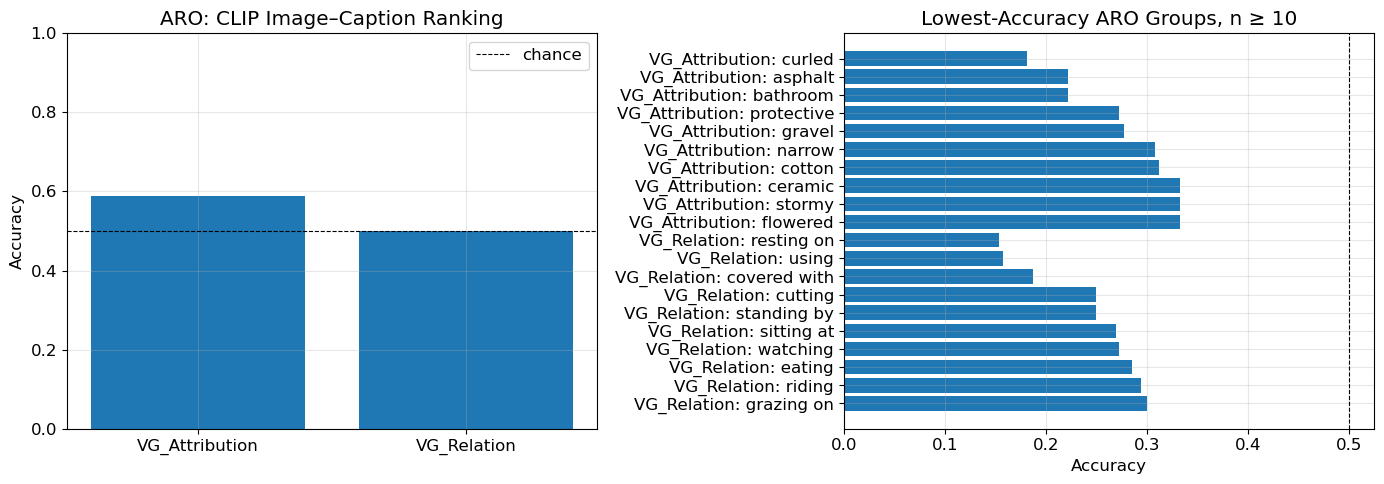

In [33]:
# ============================================================
# Plot ARO results
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall accuracy
ax = axes[0]
ax.bar(aro_df["Dataset"], aro_df["Accuracy"])
ax.axhline(y=0.5, color="black", linewidth=0.8, linestyle="--", label="chance")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("ARO: CLIP Image–Caption Ranking")
ax.legend()

# Bottom groups
ax2 = axes[1]

plot_rows = []

for name, group_df in aro_group_tables.items():
    bottom = group_df[group_df["Count"] >= 10].head(10).copy()
    bottom["Dataset"] = name
    plot_rows.append(bottom)

bottom_all = pd.concat(plot_rows, ignore_index=True)
bottom_all["Label"] = bottom_all["Dataset"] + ": " + bottom_all["Group"].astype(str)

ax2.barh(bottom_all["Label"], bottom_all["Accuracy"])
ax2.axvline(x=0.5, color="black", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Accuracy")
ax2.set_title("Lowest-Accuracy ARO Groups, n ≥ 10")
ax2.invert_yaxis()

plt.tight_layout()
save_fig("aro_lowest_acc_groups")
plt.show()

## DTD (Describable Textures Dataset)


In [26]:
# ============================================================
# DTD full probe pipeline
# ============================================================

!pip -q install torchvision
from torchvision.datasets import DTD


# ------------------------------------------------------------
# 1. DTD setup
# ------------------------------------------------------------

DTD_ROOT = Path("/content/dtd_data")
DTD_PARTITION = 1
DTD_SPLITS = ["train", "val", "test"]

print("Downloading/loading DTD...")

_dtd_train = DTD(
    root=str(DTD_ROOT),
    split="train",
    partition=DTD_PARTITION,
    download=True,
    transform=None,
)

dtd_splits = {
    split: DTD(
        root=str(DTD_ROOT),
        split=split,
        partition=DTD_PARTITION,
        download=False,
        transform=None,
    )
    for split in DTD_SPLITS
}

DTD_CLASSES = list(_dtd_train.classes)

print("DTD root:", DTD_ROOT)
print("Number of DTD classes:", len(DTD_CLASSES))
print(DTD_CLASSES)


# ------------------------------------------------------------
# 2. DTD balanced concept loader
# ------------------------------------------------------------

def load_dtd_concept(
    target_texture,
    splits=("train", "val", "test"),
    seed=42,
):
    """
    Positive class: target texture
    Negative class: balanced sample from all other textures
    """

    rng = random.Random(seed)
    target_texture = target_texture.lower().strip()

    if target_texture not in DTD_CLASSES:
        raise ValueError(
            f"Unknown DTD texture: {target_texture}\n"
            f"Available classes: {DTD_CLASSES}"
        )

    positives = []
    negatives = []

    for split in splits:
        ds = dtd_splits[split]

        for img, label_idx in ds:
            class_name = ds.classes[label_idx]

            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))

            img = img.convert("RGB")

            if class_name == target_texture:
                positives.append(img)
            else:
                negatives.append(img)

    rng.shuffle(positives)
    rng.shuffle(negatives)

    n = min(len(positives), len(negatives))

    positives = positives[:n]
    negatives = negatives[:n]

    images = positives + negatives
    labels = np.array([1] * len(positives) + [0] * len(negatives))

    idx = list(range(len(images)))
    rng.shuffle(idx)

    images = [images[i] for i in idx]
    labels = labels[idx]

    print(f"\nDTD concept: dtd_has_{target_texture}")
    print("  Positives:", len(positives))
    print("  Negatives:", len(negatives))
    print("  Total:", len(images))
    print("  Balance:", dict(Counter(labels)))

    return images, labels


# ------------------------------------------------------------
# 3. Run DTD concepts through the SAME pipeline as CLEVR/ImageNet
# ------------------------------------------------------------

DTD_TEXTURE_CONCEPTS = [
    "striped",
    "dotted",
    "chequered",
    "zigzagged",
    "woven",
    "knitted",
    "scaly",
    "cracked",
    "bumpy",
    "marbled",
    "porous",
    "wrinkled",
]

dtd_results = {}

for texture in DTD_TEXTURE_CONCEPTS:
    concept_name = f"dtd_has_{texture}"

    if concept_name in all_results:
        print(f"Skipping {concept_name} (already done)\n")
        dtd_results[concept_name] = all_results[concept_name]
        continue

    images, labels = load_dtd_concept(
        target_texture=texture,
        splits=("train", "val", "test"),
        seed=42,
    )

    # test_concept: extract features → 5-fold CV linear + MLP → store in all_results
    result = test_concept(concept_name, images, labels, cache_dir="dtd_feature_cache")
    dtd_results[concept_name] = result

Downloading/loading DTD...
DTD root: /content/dtd_data
Number of DTD classes: 47
['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline', 'dotted', 'fibrous', 'flecked', 'freckled', 'frilly', 'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced', 'knitted', 'lacelike', 'lined', 'marbled', 'matted', 'meshed', 'paisley', 'perforated', 'pitted', 'pleated', 'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared', 'spiralled', 'sprinkled', 'stained', 'stratified', 'striped', 'studded', 'swirly', 'veined', 'waffled', 'woven', 'wrinkled', 'zigzagged']

DTD concept: dtd_has_striped
  Positives: 120
  Negatives: 120
  Total: 240
  Balance: {np.int64(1): 120, np.int64(0): 120}
Loading cached features for 'dtd_has_striped'...
Concept: dtd_has_striped
Dataset: 240 images, 2 classes
Class balance: {np.int64(0): np.int64(120), np.int64(1): np.int64(120)}

Linear probe (5-fold CV):
  acc: 0.950 ± 0.010  auc: 0.990 ± 0.010

Nonlinear pr

In [27]:
# ============================================================
# DTD summary table
# ============================================================

rows = []

for concept_name, res in dtd_results.items():
    lin_acc = res["linear_test_acc"]
    lin_auc = res["linear_test_auc"]

    rows.append({
        "Concept": concept_name,
        "Probe": "linear",
        "Accuracy": lin_acc,
        "AUC": lin_auc,
        "Acc gap vs linear": 0.0,
        "AUC gap vs linear": 0.0,
    })

    for mlp_name, mlp_res in res["nonlinear_results"].items():
        rows.append({
            "Concept": concept_name,
            "Probe": mlp_name,
            "Accuracy": mlp_res["test_acc"],
            "AUC": mlp_res["test_auc"],
            "Acc gap vs linear": mlp_res["test_acc"] - lin_acc,
            "AUC gap vs linear": mlp_res["test_auc"] - lin_auc,
        })

dtd_summary = pd.DataFrame(rows)

display(dtd_summary)

linear_dtd_summary = (
    dtd_summary[dtd_summary["Probe"] == "linear"]
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(linear_dtd_summary)

,Concept,Probe,Accuracy,AUC,Acc gap vs linear,AUC gap vs linear
0,dtd_has_striped,linear,0.950000,0.989931,0.000000,0.000000e+00
1,dtd_has_striped,mlp_1layer,0.933333,0.976389,-0.016667,-1.354167e-02
2,dtd_has_striped,mlp_2layer,0.908333,0.976389,-0.041667,-1.354167e-02
3,dtd_has_striped,mlp_3layer,0.933333,0.980556,-0.016667,-9.375000e-03
4,dtd_has_dotted,linear,0.950000,0.985417,0.000000,0.000000e+00
5,dtd_has_dotted,mlp_1layer,0.900000,0.982986,-0.050000,-2.430556e-03
6,dtd_has_dotted,mlp_2layer,0.937500,0.981944,-0.012500,-3.472222e-03
7,dtd_has_dotted,mlp_3layer,0.895833,0.982292,-0.054167,-3.125000e-03
8,dtd_has_chequered,linear,0.970833,0.998611,0.000000,0.000000e+00
9,dtd_has_chequered,mlp_1layer,0.950000,0.998611,-0.020833,0.000000e+00


,Concept,Probe,Accuracy,AUC,Acc gap vs linear,AUC gap vs linear
0,dtd_has_marbled,linear,0.975000,0.998264,0.0,0.0
1,dtd_has_chequered,linear,0.970833,0.998611,0.0,0.0
2,dtd_has_knitted,linear,0.970833,0.999306,0.0,0.0
3,dtd_has_scaly,linear,0.962500,0.996528,0.0,0.0
4,dtd_has_cracked,linear,0.954167,0.986458,0.0,0.0
5,dtd_has_zigzagged,linear,0.954167,0.991667,0.0,0.0
6,dtd_has_striped,linear,0.950000,0.989931,0.0,0.0
7,dtd_has_dotted,linear,0.950000,0.985417,0.0,0.0
8,dtd_has_woven,linear,0.933333,0.988542,0.0,0.0
9,dtd_has_porous,linear,0.929167,0.978472,0.0,0.0


Saved dtd_probe_acc.png + .pdf


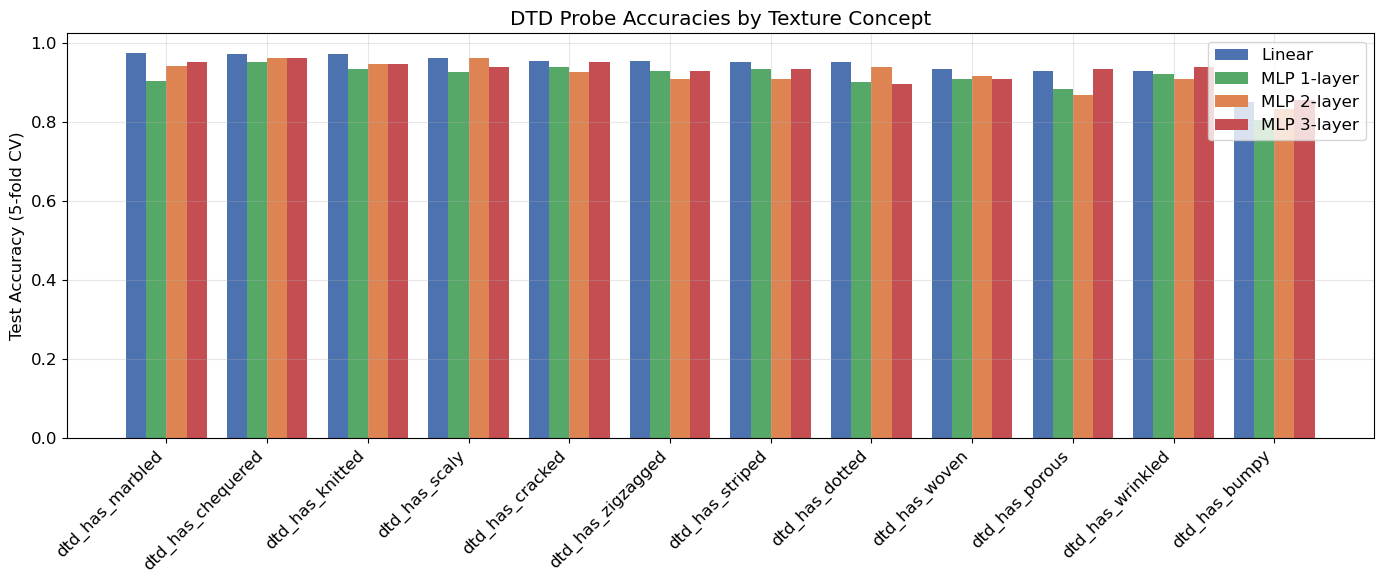

In [35]:
# All probe accuracies by DTD concept
fig, ax = plt.subplots(figsize=(14, 6))

concepts = plot_df["Concept"].values
x = np.arange(len(concepts))
width = 0.2

linear_accs, mlp1_accs, mlp2_accs, mlp3_accs = [], [], [], []
for concept in concepts:
    res = all_results[concept]
    linear_accs.append(res["linear_test_acc"])
    mlp1_accs.append(res["nonlinear_results"]["mlp_1layer"]["test_acc"])
    mlp2_accs.append(res["nonlinear_results"]["mlp_2layer"]["test_acc"])
    mlp3_accs.append(res["nonlinear_results"]["mlp_3layer"]["test_acc"])

ax.bar(x - 1.5 * width, linear_accs, width, label="Linear", color="#4C72B0")
ax.bar(x - 0.5 * width, mlp1_accs, width, label="MLP 1-layer", color="#55A868")
ax.bar(x + 0.5 * width, mlp2_accs, width, label="MLP 2-layer", color="#DD8452")
ax.bar(x + 1.5 * width, mlp3_accs, width, label="MLP 3-layer", color="#C44E52")

ax.set_ylabel("Test Accuracy (5-fold CV)")
ax.set_title("DTD Probe Accuracies by Texture Concept")
ax.set_xticks(x)
ax.set_xticklabels(concepts, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
save_fig("dtd_probe_acc")
plt.show()

# Additivity Test (Object–Attribute Binding)

The proposal defines linear recoverability for binding as:

$z(\text{red cube}) \approx z(\text{cube}) + v_{\text{red}}$

We test this by computing *concept vectors* for individual attributes,then measuring whether adding the concept vector to a base object embedding predicts the bound-object embedding. Following Korchinski et al. (2025), linearity of attribute composition implies additive shifts in embedding space.


In [36]:
# ============================================================
# Additivity test for object–attribute binding in CLEVR
# ============================================================


def collect_clevr_by_properties(clevr_scenes, img_dir='clevr_val_images', max_per_group=200):
    """
    Collect CLEVR images grouped by (color, shape) pairs.
    Returns dict: (color, shape) -> list of PIL images
    """
    groups = {}
    for scene in clevr_scenes:
        for obj in scene['objects']:
            key = (obj['color'], obj['shape'])
            if key not in groups:
                groups[key] = []
            # Only use scenes with a single object of this type for clean signal
            count = sum(1 for o in scene['objects']
                        if o['color'] == obj['color'] and o['shape'] == obj['shape'])
            if count == 1 and len(groups[key]) < max_per_group:
                groups[key].append(scene['image_filename'])
    return groups


def compute_mean_embedding(filenames, img_dir='clevr_val_images'):
    """Compute mean CLIP embedding for a set of images."""
    images = [Image.open(os.path.join(img_dir, f)).convert('RGB') for f in filenames]
    features = extract_features(images)
    return features.mean(axis=0)


def run_additivity_test(clevr_scenes, img_dir='clevr_val_images'):
    """
    Test: z(color, shape) ≈ z(*, shape) + v_color
    where v_color = z(color, *) - z(*, *)

    Reports cosine similarity between predicted and actual embeddings.
    """
    groups = collect_clevr_by_properties(clevr_scenes, img_dir)

    # Filter to groups with enough examples
    min_examples = 30
    valid_groups = {k: v for k, v in groups.items() if len(v) >= min_examples}
    print(f"Groups with >= {min_examples} examples: {len(valid_groups)}")
    for k, v in sorted(valid_groups.items()):
        print(f"  {k}: {len(v)} images")

    # Compute mean embeddings per group
    embeddings = {}
    for key, filenames in valid_groups.items():
        embeddings[key] = compute_mean_embedding(filenames[:min_examples], img_dir)

    # Get all colors and shapes present
    colors = sorted(set(k[0] for k in valid_groups))
    shapes = sorted(set(k[1] for k in valid_groups))
    print(f"\nColors: {colors}")
    print(f"Shapes: {shapes}")

    # Compute shape-marginal embeddings: z(*, shape) = mean over colors of z(c, shape)
    shape_embeddings = {}
    for shape in shapes:
        vecs = [embeddings[(c, shape)] for c in colors if (c, shape) in embeddings]
        if len(vecs) >= 2:
            shape_embeddings[shape] = np.mean(vecs, axis=0)

    # Compute color-marginal embeddings: z(color, *) = mean over shapes of z(color, s)
    color_embeddings = {}
    for color in colors:
        vecs = [embeddings[(color, s)] for s in shapes if (color, s) in embeddings]
        if len(vecs) >= 2:
            color_embeddings[color] = np.mean(vecs, axis=0)

    # Grand mean: z(*, *)
    all_vecs = list(embeddings.values())
    grand_mean = np.mean(all_vecs, axis=0)

    # Concept vectors: v_color = z(color, *) - z(*, *)
    concept_vectors = {c: color_embeddings[c] - grand_mean for c in color_embeddings}

    # Test additivity: z_pred(color, shape) = z(*, shape) + v_color
    # Compare to z_actual(color, shape)
    results = []
    for color in colors:
        if color not in concept_vectors:
            continue
        for shape in shapes:
            if (color, shape) not in embeddings or shape not in shape_embeddings:
                continue
            z_actual = embeddings[(color, shape)]
            z_pred = shape_embeddings[shape] + concept_vectors[color]
            # Normalise for cosine sim
            z_pred_norm = z_pred / np.linalg.norm(z_pred)
            z_actual_norm = z_actual / np.linalg.norm(z_actual)
            cos_sim = float(z_pred_norm @ z_actual_norm)
            results.append({
                'color': color,
                'shape': shape,
                'cosine_sim': cos_sim,
            })

    return results, concept_vectors, embeddings


# Run it
additivity_results, concept_vectors, group_embeddings = run_additivity_test(clevr_scenes)

Groups with >= 30 examples: 24
  ('blue', 'cube'): 200 images
  ('blue', 'cylinder'): 200 images
  ('blue', 'sphere'): 200 images
  ('brown', 'cube'): 200 images
  ('brown', 'cylinder'): 200 images
  ('brown', 'sphere'): 200 images
  ('cyan', 'cube'): 200 images
  ('cyan', 'cylinder'): 200 images
  ('cyan', 'sphere'): 200 images
  ('gray', 'cube'): 200 images
  ('gray', 'cylinder'): 200 images
  ('gray', 'sphere'): 200 images
  ('green', 'cube'): 200 images
  ('green', 'cylinder'): 200 images
  ('green', 'sphere'): 200 images
  ('purple', 'cube'): 200 images
  ('purple', 'cylinder'): 200 images
  ('purple', 'sphere'): 200 images
  ('red', 'cube'): 200 images
  ('red', 'cylinder'): 200 images
  ('red', 'sphere'): 200 images
  ('yellow', 'cube'): 200 images
  ('yellow', 'cylinder'): 200 images
  ('yellow', 'sphere'): 200 images

Colors: ['blue', 'brown', 'cyan', 'gray', 'green', 'purple', 'red', 'yellow']
Shapes: ['cube', 'cylinder', 'sphere']


In [37]:
SAVE_DIR = os.path.join(os.getcwd(), "results_cache")
for name in ["additivity_results", "concept_vectors", "group_embeddings"]:
    obj = globals().get(name)
    if obj is not None:
        with open(os.path.join(SAVE_DIR, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
        print(f"Saved {name}")

Saved additivity_results
Saved concept_vectors
Saved group_embeddings



Additivity test: 24 (color, shape) pairs
Mean cosine similarity: 0.9990
Std:  0.0002
Min:  0.9985
Max:  0.9994
Saved additivity_tests.png + .pdf


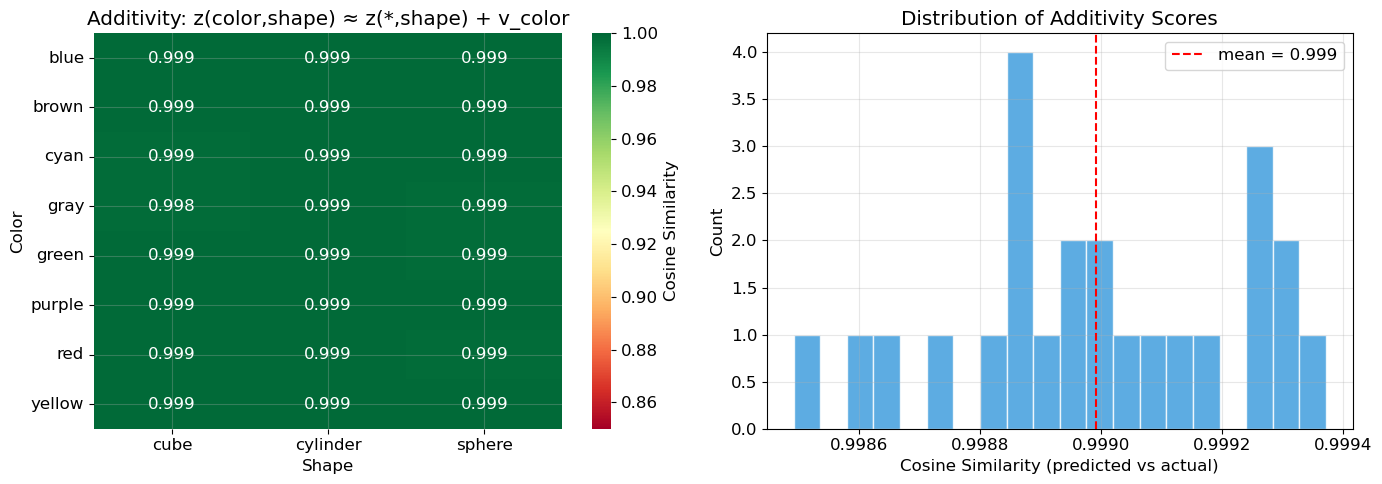

In [39]:
# Visualise additivity results


add_df = pd.DataFrame(additivity_results)
print(f"\nAdditivity test: {len(add_df)} (color, shape) pairs")
print(f"Mean cosine similarity: {add_df['cosine_sim'].mean():.4f}")
print(f"Std:  {add_df['cosine_sim'].std():.4f}")
print(f"Min:  {add_df['cosine_sim'].min():.4f}")
print(f"Max:  {add_df['cosine_sim'].max():.4f}")

# Heatmap: cosine sim by (color, shape)
pivot = add_df.pivot(index='color', columns='shape', values='cosine_sim')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.85, vmax=1.0,
            ax=axes[0], cbar_kws={'label': 'Cosine Similarity'})
axes[0].set_title('Additivity: z(color,shape) ≈ z(*,shape) + v_color')
axes[0].set_ylabel('Color')
axes[0].set_xlabel('Shape')

# Distribution
axes[1].hist(add_df['cosine_sim'], bins=20, edgecolor='white', color='#3498db', alpha=0.8)
axes[1].axvline(add_df['cosine_sim'].mean(), color='red', linestyle='--',
                label=f"mean = {add_df['cosine_sim'].mean():.3f}")
axes[1].set_xlabel('Cosine Similarity (predicted vs actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Additivity Scores')
axes[1].legend()

plt.tight_layout()
save_fig("additivity_tests")
plt.show()

In [40]:
# Concept vector consistency test
# For each color, check if v_color produces consistent shifts across shapes.
# This directly tests the Korchinski et al. prediction: if attributes are
# independent, the shift should be constant regardless of the base object.

print("Concept vector consistency (cosine sim between per-shape concept vectors):\n")

for color in sorted(concept_vectors.keys()):
    # Per-shape concept vector: z(color, shape) - z(*, shape)
    per_shape_vecs = []
    shape_labels = []
    for shape in sorted(set(k[1] for k in group_embeddings)):
        if (color, shape) in group_embeddings and shape in [s for s in
            sorted(set(k[1] for k in group_embeddings))]:
            # Need shape_embeddings — recompute quickly
            shapes_for_color = sorted(set(k[1] for k in group_embeddings if k[0] == color))
            all_shapes = sorted(set(k[1] for k in group_embeddings))
            colors_available = sorted(set(k[0] for k in group_embeddings))
            shape_emb_vecs = [group_embeddings[(c, shape)]
                              for c in colors_available if (c, shape) in group_embeddings]
            if len(shape_emb_vecs) >= 2:
                shape_mean = np.mean(shape_emb_vecs, axis=0)
                v = group_embeddings[(color, shape)] - shape_mean
                v = v / np.linalg.norm(v)
                per_shape_vecs.append(v)
                shape_labels.append(shape)

    if len(per_shape_vecs) >= 2:
        vecs = np.stack(per_shape_vecs)
        sim_matrix = cosine_similarity(vecs)
        # Average off-diagonal
        n = len(sim_matrix)
        off_diag = [sim_matrix[i, j] for i in range(n) for j in range(i+1, n)]
        print(f"  {color}: mean pairwise cosine = {np.mean(off_diag):.3f} "
              f"(across {shape_labels})")

Concept vector consistency (cosine sim between per-shape concept vectors):

  blue: mean pairwise cosine = 0.455 (across ['cube', 'cylinder', 'sphere'])
  brown: mean pairwise cosine = 0.255 (across ['cube', 'cylinder', 'sphere'])
  cyan: mean pairwise cosine = 0.427 (across ['cube', 'cylinder', 'sphere'])
  gray: mean pairwise cosine = 0.397 (across ['cube', 'cylinder', 'sphere'])
  green: mean pairwise cosine = 0.397 (across ['cube', 'cylinder', 'sphere'])
  purple: mean pairwise cosine = 0.600 (across ['cube', 'cylinder', 'sphere'])
  red: mean pairwise cosine = 0.482 (across ['cube', 'cylinder', 'sphere'])
  yellow: mean pairwise cosine = 0.359 (across ['cube', 'cylinder', 'sphere'])


### Residual Analysis: Systematic Structure in Additivity Failures

Beyond measuring cosine similarity, we decompose the residual $\epsilon = z_{\text{actual}} - z_{\text{predicted}}$ to test whether additivity failures are systematic or noise. If residuals correlate with specific object features, the failure is structured; if they are isotropic, the linear model is simply noisy.


Residual Analysis
Mean residual norm: 0.0421
Std residual norm:  0.0051

Correlation (concept vec norm vs residual norm): -0.033

Cross-shape residual consistency (cosine sim of residuals):
  blue: -0.497
  brown: -0.500
  cyan: -0.495
  gray: -0.494
  green: -0.485
  purple: -0.497
  red: -0.488
  yellow: -0.500

Silhouette score (residuals clustered by color): -0.342
Silhouette score (residuals clustered by shape): -0.127
Saved resid_analysis.png + .pdf


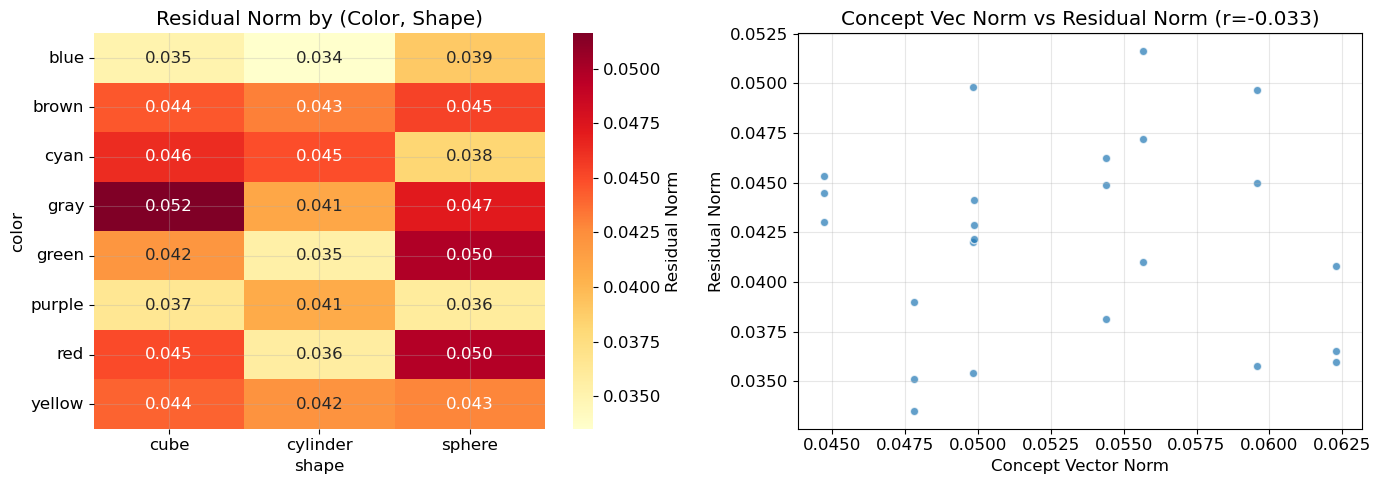

In [42]:
# ============================================================
# Residual analysis for the additivity test
# ============================================================

def analyse_additivity_residuals(additivity_results, concept_vectors, group_embeddings):
    """
    Decompose residuals from the additivity test.
    For each (color, shape) pair:
      residual = z_actual(color, shape) - z_predicted(color, shape)
    We ask:
      1. Are residuals systematic (correlated across shapes for the same color)?
      2. Is residual magnitude correlated with concept vector norm?
      3. Do residuals cluster by color or by shape?
    """
    colors = sorted(set(k[0] for k in group_embeddings))
    shapes = sorted(set(k[1] for k in group_embeddings))

    # Recompute shape/color marginals and grand mean
    color_embeddings = {}
    for color in colors:
        vecs = [group_embeddings[(color, s)] for s in shapes if (color, s) in group_embeddings]
        if len(vecs) >= 2:
            color_embeddings[color] = np.mean(vecs, axis=0)

    shape_embeddings = {}
    for shape in shapes:
        vecs = [group_embeddings[(c, shape)] for c in colors if (c, shape) in group_embeddings]
        if len(vecs) >= 2:
            shape_embeddings[shape] = np.mean(vecs, axis=0)

    grand_mean = np.mean(list(group_embeddings.values()), axis=0)
    cv = {c: color_embeddings[c] - grand_mean for c in color_embeddings}

    # Compute residuals
    residuals = []
    for color in colors:
        if color not in cv:
            continue
        for shape in shapes:
            if (color, shape) not in group_embeddings or shape not in shape_embeddings:
                continue
            z_actual = group_embeddings[(color, shape)]
            z_pred = shape_embeddings[shape] + cv[color]
            residual = z_actual - z_pred
            residuals.append({
                'color': color,
                'shape': shape,
                'residual': residual,
                'residual_norm': np.linalg.norm(residual),
                'concept_vec_norm': np.linalg.norm(cv[color]),
            })

    res_df = pd.DataFrame(residuals)

    # 1. Residual magnitude statistics
    print("Residual Analysis")
    print("=" * 60)
    print(f"Mean residual norm: {res_df['residual_norm'].mean():.4f}")
    print(f"Std residual norm:  {res_df['residual_norm'].std():.4f}")

    # 2. Correlation between concept vector norm and residual norm
    corr = np.corrcoef(res_df['concept_vec_norm'], res_df['residual_norm'])[0, 1]
    print(f"\nCorrelation (concept vec norm vs residual norm): {corr:.3f}")

    # 3. Cross-shape residual consistency per color
    print("\nCross-shape residual consistency (cosine sim of residuals):")
    residual_vecs_by_color = {}
    for _, row in res_df.iterrows():
        residual_vecs_by_color.setdefault(row['color'], []).append(
            row['residual'] / (np.linalg.norm(row['residual']) + 1e-10)
        )

    color_consistency = {}
    for color, vecs in sorted(residual_vecs_by_color.items()):
        if len(vecs) >= 2:
            sim_mat = cosine_similarity(np.stack(vecs))
            n = len(sim_mat)
            off_diag = [sim_mat[i, j] for i in range(n) for j in range(i + 1, n)]
            mean_sim = np.mean(off_diag)
            color_consistency[color] = mean_sim
            print(f"  {color}: {mean_sim:.3f}")

    # 4. Silhouette score: do residuals cluster by color or by shape?
    all_residual_vecs = np.stack(res_df['residual'].values)

    if len(res_df['color'].unique()) >= 2 and len(all_residual_vecs) >= 3:
        le_color = LabelEncoder()
        color_labels = le_color.fit_transform(res_df['color'])
        sil_color = silhouette_score(all_residual_vecs, color_labels, metric='cosine')
        print(f"\nSilhouette score (residuals clustered by color): {sil_color:.3f}")

    if len(res_df['shape'].unique()) >= 2 and len(all_residual_vecs) >= 3:
        le_shape = LabelEncoder()
        shape_labels = le_shape.fit_transform(res_df['shape'])
        sil_shape = silhouette_score(all_residual_vecs, shape_labels, metric='cosine')
        print(f"Silhouette score (residuals clustered by shape): {sil_shape:.3f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: residual norm by (color, shape)
    pivot = res_df.pivot(index='color', columns='shape', values='residual_norm')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0],
                cbar_kws={'label': 'Residual Norm'})
    axes[0].set_title('Residual Norm by (Color, Shape)')

    # Panel B: concept vector norm vs residual norm
    axes[1].scatter(res_df['concept_vec_norm'], res_df['residual_norm'],
                    alpha=0.7, edgecolors='white')
    axes[1].set_xlabel('Concept Vector Norm')
    axes[1].set_ylabel('Residual Norm')
    axes[1].set_title(f'Concept Vec Norm vs Residual Norm (r={corr:.3f})')

    plt.tight_layout()
    save_fig("resid_analysis")
    plt.show()

    return res_df, color_consistency


residual_df, color_consistency = analyse_additivity_residuals(
    additivity_results, concept_vectors, group_embeddings
)

# UMAP Visualisation of Embedding Geometry

For concepts where the linearity gap is large (MLP >> linear probe), UMAP reveals the geometric structure that linear probes cannot capture: clusters, entanglement, or curved manifolds.


Found 9 concepts with cached features for UMAP.
  Computing UMAP for has_red_object...
  Computing UMAP for has_sphere...
  Computing UMAP for has_large_object...
  Computing UMAP for has_metal_object...
  Computing UMAP for has_red_sphere...
  Computing UMAP for red_cube_vs_blue_cube...
  Computing UMAP for red_left_of_blue...
  Computing UMAP for small_in_front_of_large...
  Computing UMAP for count_objects...
Saved umap_clip.png + .pdf


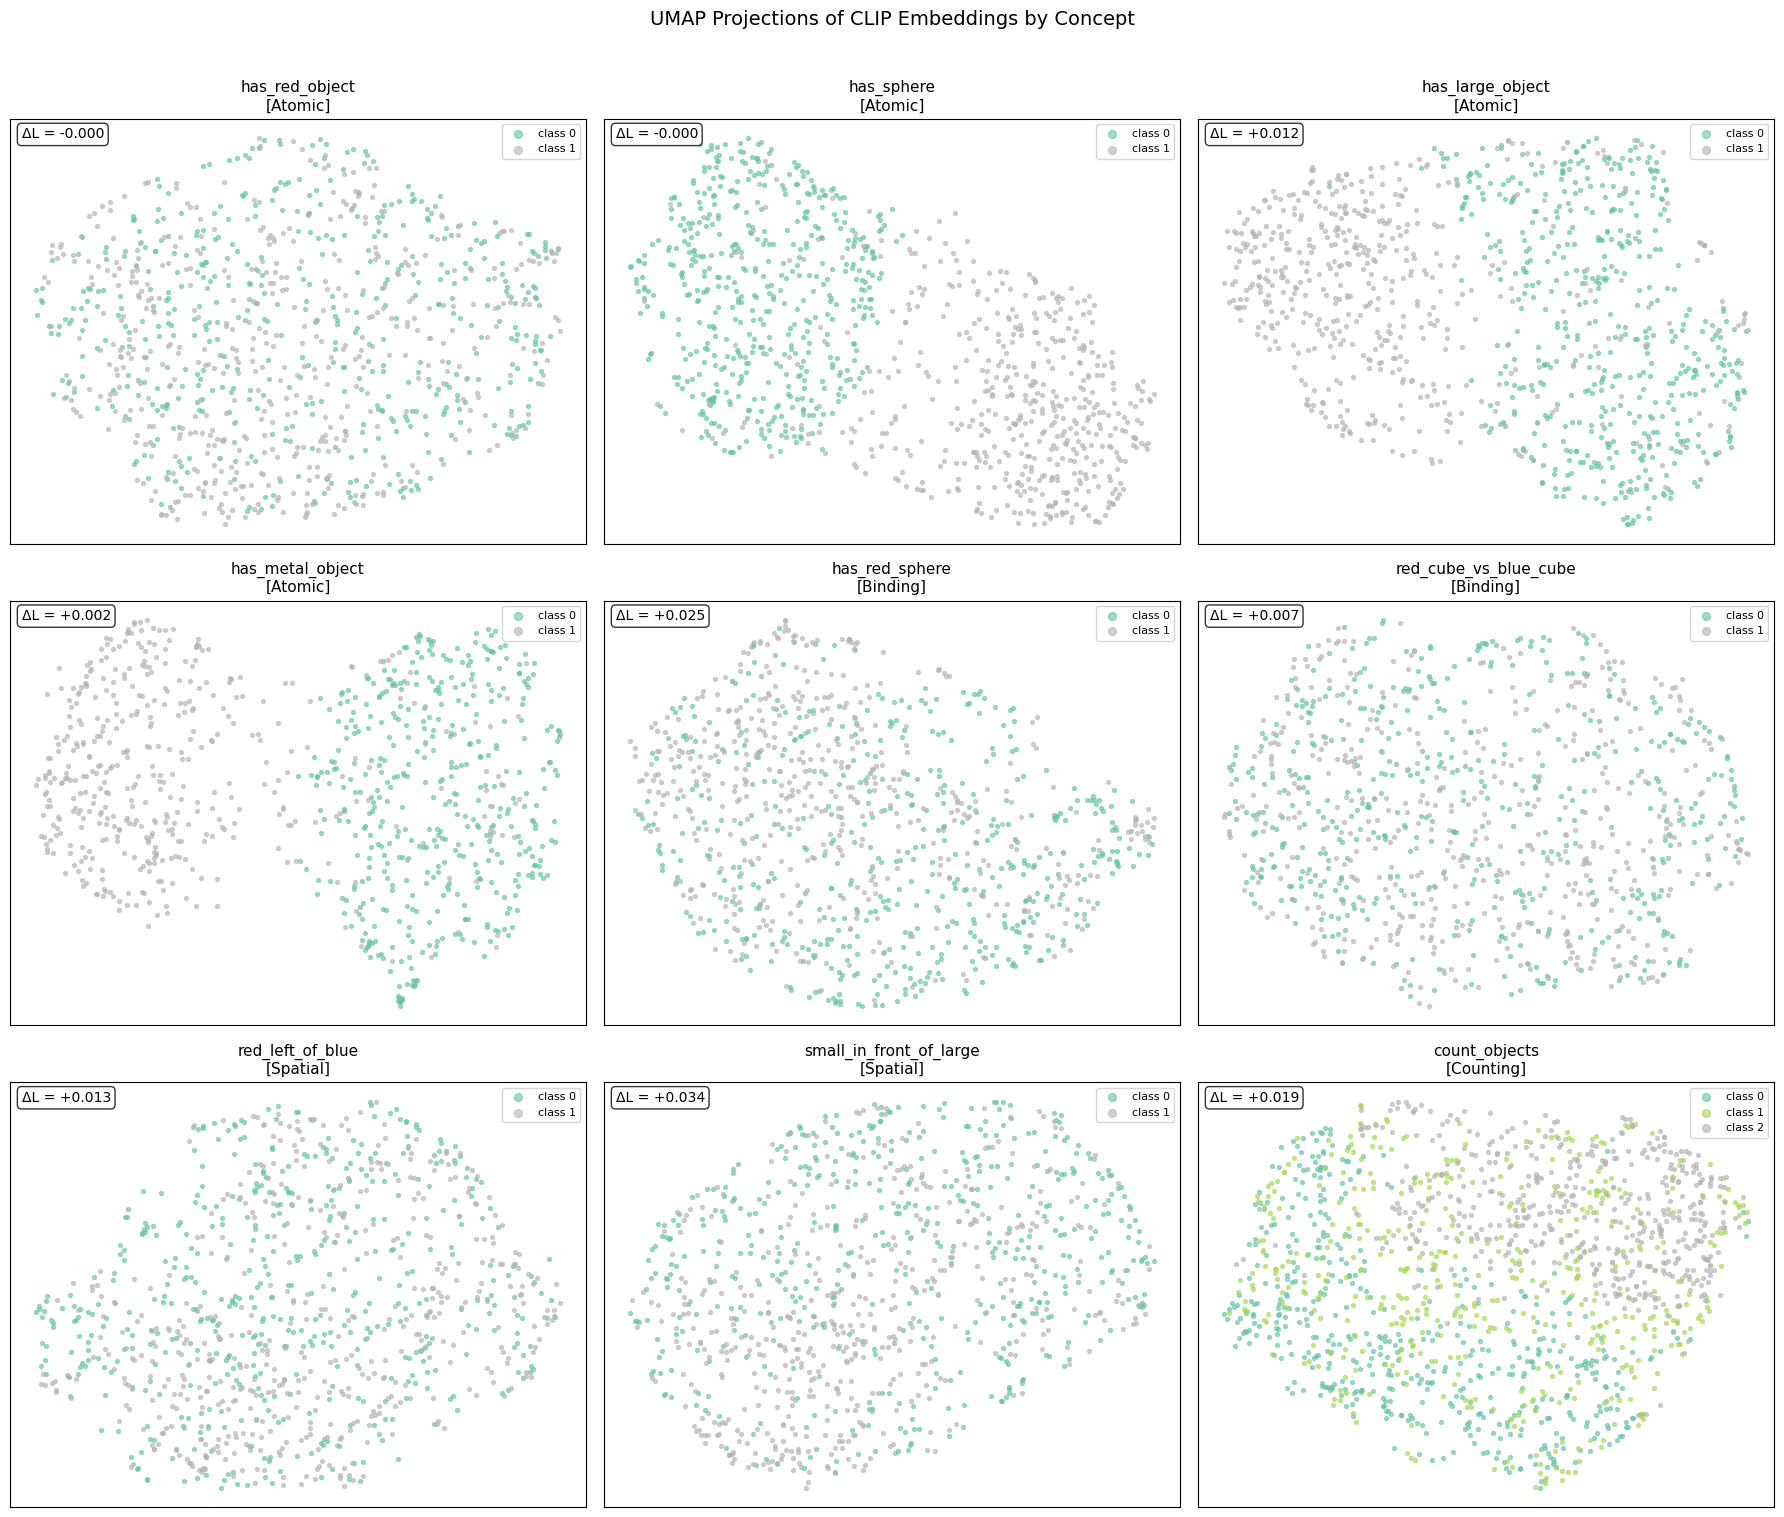

In [43]:
# ============================================================
# UMAP visualisation for selected concepts
# ============================================================


def load_cached_features(concept_name, cache_dir='feature_cache'):
    """Load features from the cache created by test_concept()."""
    cache_path = os.path.join(cache_dir, f"{concept_name}.npz")
    if os.path.exists(cache_path):
        data = np.load(cache_path)
        return data['features'], data['labels']
    return None, None


def plot_umap_grid(concepts_with_tiers, n_cols=3, cache_dir='feature_cache'):
    """
    UMAP plots for a list of (concept_name, tier_label) tuples.
    Colour-coded by class label.
    """
    # Filter to concepts with cached features
    valid = []
    for name, tier in concepts_with_tiers:
        feats, labels = load_cached_features(name, cache_dir)
        if feats is not None:
            valid.append((name, tier, feats, labels))

    if not valid:
        print("No cached features found for any concepts.")
        return

    n_plots = len(valid)
    n_cols = min(n_cols, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    tier_colors_map = {
        'Atomic': '#2ecc71', 'Binding': '#f39c12',
        'Spatial': '#e74c3c', 'Counting': '#9b59b6',
        'Object': '#3498db', 'Superclass': '#1abc9c',
        'Texture': '#e67e22',
    }

    for idx, (name, tier, feats, labels) in enumerate(valid):
        print(f"  Computing UMAP for {name}...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
        embedding_2d = reducer.fit_transform(feats)

        ax = axes[idx]
        unique_labels = np.unique(labels)
        cmap = plt.cm.Set2 if len(unique_labels) <= 8 else plt.cm.tab20

        for i, lbl in enumerate(unique_labels):
            mask = labels == lbl
            ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
                       s=8, alpha=0.6, label=f'class {lbl}',
                       color=cmap(i / max(len(unique_labels) - 1, 1)))

        # Linearity gap annotation
        if name in all_results:
            res = all_results[name]
            best_nl_auc = max(r['test_auc'] for r in res['nonlinear_results'].values())
            gap = best_nl_auc - res['linear_test_auc']
            ax.text(0.02, 0.98, f'ΔL = {gap:+.3f}',
                    transform=ax.transAxes, va='top', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set_title(f'{name}\n[{tier}]', fontsize=11)
        ax.legend(fontsize=8, markerscale=2)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide unused axes
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('UMAP Projections of CLIP Embeddings by Concept', fontsize=14, y=1.01)
    plt.tight_layout()
    save_fig("umap_clip")
    plt.show()


# Build the concept list — adjust based on what you've actually run
concepts_for_umap = []

# CLEVR concepts
clevr_concepts = [
    ('has_red_object', 'Atomic'),
    ('has_sphere', 'Atomic'),
    ('has_large_object', 'Atomic'),
    ('has_metal_object', 'Atomic'),
    ('has_red_sphere', 'Binding'),
    ('red_cube_vs_blue_cube', 'Binding'),
    ('red_left_of_blue', 'Spatial'),
    ('small_in_front_of_large', 'Spatial'),
    ('count_objects', 'Counting'),
]

# ImageNet concepts
imagenet_concepts = [
    ('imagenetmini_has_dog', 'Object'),
    ('imagenetmini_has_bird', 'Object'),
    ('imagenetmini_has_vehicle', 'Object'),
    ('imagenetmini_dog_vs_cat', 'Superclass'),
    ('imagenetmini_bird_vs_fish', 'Superclass'),
    ('imagenetmini_vehicle_vs_animal', 'Superclass'),
    ('imagenetmini_natural_vs_manmade', 'Superclass'),
]

# DTD concepts — all 12 you ran
dtd_concepts = [
    ('dtd_has_striped', 'Texture'),
    ('dtd_has_dotted', 'Texture'),
    ('dtd_has_chequered', 'Texture'),
    ('dtd_has_zigzagged', 'Texture'),
    ('dtd_has_woven', 'Texture'),
    ('dtd_has_knitted', 'Texture'),
    ('dtd_has_scaly', 'Texture'),
    ('dtd_has_cracked', 'Texture'),
    ('dtd_has_bumpy', 'Texture'),
    ('dtd_has_marbled', 'Texture'),
    ('dtd_has_porous', 'Texture'),
    ('dtd_has_wrinkled', 'Texture'),
]

for name, tier in clevr_concepts + imagenet_concepts + dtd_concepts:
    feats, labels = load_cached_features(name)
    if feats is not None:
        concepts_for_umap.append((name, tier))

print(f"Found {len(concepts_for_umap)} concepts with cached features for UMAP.")
plot_umap_grid(concepts_for_umap, n_cols=3)

# Unified Summary Table
Consolidates all results across datasets (CLEVR, ImageNet-Mini, DTD, ARO) into a single DataFrame for the central figure of the project.


In [44]:
# ============================================================
# Build unified summary across all datasets & benchmarks
# ============================================================


# --- Tier mappings ---
clevr_tier_map = {
    'has_red_object': ('Atomic', 'CLEVR'),
    'has_sphere': ('Atomic', 'CLEVR'),
    'has_large_object': ('Atomic', 'CLEVR'),
    'has_metal_object': ('Atomic', 'CLEVR'),
    'has_red_sphere': ('Binding', 'CLEVR'),
    'red_cube_vs_blue_cube': ('Binding', 'CLEVR'),
    'red_left_of_blue': ('Relational', 'CLEVR'),
    'small_in_front_of_large': ('Relational', 'CLEVR'),
    'count_objects': ('Counting', 'CLEVR'),
}

imagenet_concept_tiers = {
    'imagenetmini_has_dog': ('Object', 'ImageNet'),
    'imagenetmini_has_bird': ('Object', 'ImageNet'),
    'imagenetmini_has_vehicle': ('Object', 'ImageNet'),
    'imagenetmini_dog_vs_cat': ('Superclass', 'ImageNet'),
    'imagenetmini_bird_vs_fish': ('Superclass', 'ImageNet'),
    'imagenetmini_vehicle_vs_animal': ('Superclass', 'ImageNet'),
    'imagenetmini_natural_vs_manmade': ('Superclass', 'ImageNet'),
}

dtd_concept_tiers = {
    'dtd_has_striped': ('Texture', 'DTD'),
    'dtd_has_dotted': ('Texture', 'DTD'),
    'dtd_has_wrinkled': ('Texture', 'DTD'),
    'dtd_has_marbled': ('Texture', 'DTD'),
    'dtd_has_woven': ('Texture', 'DTD'),
    'dtd_has_zigzagged': ('Texture', 'DTD'),
    'dtd_has_chequered': ('Texture', 'DTD'),
}

all_tier_maps = {**clevr_tier_map, **imagenet_concept_tiers, **dtd_concept_tiers}

# --- Collect probe-based results ---
unified_rows = []

for name, res in all_results.items():
    tier_info = all_tier_maps.get(name, ('Other', 'Unknown'))
    tier_label, dataset = tier_info

    best_nl_auc = max(r['test_auc'] for r in res['nonlinear_results'].values())
    best_nl_acc = max(r['test_acc'] for r in res['nonlinear_results'].values())

    unified_rows.append({
        'Concept': name,
        'Dataset': dataset,
        'Tier': tier_label,
        'Linear Acc': res['linear_test_acc'],
        'Linear AUC': res['linear_test_auc'],
        'Best NL Acc': best_nl_acc,
        'Best NL AUC': best_nl_auc,
        'ΔAcc': best_nl_acc - res['linear_test_acc'],
        'ΔAUC': best_nl_auc - res['linear_test_auc'],
    })

# Add DTD results if stored differently
if 'dtd_results' in dir() and dtd_results:
    for concept_name, result in dtd_results.items():
        if concept_name in [r['Concept'] for r in unified_rows]:
            continue  # already added
        tier_info = all_tier_maps.get(concept_name, ('Texture', 'DTD'))
        tier_label, dataset = tier_info
        # Extract from dtd_results structure
        if isinstance(result, dict) and 'linear_test_auc' in result:
            best_nl_auc = max(r['test_auc'] for r in result['nonlinear_results'].values())
            best_nl_acc = max(r['test_acc'] for r in result['nonlinear_results'].values())
            unified_rows.append({
                'Concept': concept_name,
                'Dataset': dataset,
                'Tier': tier_label,
                'Linear Acc': result['linear_test_acc'],
                'Linear AUC': result['linear_test_auc'],
                'Best NL Acc': best_nl_acc,
                'Best NL AUC': best_nl_auc,
                'ΔAcc': best_nl_acc - result['linear_test_acc'],
                'ΔAUC': best_nl_auc - result['linear_test_auc'],
            })

# Add ARO as aggregate rows (these are accuracy-only, no probe)
if 'aro_df' in dir() and aro_df is not None:
    for _, row in aro_df.iterrows():
        unified_rows.append({
            'Concept': row['Dataset'],
            'Dataset': 'ARO',
            'Tier': 'Relational' if 'Relation' in row['Dataset'] else 'Binding',
            'Linear Acc': row['Accuracy'],
            'Linear AUC': row['Accuracy'],  # proxy: text-matching accuracy
            'Best NL Acc': np.nan,
            'Best NL AUC': np.nan,
            'ΔAcc': np.nan,
            'ΔAUC': np.nan,
        })

unified_df = pd.DataFrame(unified_rows)

# Define tier ordering for plots
tier_order = ['Texture', 'Object', 'Atomic', 'Superclass', 'Binding', 'Relational', 'Counting']
unified_df['Tier'] = pd.Categorical(unified_df['Tier'], categories=tier_order, ordered=True)
unified_df = unified_df.sort_values(['Tier', 'ΔAUC'])

print(unified_df.to_string(index=False, float_format='%.3f'))

                        Concept  Dataset       Tier  Linear Acc  Linear AUC  Best NL Acc  Best NL AUC   ΔAcc   ΔAUC
                dtd_has_striped      DTD    Texture       0.950       0.990        0.933        0.981 -0.017 -0.009
                 dtd_has_dotted      DTD    Texture       0.950       0.985        0.938        0.983 -0.012 -0.002
                  dtd_has_woven      DTD    Texture       0.933       0.989        0.917        0.987 -0.017 -0.002
                dtd_has_marbled      DTD    Texture       0.975       0.998        0.950        0.998 -0.025  0.000
              dtd_has_zigzagged      DTD    Texture       0.954       0.992        0.929        0.993 -0.025  0.001
              dtd_has_chequered      DTD    Texture       0.971       0.999        0.963        1.000 -0.008  0.001
               dtd_has_wrinkled      DTD    Texture       0.929       0.986        0.938        0.988  0.008  0.002
          imagenetmini_has_bird ImageNet     Object       0.802       0.

Saved lin_recoverability.png + .pdf


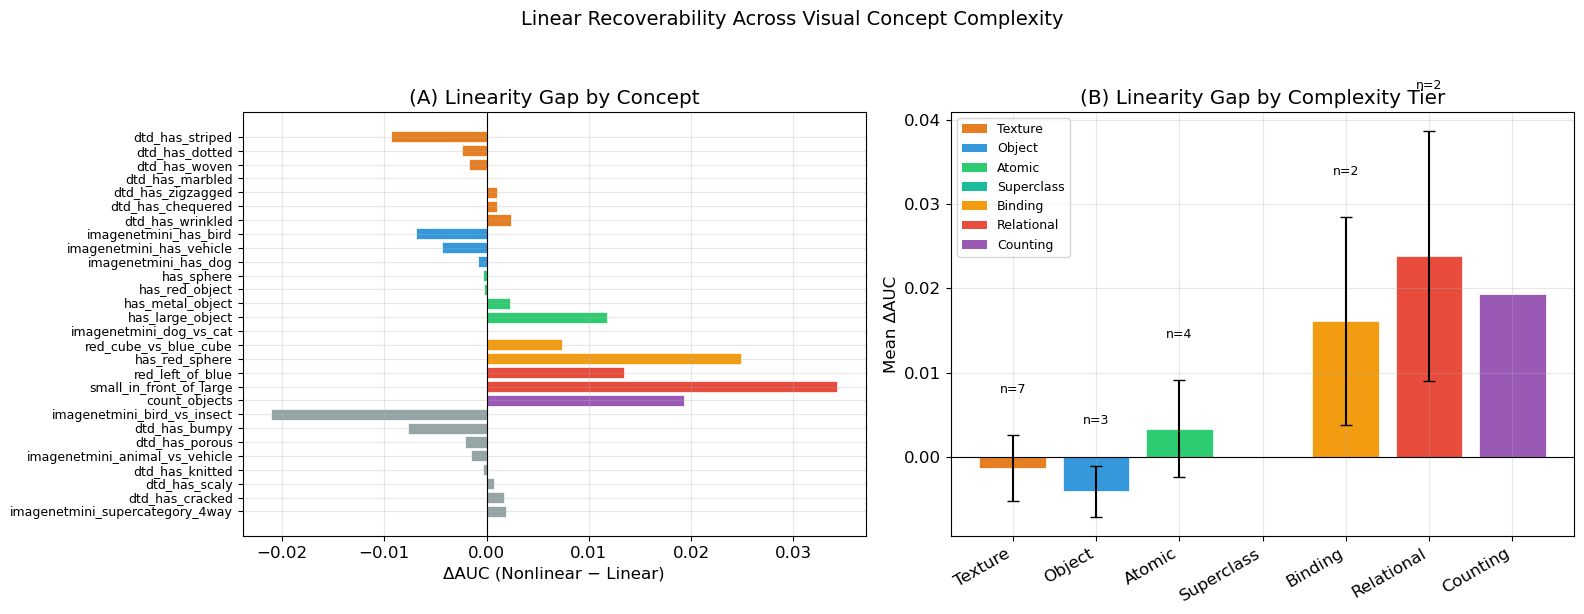

In [45]:
# ============================================================
# Linearity gap by concept complexity tier
# ============================================================

tier_colors = {
    'Texture': '#e67e22', 'Object': '#3498db', 'Atomic': '#2ecc71',
    'Superclass': '#1abc9c', 'Binding': '#f39c12',
    'Relational': '#e74c3c', 'Counting': '#9b59b6',
}

# Filter to probe-based results only (exclude ARO aggregate rows)
plot_df = unified_df.dropna(subset=['ΔAUC']).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: Individual concepts ---
ax = axes[0]
colors = [tier_colors.get(t, '#95a5a6') for t in plot_df['Tier']]
bars = ax.barh(range(len(plot_df)), plot_df['ΔAUC'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['Concept'], fontsize=9)
ax.set_xlabel('ΔAUC (Nonlinear − Linear)')
ax.set_title('(A) Linearity Gap by Concept')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()

# --- Panel B: Aggregated by tier ---
ax2 = axes[1]
tier_stats = plot_df.groupby('Tier', observed=True).agg(
    mean_gap=('ΔAUC', 'mean'),
    std_gap=('ΔAUC', 'std'),
    linear_auc=('Linear AUC', 'mean'),
    count=('ΔAUC', 'count'),
).reindex([t for t in tier_order if t in plot_df['Tier'].unique()])

bar_colors = [tier_colors.get(t, '#95a5a6') for t in tier_stats.index]
bars2 = ax2.bar(range(len(tier_stats)), tier_stats['mean_gap'],
                yerr=tier_stats['std_gap'], color=bar_colors,
                edgecolor='white', linewidth=0.5, capsize=4)
ax2.set_xticks(range(len(tier_stats)))
ax2.set_xticklabels(tier_stats.index, rotation=30, ha='right')
ax2.set_ylabel('Mean ΔAUC')
ax2.set_title('(B) Linearity Gap by Complexity Tier')
ax2.axhline(y=0, color='black', linewidth=0.8)

# Add count annotations
for i, (tier, row) in enumerate(tier_stats.iterrows()):
    ax2.text(i, row['mean_gap'] + row['std_gap'] + 0.005,
             f'n={int(row["count"])}', ha='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=tier_colors[t], label=t)
                   for t in tier_order if t in plot_df['Tier'].unique()]
ax2.legend(handles=legend_elements, fontsize=9, loc='upper left')

plt.suptitle('Linear Recoverability Across Visual Concept Complexity',
             fontsize=14, y=1.02)
plt.tight_layout()
save_fig("lin_recoverability")
plt.show()

In [46]:
# ============================================================
# Summary statistics for the paper
# ============================================================

print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)

for tier in tier_order:
    subset = plot_df[plot_df['Tier'] == tier]
    if len(subset) == 0:
        continue
    print(f"\n{tier} (n={len(subset)}):")
    print(f"  Linear AUC:  {subset['Linear AUC'].mean():.3f} ± {subset['Linear AUC'].std():.3f}")
    print(f"  Best NL AUC: {subset['Best NL AUC'].mean():.3f} ± {subset['Best NL AUC'].std():.3f}")
    print(f"  ΔAUC:        {subset['ΔAUC'].mean():+.3f} ± {subset['ΔAUC'].std():.3f}")

# ARO summary (separate since it's accuracy-only)
aro_rows = unified_df[unified_df['Dataset'] == 'ARO']
if len(aro_rows) > 0:
    print(f"\nARO Benchmark (text-matching, no probe):")
    for _, row in aro_rows.iterrows():
        print(f"  {row['Concept']}: accuracy = {row['Linear Acc']:.3f}")

print("\n" + "="*60)


SUMMARY FOR PAPER

Texture (n=7):
  Linear AUC:  0.991 ± 0.005
  Best NL AUC: 0.990 ± 0.007
  ΔAUC:        -0.001 ± 0.004

Object (n=3):
  Linear AUC:  0.921 ± 0.070
  Best NL AUC: 0.917 ± 0.073
  ΔAUC:        -0.004 ± 0.003

Atomic (n=4):
  Linear AUC:  0.992 ± 0.006
  Best NL AUC: 0.995 ± 0.001
  ΔAUC:        +0.003 ± 0.006

Superclass (n=1):
  Linear AUC:  1.000 ± nan
  Best NL AUC: 1.000 ± nan
  ΔAUC:        +0.000 ± nan

Binding (n=2):
  Linear AUC:  0.902 ± 0.030
  Best NL AUC: 0.918 ± 0.018
  ΔAUC:        +0.016 ± 0.012

Relational (n=2):
  Linear AUC:  0.870 ± 0.044
  Best NL AUC: 0.894 ± 0.029
  ΔAUC:        +0.024 ± 0.015

Counting (n=1):
  Linear AUC:  0.970 ± nan
  Best NL AUC: 0.989 ± nan
  ΔAUC:        +0.019 ± nan

ARO Benchmark (text-matching, no probe):
  VG_Attribution: accuracy = 0.588
  VG_Relation: accuracy = 0.501



# ARO → Probe Pipeline

Converting ARO from a text-matching benchmark into a probe task so we can measure the linearity gap on **natural-image** compositionalit


In [47]:
# ============================================================
# Extract CLIP image embeddings from ARO datasets
# ============================================================


@torch.no_grad()
def extract_aro_image_features(dataset, indices=None, batch_size=64):
    """
    Extract CLIP image embeddings from an ARO dataset.
    Returns features array of shape (N, embed_dim).
    """
    model.eval()
    if indices is None:
        indices = np.arange(len(dataset))

    all_features = []

    for start in tqdm(range(0, len(indices), batch_size), desc="Extracting ARO image features"):
        batch_idx = indices[start:start + batch_size]
        image_tensors = []

        for idx in batch_idx:
            item = dataset[int(idx)]
            image = item["image_options"][0]
            if not torch.is_tensor(image):
                image = preprocess(image)
            image_tensors.append(image)

        image_batch = torch.stack(image_tensors).to(device)
        features = model.encode_image(image_batch)
        features = features / features.norm(dim=-1, keepdim=True)
        all_features.append(features.cpu().numpy())

    return np.concatenate(all_features, axis=0)


# Extract features for both datasets
# Use the same indices as your ARO evaluation for consistency
print("Extracting VG-Attribution image features...")
vga_indices = aro_results["VG_Attribution"]["indices"]
vga_features = extract_aro_image_features(aro_vg_attr, indices=vga_indices)
print(f"  Shape: {vga_features.shape}")

print("\nExtracting VG-Relation image features...")
vgr_indices = aro_results["VG_Relation"]["indices"]
vgr_features = extract_aro_image_features(aro_vg_rel, indices=vgr_indices)
print(f"  Shape: {vgr_features.shape}")

# Cache them
os.makedirs("feature_cache", exist_ok=True)
np.savez("feature_cache/aro_vg_attribution.npz", features=vga_features,
         labels=aro_results["VG_Attribution"]["correct"].astype(int),
         indices=vga_indices)
np.savez("feature_cache/aro_vg_relation.npz", features=vgr_features,
         labels=aro_results["VG_Relation"]["correct"].astype(int),
         indices=vgr_indices)
print("\nCached ARO features.")

Extracting VG-Attribution image features...


Extracting ARO image features: 100%|██████████| 450/450 [01:54<00:00,  3.93it/s]


  Shape: (28748, 512)

Extracting VG-Relation image features...


Extracting ARO image features: 100%|██████████| 375/375 [01:34<00:00,  3.96it/s]


  Shape: (23937, 512)

Cached ARO features.


In [48]:
# ============================================================
# Probe Task 1: Predict attribute-pair / relation-type from image embedding
#
# This tests whether CLIP's image encoder linearly encodes WHICH
# compositional structure is present. High linear accuracy = the concept
# type is linearly represented. Low linear but high MLP = nonlinear encoding.
# ============================================================


def run_probe_cv(features, labels, probe_type="linear", n_folds=5, random_state=42):
    if probe_type == "linear":
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, solver="lbfgs", C=1.0,
                               random_state=random_state)
        )
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
        scores = cross_val_score(clf, features, labels, cv=skf, scoring="accuracy")
        return scores.mean(), scores.std()
    else:
        # Run all three MLP depths, return the best
        mlp_configs = {
            "mlp_1layer": (128,),
            "mlp_2layer": (128, 64),
            "mlp_3layer": (128, 64, 32),
        }
        best_mean = -1
        best_std = 0
        for name, hidden in mlp_configs.items():
            clf = make_pipeline(
                StandardScaler(),
                MLPClassifier(hidden_layer_sizes=hidden, activation="relu",
                              alpha=1e-2, learning_rate_init=1e-3, max_iter=2000,
                              early_stopping=True, validation_fraction=0.15,
                              n_iter_no_change=30, random_state=random_state)
            )
            skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
            scores = cross_val_score(clf, features, labels, cv=skf, scoring="accuracy")
            if scores.mean() > best_mean:
                best_mean = scores.mean()
                best_std = scores.std()
        return best_mean, best_std


def probe_aro_group_classification(features, group_labels, dataset_name, min_group_size=50, max_groups=20):
    """
    Train probes to classify which attribute-pair or relation type
    an image belongs to. Filters to top groups by frequency.
    """
    # Filter to groups with enough examples
    counter = Counter(group_labels)
    top_groups = [g for g, c in counter.most_common(max_groups) if c >= min_group_size]

    mask = np.array([g in top_groups for g in group_labels])
    X = features[mask]
    y_raw = np.array(group_labels)[mask]

    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    n_classes = len(le.classes_)
    print(f"\n{'='*60}")
    print(f"Probe: {dataset_name} group classification")
    print(f"  {n_classes} groups, {len(y)} total examples")
    print(f"  Groups: {list(le.classes_)}")
    print(f"{'='*60}")

    # Run cross-validated probes
    lin_acc, lin_std = run_probe_cv(X, y, probe_type="linear")
    mlp_acc, mlp_std = run_probe_cv(X, y, probe_type="mlp")

    gap = mlp_acc - lin_acc

    print(f"\n  Linear probe:  {lin_acc:.3f} ± {lin_std:.3f}")
    print(f"  MLP probe:     {mlp_acc:.3f} ± {mlp_std:.3f}")
    print(f"  Linearity gap: {gap:+.3f}")

    return {
        "concept": dataset_name,
        "n_classes": n_classes,
        "n_examples": len(y),
        "linear_acc": lin_acc,
        "linear_std": lin_std,
        "mlp_acc": mlp_acc,
        "mlp_std": mlp_std,
        "gap": gap,
    }


# --- Extract group labels from raw ARO items ---
# The ARO dataset objects are Subsets; access the underlying data via .dataset[i]

# VG-Attribution: each item has an "attributes" list (e.g. ["open", "white"]).
# Join into a single string for multiclass group classification.
vga_raw_items = [aro_vg_attr.dataset[int(i)] for i in vga_indices]
vga_attributes = np.array(
    ["_".join(sorted(item["attributes"])) for item in vga_raw_items],
    dtype=object,
)
vga_group_result = probe_aro_group_classification(
    vga_features, vga_attributes, "VG_Attribution_groups"
)

# VG-Relation: each item has a "relation_name" string.
vgr_raw_items = [aro_vg_rel.dataset[int(i)] for i in vgr_indices]
vgr_relations = np.array(
    [item["relation_name"] for item in vgr_raw_items],
    dtype=object,
)
vgr_group_result = probe_aro_group_classification(
    vgr_features, vgr_relations, "VG_Relation_groups"
)


Probe: VG_Attribution_groups group classification
  20 groups, 4429 total examples
  Groups: ['black_blue', 'black_brown', 'black_gray', 'black_green', 'black_white', 'blue_brown', 'blue_gray', 'blue_green', 'blue_large', 'blue_white', 'brown_gray', 'brown_green', 'brown_white', 'gray_green', 'gray_white', 'green_large', 'green_white', 'large_white', 'red_white', 'white_wood']

  Linear probe:  0.211 ± 0.014
  MLP probe:     0.248 ± 0.017
  Linearity gap: +0.037

Probe: VG_Relation_groups group classification
  20 groups, 22720 total examples
  Groups: ['above', 'at', 'behind', 'below', 'by', 'holding', 'in', 'in front of', 'lying on', 'near', 'next to', 'of', 'on', 'on top of', 'sitting on', 'to the left of', 'to the right of', 'under', 'wearing', 'with']

  Linear probe:  0.280 ± 0.006
  MLP probe:     0.333 ± 0.006
  Linearity gap: +0.053


In [49]:
# ============================================================
# Probe Task 2: Predict CLIP correctness from image embedding
#
# Label = did CLIP rank the correct caption higher?
# If a linear probe can predict CLIP's success/failure from the
# image embedding, that tells us the embedding geometry correlates
# with compositional understanding. If only an MLP can predict it,
# the relevant structure is nonlinear.
# ============================================================

def probe_correctness(features, correct_labels, dataset_name):
    """
    Probe whether CLIP's compositional success/failure is
    linearly predictable from the image embedding.
    """
    y = correct_labels.astype(int)

    print(f"\n{'='*60}")
    print(f"Probe: {dataset_name} correctness prediction")
    print(f"  {len(y)} examples, {y.sum()} correct ({y.mean():.1%})")
    print(f"{'='*60}")

    lin_acc, lin_std = run_probe_cv(features, y, probe_type="linear")
    mlp_acc, mlp_std = run_probe_cv(features, y, probe_type="mlp")

    gap = mlp_acc - lin_acc

    print(f"\n  Linear probe:  {lin_acc:.3f} ± {lin_std:.3f}")
    print(f"  MLP probe:     {mlp_acc:.3f} ± {mlp_std:.3f}")
    print(f"  Linearity gap: {gap:+.3f}")

    return {
        "concept": dataset_name,
        "n_examples": len(y),
        "base_rate": float(y.mean()),
        "linear_acc": lin_acc,
        "linear_std": lin_std,
        "mlp_acc": mlp_acc,
        "mlp_std": mlp_std,
        "gap": gap,
    }


vga_correct_result = probe_correctness(
    vga_features, aro_results["VG_Attribution"]["correct"], "VG_Attribution_correctness"
)

vgr_correct_result = probe_correctness(
    vgr_features, aro_results["VG_Relation"]["correct"], "VG_Relation_correctness"
)


Probe: VG_Attribution_correctness correctness prediction
  28748 examples, 16892 correct (58.8%)

  Linear probe:  0.601 ± 0.003
  MLP probe:     0.638 ± 0.005
  Linearity gap: +0.037

Probe: VG_Relation_correctness correctness prediction
  23937 examples, 11986 correct (50.1%)

  Linear probe:  0.484 ± 0.005
  MLP probe:     0.477 ± 0.009
  Linearity gap: -0.007


In [50]:
# ============================================================
# Probe Task 3: Per-relation / per-attribute binary probes
#
# For each individual relation (e.g. "sitting on", "behind") or
# attribute pair (e.g. "black_white"), train a binary probe:
# does this image contain this relation/attribute?
# This parallels the CLEVR atomic/binding probes but on natural images.
# ============================================================

def probe_per_group_binary(features, group_labels, dataset_name, min_group_size=100, max_groups=15):
    """
    For each group (relation or attribute pair), train a one-vs-rest
    binary probe. Reports linearity gap per group.
    """
    counter = Counter(group_labels)
    top_groups = [g for g, c in counter.most_common(max_groups) if c >= min_group_size]

    results = []

    for group in top_groups:
        y = (np.array(group_labels) == group).astype(int)
        n_pos = y.sum()
        n_neg = (1 - y).sum()

        # Subsample negatives to 3:1 ratio for balance
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]
        n_neg_sample = min(len(neg_idx), 3 * n_pos)
        rng = np.random.default_rng(42)
        neg_sample = rng.choice(neg_idx, size=n_neg_sample, replace=False)

        idx = np.concatenate([pos_idx, neg_sample])
        X = features[idx]
        y_bal = y[idx]

        lin_acc, lin_std = run_probe_cv(X, y_bal, probe_type="linear")
        mlp_acc, mlp_std = run_probe_cv(X, y_bal, probe_type="mlp")
        gap = mlp_acc - lin_acc

        results.append({
            "group": group,
            "n_positive": n_pos,
            "linear_acc": lin_acc,
            "mlp_acc": mlp_acc,
            "gap": gap,
        })

        print(f"  {group:30s}  n={n_pos:4d}  linear={lin_acc:.3f}  mlp={mlp_acc:.3f}  Δ={gap:+.3f}")

    results_df = pd.DataFrame(results).sort_values("gap", ascending=False)
    return results_df


print("\n" + "="*60)
print("Per-relation binary probes (VG-Relation)")
print("="*60)
vgr_per_relation_df = probe_per_group_binary(
    vgr_features, vgr_relations, "VG_Relation"
)

print("\n" + "="*60)
print("Per-attribute binary probes (VG-Attribution)")
print("="*60)
vga_per_attr_df = probe_per_group_binary(
    vga_features, vga_attributes, "VG_Attribution"
)


Per-relation binary probes (VG-Relation)
  to the left of                  n=7741  linear=0.651  mlp=0.666  Δ=+0.015
  to the right of                 n=7741  linear=0.651  mlp=0.668  Δ=+0.017
  on                              n=1684  linear=0.784  mlp=0.798  Δ=+0.013
  wearing                         n= 949  linear=0.867  mlp=0.886  Δ=+0.019
  in                              n= 708  linear=0.765  mlp=0.796  Δ=+0.030
  near                            n= 689  linear=0.761  mlp=0.845  Δ=+0.084
  in front of                     n= 588  linear=0.699  mlp=0.755  Δ=+0.056
  behind                          n= 574  linear=0.699  mlp=0.750  Δ=+0.051
  of                              n= 367  linear=0.713  mlp=0.773  Δ=+0.060
  above                           n= 269  linear=0.678  mlp=0.748  Δ=+0.071
  below                           n= 209  linear=0.658  mlp=0.746  Δ=+0.089
  next to                         n= 203  linear=0.695  mlp=0.772  Δ=+0.078
  on top of                       n= 201  line

Saved synth_v_natural.png + .pdf


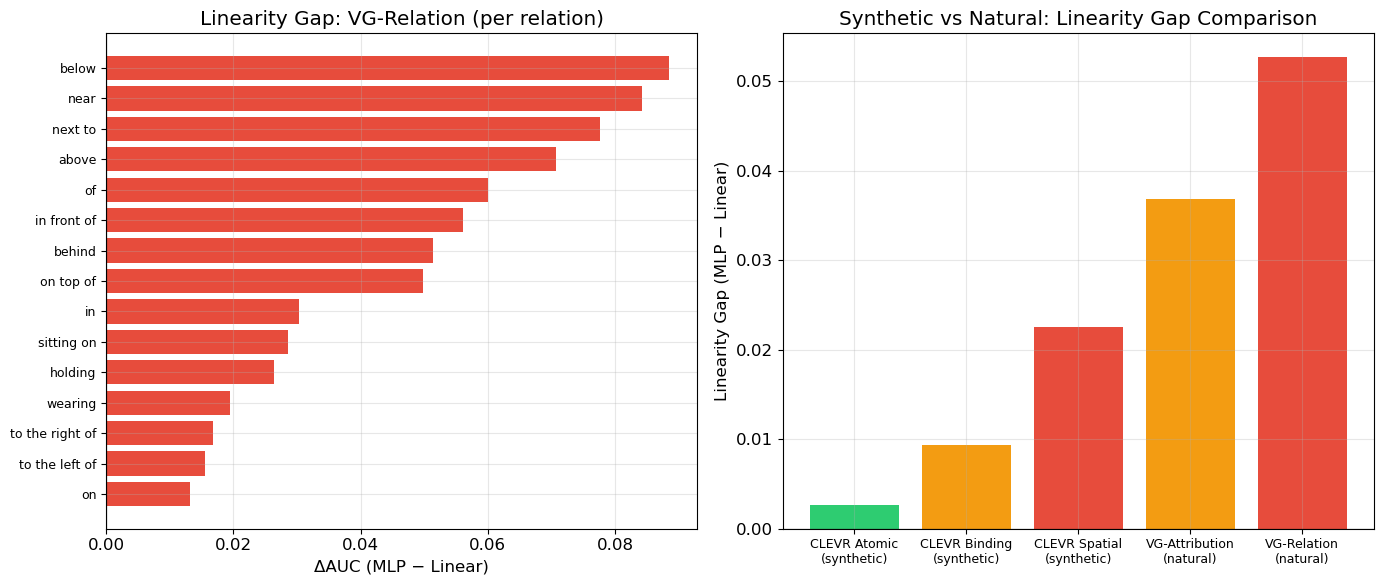


Key finding: linearity gap is near-zero on synthetic CLEVR images
but substantially larger on natural VG images for the SAME concept types.
This supports the hypothesis that image complexity, not just concept
complexity, determines when linear recoverability breaks down.


In [51]:
# ============================================================
# Summary plot: ARO probe results vs CLEVR/DTD
# ============================================================


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Per-group linearity gaps for relations
ax = axes[0]
df = vgr_per_relation_df.sort_values("gap")
colors = ['#e74c3c' if g > 0.01 else '#3498db' for g in df["gap"]]
ax.barh(range(len(df)), df["gap"], color=colors)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["group"], fontsize=9)
ax.set_xlabel("ΔAUC (MLP − Linear)")
ax.set_title("Linearity Gap: VG-Relation (per relation)")
ax.axvline(x=0, color="black", linewidth=0.8)

# Panel B: Comparison across all probe types
ax2 = axes[1]
comparison_data = {
    "CLEVR Atomic\n(synthetic)": np.mean([all_results[c]["auc_gaps"].get("mlp_2layer", 0)
                                           for c in ["has_red_object", "has_sphere", "has_metal_object", "has_large_object"]
                                           if c in all_results]),
    "CLEVR Binding\n(synthetic)": np.mean([all_results[c]["auc_gaps"].get("mlp_2layer", 0)
                                            for c in ["has_red_sphere", "red_cube_vs_blue_cube"]
                                            if c in all_results]),
    "CLEVR Spatial\n(synthetic)": np.mean([all_results[c]["auc_gaps"].get("mlp_2layer", 0)
                                            for c in ["red_left_of_blue", "small_in_front_of_large"]
                                            if c in all_results]),
    "VG-Attribution\n(natural)": vga_group_result["gap"],
    "VG-Relation\n(natural)": vgr_group_result["gap"],
}

labels = list(comparison_data.keys())
gaps = list(comparison_data.values())
colors = ["#2ecc71", "#f39c12", "#e74c3c", "#f39c12", "#e74c3c"]

ax2.bar(range(len(labels)), gaps, color=colors)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Linearity Gap (MLP − Linear)")
ax2.set_title("Synthetic vs Natural: Linearity Gap Comparison")
ax2.axhline(y=0, color="black", linewidth=0.8)

plt.tight_layout()
save_fig("synth_v_natural")
plt.show()

print("\nKey finding: linearity gap is near-zero on synthetic CLEVR images")
print("but substantially larger on natural VG images for the SAME concept types.")
print("This supports the hypothesis that image complexity, not just concept")
print("complexity, determines when linear recoverability breaks down.")

In [52]:
# ============================================================
# Save ARO probe results
# ============================================================

aro_probe_results = {
    "vga_group_result": vga_group_result,
    "vgr_group_result": vgr_group_result,
    "vga_correct_result": vga_correct_result,
    "vgr_correct_result": vgr_correct_result,
    "vgr_per_relation_df": vgr_per_relation_df,
    "vga_per_attr_df": vga_per_attr_df,
}

SAVE_DIR = os.path.join(os.getcwd(), "results_cache")
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f'{SAVE_DIR}/aro_probe_results.pkl', 'wb') as f:
    pickle.dump(aro_probe_results, f)
print("Saved ARO probe results.")

Saved ARO probe results.


UMAP on 20674 examples across 8 relations
Saved geometry_clip_natural.png + .pdf


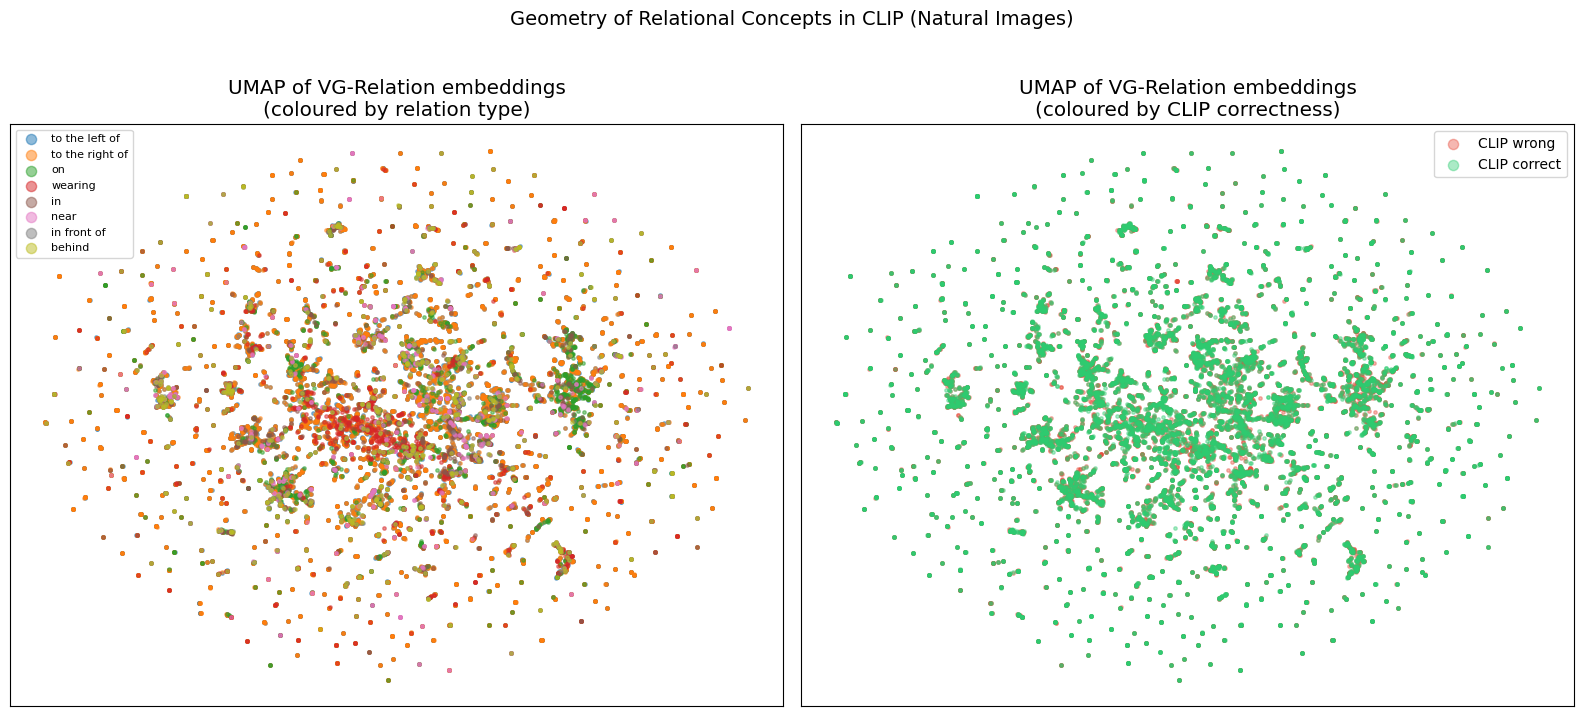

In [53]:
# ============================================================
# UMAP: Visualise nonlinear geometry in VG-Relation embeddings
# ============================================================


# Focus on top relations by frequency
counter = Counter(vgr_relations)
top_relations = [r for r, c in counter.most_common(8)]

mask = np.array([r in top_relations for r in vgr_relations])
X_sub = vgr_features[mask]
y_sub = np.array(vgr_relations)[mask]

print(f"UMAP on {len(X_sub)} examples across {len(top_relations)} relations")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel A: coloured by relation type
ax = axes[0]
cmap = plt.cm.tab10
for i, rel in enumerate(top_relations):
    rel_mask = y_sub == rel
    ax.scatter(embedding_2d[rel_mask, 0], embedding_2d[rel_mask, 1],
               s=6, alpha=0.5, label=rel, color=cmap(i / len(top_relations)))
ax.set_title("UMAP of VG-Relation embeddings\n(coloured by relation type)")
ax.legend(fontsize=8, markerscale=3, loc="best")
ax.set_xticks([])
ax.set_yticks([])

# Panel B: coloured by CLIP correctness
ax2 = axes[1]
correct_sub = aro_results["VG_Relation"]["correct"][mask]
ax2.scatter(embedding_2d[~correct_sub, 0], embedding_2d[~correct_sub, 1],
            s=6, alpha=0.4, label="CLIP wrong", color="#e74c3c")
ax2.scatter(embedding_2d[correct_sub, 0], embedding_2d[correct_sub, 1],
            s=6, alpha=0.4, label="CLIP correct", color="#2ecc71")
ax2.set_title("UMAP of VG-Relation embeddings\n(coloured by CLIP correctness)")
ax2.legend(fontsize=10, markerscale=3)
ax2.set_xticks([])
ax2.set_yticks([])

plt.suptitle("Geometry of Relational Concepts in CLIP (Natural Images)", fontsize=14, y=1.02)
plt.tight_layout()
save_fig("geometry_clip_natural")
plt.show()

UMAP on 20674 examples across 8 relations
Saved geometry_clip_cleaner.png + .pdf


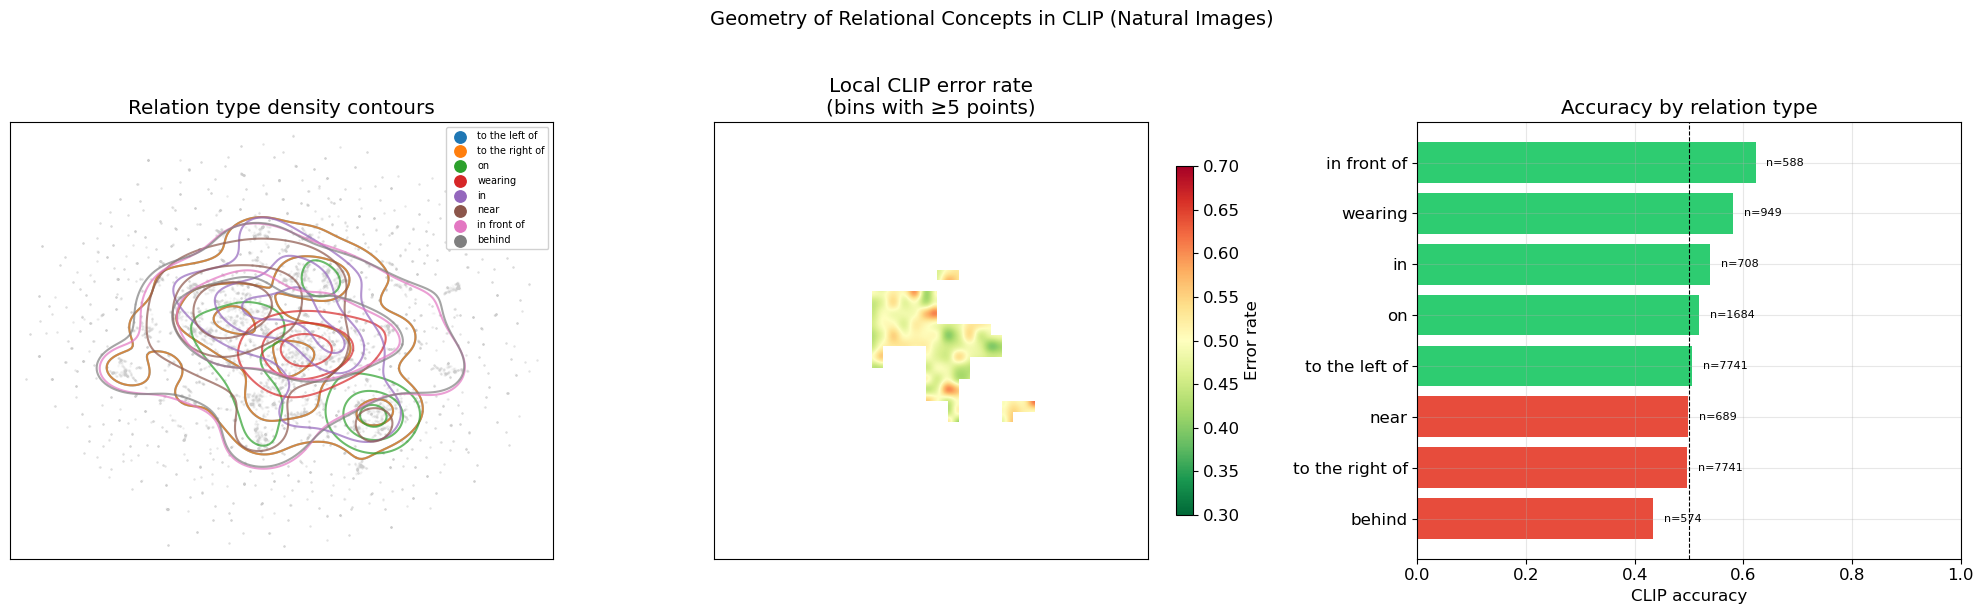

In [54]:
# ============================================================
# UMAP: VG-Relation embeddings — density-based visualisation
# ============================================================

from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

counter = Counter(vgr_relations)
top_relations = [r for r, c in counter.most_common(8)]

mask = np.array([r in top_relations for r in vgr_relations])
X_sub = vgr_features[mask]
y_sub = np.array(vgr_relations)[mask]
correct_sub = aro_results["VG_Relation"]["correct"][mask]

print(f"UMAP on {len(X_sub)} examples across {len(top_relations)} relations")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(X_sub)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel A: relation type, one subplot per relation using contours ---
ax = axes[0]
ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
           s=1, alpha=0.05, color="#cccccc", rasterized=True)
cmap = plt.cm.tab10
for i, rel in enumerate(top_relations):
    rel_mask = y_sub == rel
    pts = embedding_2d[rel_mask]
    if len(pts) > 50:
        try:
            kde = gaussian_kde(pts.T)
            # Evaluate on a grid
            xmin, xmax = embedding_2d[:, 0].min() - 1, embedding_2d[:, 0].max() + 1
            ymin, ymax = embedding_2d[:, 1].min() - 1, embedding_2d[:, 1].max() + 1
            xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200),
                                 np.linspace(ymin, ymax, 200))
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            ax.contour(xx, yy, zz, levels=3, colors=[cmap(i)], alpha=0.7, linewidths=1.5)
        except Exception:
            pass
    ax.scatter([], [], color=cmap(i), s=30, label=rel)

ax.legend(fontsize=7, markerscale=1.5, loc="best", framealpha=0.9)
ax.set_title("Relation type density contours")
ax.set_xticks([])
ax.set_yticks([])

# --- Panel B: local failure rate heatmap ---
ax2 = axes[1]
from matplotlib.colors import TwoSlopeNorm

# Bin the UMAP space into a grid and compute local error rate
n_bins = 40
xmin, xmax = embedding_2d[:, 0].min(), embedding_2d[:, 0].max()
ymin, ymax = embedding_2d[:, 1].min(), embedding_2d[:, 1].max()

x_edges = np.linspace(xmin, xmax, n_bins + 1)
y_edges = np.linspace(ymin, ymax, n_bins + 1)

error_rate_grid = np.full((n_bins, n_bins), np.nan)

x_bin = np.digitize(embedding_2d[:, 0], x_edges) - 1
y_bin = np.digitize(embedding_2d[:, 1], y_edges) - 1
x_bin = np.clip(x_bin, 0, n_bins - 1)
y_bin = np.clip(y_bin, 0, n_bins - 1)

for i in range(n_bins):
    for j in range(n_bins):
        bin_mask = (x_bin == i) & (y_bin == j)
        if bin_mask.sum() >= 5:  # minimum points per bin
            error_rate_grid[j, i] = 1 - correct_sub[bin_mask].mean()

im = ax2.imshow(error_rate_grid, origin='lower', aspect='auto',
                extent=[xmin, xmax, ymin, ymax],
                cmap='RdYlGn_r', vmin=0.3, vmax=0.7,
                interpolation='gaussian')
plt.colorbar(im, ax=ax2, label='Error rate', shrink=0.8)
ax2.set_title(f"Local CLIP error rate\n(bins with ≥5 points)")
ax2.set_xticks([])
ax2.set_yticks([])

# --- Panel C: per-relation accuracy bar chart for context ---
ax3 = axes[2]
rel_accs = []
for rel in top_relations:
    rel_mask = y_sub == rel
    acc = correct_sub[rel_mask].mean()
    rel_accs.append({"relation": rel, "accuracy": acc, "n": rel_mask.sum()})

rel_acc_df = pd.DataFrame(rel_accs).sort_values("accuracy")
colors = ['#e74c3c' if a < 0.5 else '#2ecc71' for a in rel_acc_df["accuracy"]]
ax3.barh(rel_acc_df["relation"], rel_acc_df["accuracy"], color=colors)
ax3.axvline(x=0.5, color="black", linewidth=0.8, linestyle="--", label="chance")
ax3.set_xlabel("CLIP accuracy")
ax3.set_title("Accuracy by relation type")
ax3.set_xlim(0, 1)
for i, (_, row) in enumerate(rel_acc_df.iterrows()):
    ax3.text(row["accuracy"] + 0.02, i, f'n={row["n"]}', va='center', fontsize=8)

plt.suptitle("Geometry of Relational Concepts in CLIP (Natural Images)", fontsize=14, y=1.02)
plt.tight_layout()
save_fig("geometry_clip_cleaner")
plt.show()

# Quantitative Geometry Analysis

# Intrinsic Dimensionality Estimation

If linear recoverability degrades for complex concepts, one explanation is that those concepts occupy higher-dimensional manifolds in CLIP's embedding space. We estimate intrinsic dimensionality (ID) per concept tier using the TwoNN estimator (Facco et al., 2017), which estimates the dimension of the data manifold from nearest-neighbour distance ratios. Higher ID suggests more complex geometric structure that a single linear hyperplane cannot capture.


Estimating intrinsic dimensionality...

has_red_object                            tier=Atomic        ID=23.3  n=1000
has_sphere                                tier=Atomic        ID=22.3  n=1000
has_large_object                          tier=Atomic        ID=20.3  n=1000
has_metal_object                          tier=Atomic        ID=20.0  n=870
has_red_sphere                            tier=Binding       ID=25.0  n=1000
red_cube_vs_blue_cube                     tier=Binding       ID=24.7  n=1000
red_left_of_blue                          tier=Relational    ID=24.8  n=1000
small_in_front_of_large                   tier=Relational    ID=21.0  n=1000
count_objects                             tier=Counting      ID=21.4  n=1500

Intrinsic Dimensionality by Tier
            mean  std  count
Tier                        
Atomic      21.5  1.6      4
Binding     24.8  0.2      2
Relational  22.9  2.7      2
Counting    21.4  NaN      1
Saved intrinsic_dim_est.png + .pdf


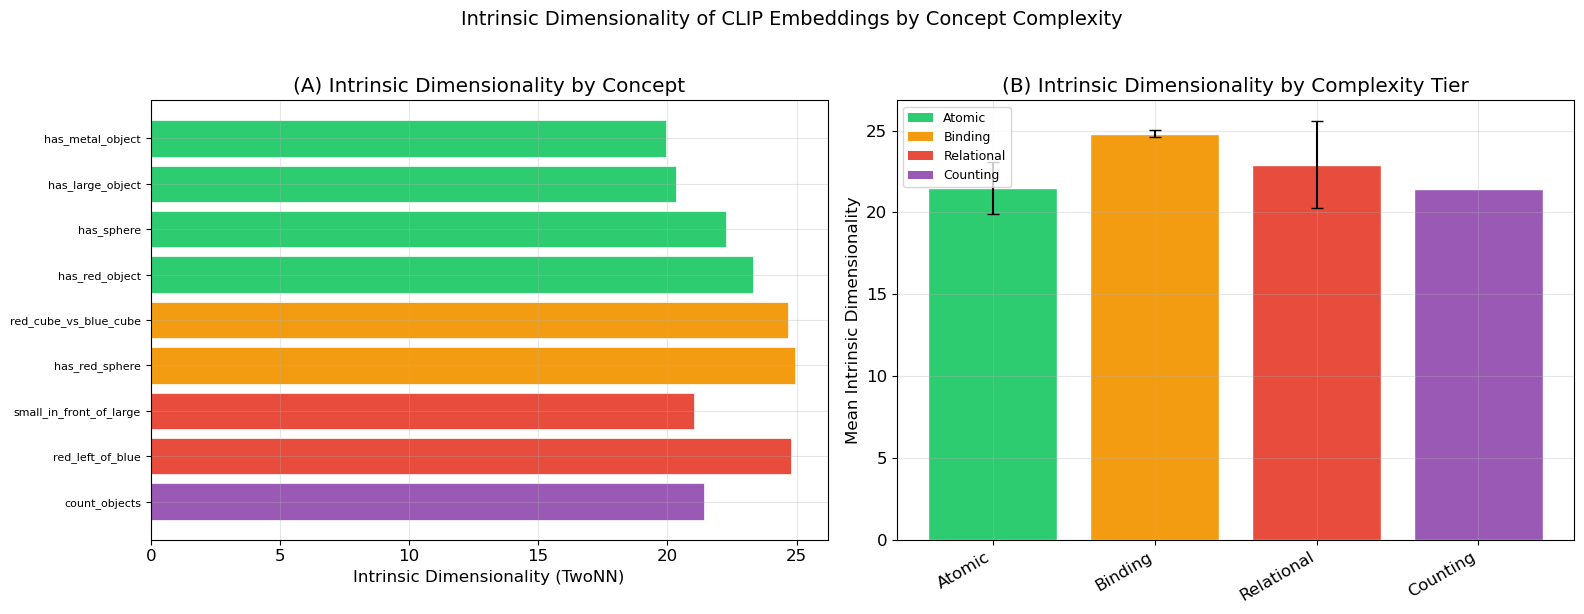

In [55]:
# Intrinsic dimensionality estimation per concept tier

def estimate_intrinsic_dimensionality(cache_dir="feature_cache"):
    """
    Estimate intrinsic dimensionality of CLIP embeddings per concept
    using the TwoNN estimator.
    """
    from skdim.id import TwoNN

    concept_tier_map = {
        # CLEVR-style atomic concepts
        "has_red_object": "Atomic",
        "has_sphere": "Atomic",
        "has_large_object": "Atomic",
        "has_metal_object": "Atomic",

        # Binding concepts
        "has_red_sphere": "Binding",
        "red_cube_vs_blue_cube": "Binding",

        # Relational concepts
        "red_left_of_blue": "Relational",
        "small_in_front_of_large": "Relational",

        # Counting
        "count_objects": "Counting",

        # ImageNetMini object concepts
        "imagenetmini_has_dog": "Object",
        "imagenetmini_has_bird": "Object",
        "imagenetmini_has_vehicle": "Object",

        # ImageNetMini superclass concepts
        "imagenetmini_dog_vs_cat": "Superclass",
        "imagenetmini_bird_vs_insect": "Superclass",
        "imagenetmini_animal_vs_vehicle": "Superclass",
        "imagenetmini_natural_vs_manmade": "Superclass",
    }

    # DTD texture concepts
    dtd_textures = [
        "striped", "dotted", "chequered", "zigzagged",
        "woven", "knitted", "scaly", "cracked",
        "bumpy", "marbled", "porous", "wrinkled",
    ]

    for texture in dtd_textures:
        concept_tier_map[f"dtd_has_{texture}"] = "Texture"

    results = []
    twonn = TwoNN()

    for concept, tier in concept_tier_map.items():
        cache_path = os.path.join(cache_dir, f"{concept}.npz")

        if not os.path.exists(cache_path):
            continue

        data = np.load(cache_path)
        features = data["features"]

        if len(features) < 10:
            continue

        try:
            twonn.fit(features)
            id_est = twonn.dimension_

            results.append({
                "Concept": concept,
                "Tier": tier,
                "Intrinsic Dim": id_est,
                "N samples": len(features),
            })

            print(
                f"{concept:40s}  "
                f"tier={tier:12s}  "
                f"ID={id_est:.1f}  "
                f"n={len(features)}"
            )

        except Exception as e:
            print(f"{concept}: TwoNN failed ({e})")

    return pd.DataFrame(results)


print("Estimating intrinsic dimensionality...\n")
id_df = estimate_intrinsic_dimensionality()

if len(id_df) > 0:
    tier_order = [
        "Texture",
        "Object",
        "Atomic",
        "Superclass",
        "Binding",
        "Relational",
        "Counting",
    ]

    id_df["Tier"] = pd.Categorical(
        id_df["Tier"],
        categories=tier_order,
        ordered=True,
    )

    # Summary by tier
    print("\n" + "=" * 60)
    print("Intrinsic Dimensionality by Tier")
    print("=" * 60)

    tier_id = (
        id_df
        .groupby("Tier", observed=True)["Intrinsic Dim"]
        .agg(["mean", "std", "count"])
    )

    print(tier_id.to_string(float_format="%.1f"))

    # Colors by tier
    tier_colors = {
        "Texture": "#e67e22",
        "Object": "#3498db",
        "Atomic": "#2ecc71",
        "Superclass": "#1abc9c",
        "Binding": "#f39c12",
        "Relational": "#e74c3c",
        "Counting": "#9b59b6",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel A: per-concept intrinsic dimensionality
    ax = axes[0]

    id_sorted = id_df.sort_values(["Tier", "Intrinsic Dim"])
    colors = [tier_colors.get(t, "#95a5a6") for t in id_sorted["Tier"]]

    ax.barh(
        range(len(id_sorted)),
        id_sorted["Intrinsic Dim"],
        color=colors,
        edgecolor="white",
        linewidth=0.5,
    )

    ax.set_yticks(range(len(id_sorted)))
    ax.set_yticklabels(id_sorted["Concept"], fontsize=8)
    ax.set_xlabel("Intrinsic Dimensionality (TwoNN)")
    ax.set_title("(A) Intrinsic Dimensionality by Concept")
    ax.invert_yaxis()

    # Panel B: mean intrinsic dimensionality by tier
    ax2 = axes[1]

    tier_stats = (
        id_df
        .groupby("Tier", observed=True)["Intrinsic Dim"]
        .agg(["mean", "std"])
    )

    tier_stats = tier_stats.reindex(
        [tier for tier in tier_order if tier in tier_stats.index]
    )

    bar_colors = [tier_colors.get(t, "#95a5a6") for t in tier_stats.index]

    ax2.bar(
        range(len(tier_stats)),
        tier_stats["mean"],
        yerr=tier_stats["std"],
        color=bar_colors,
        edgecolor="white",
        capsize=4,
    )

    ax2.set_xticks(range(len(tier_stats)))
    ax2.set_xticklabels(tier_stats.index, rotation=30, ha="right")
    ax2.set_ylabel("Mean Intrinsic Dimensionality")
    ax2.set_title("(B) Intrinsic Dimensionality by Complexity Tier")

    legend_elements = [
        mpatches.Patch(facecolor=tier_colors[tier], label=tier)
        for tier in tier_order
        if tier in id_df["Tier"].unique()
    ]

    ax2.legend(
        handles=legend_elements,
        fontsize=9,
        loc="upper left",
    )

    plt.suptitle(
        "Intrinsic Dimensionality of CLIP Embeddings by Concept Complexity",
        fontsize=14,
        y=1.02,
    )

    plt.tight_layout()
    save_fig("intrinsic_dim_est")
    plt.show()

else:
    print("No cached feature files found.")

# Cluster Separability (Silhouette Scores)

UMAP visualisations suggest that some concepts form cleanly separable clusters while others show entanglement. We quantify this with the silhouette score computed in the *original* high-dimensional CLIP embedding space (not the UMAP projection). A score near +1 indicates clean linear separability; scores near 0 indicate overlapping/entangled clusters.


Computing silhouette scores...

has_red_object                            tier=Atomic        sil=+0.047  ΔAUC=-0.000
has_sphere                                tier=Atomic        sil=+0.197  ΔAUC=-0.000
has_large_object                          tier=Atomic        sil=+0.141  ΔAUC=+0.012
has_metal_object                          tier=Atomic        sil=+0.203  ΔAUC=+0.002
has_red_sphere                            tier=Binding       sil=+0.051  ΔAUC=+0.025
red_cube_vs_blue_cube                     tier=Binding       sil=+0.038  ΔAUC=+0.007
red_left_of_blue                          tier=Relational    sil=+0.038  ΔAUC=+0.013
small_in_front_of_large                   tier=Relational    sil=+0.047  ΔAUC=+0.034
count_objects                             tier=Counting      sil=+0.032  ΔAUC=+0.019
Saved cluster_separability.png + .pdf


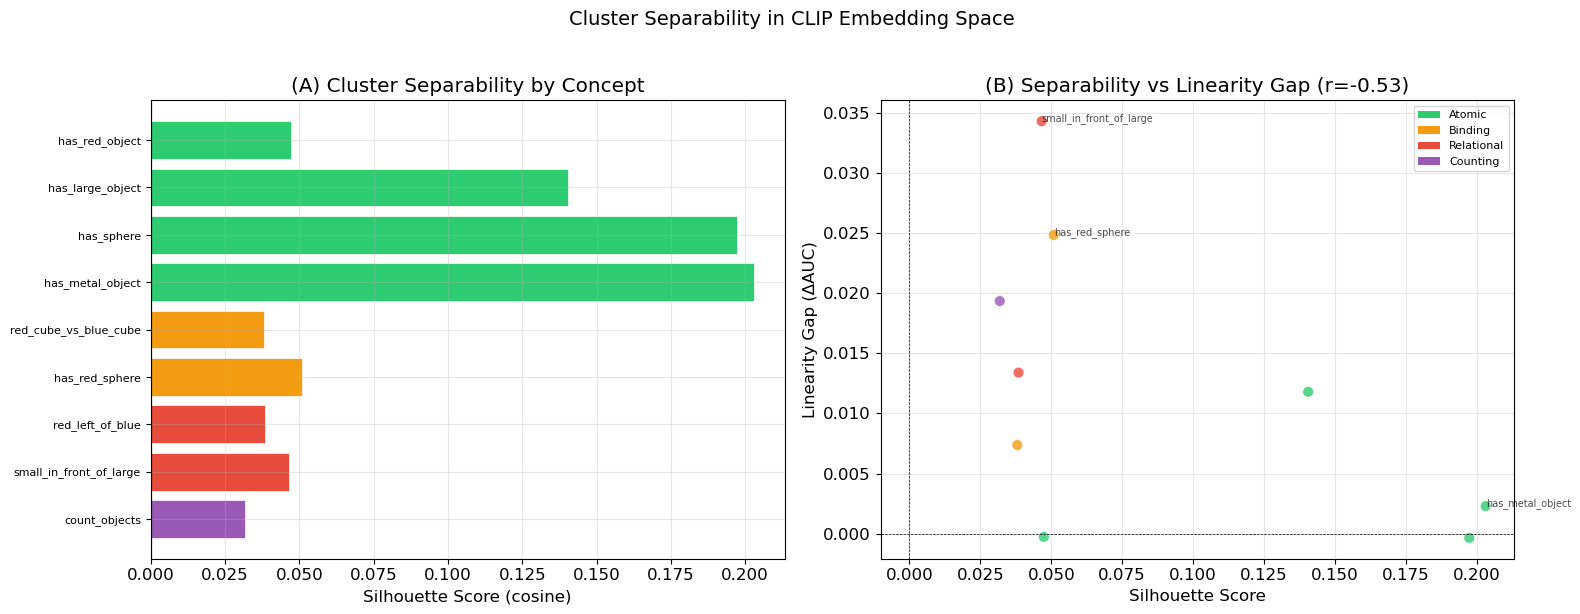


Silhouette Score by Tier
            mean   std  count
Tier                         
Atomic     0.147 0.072      4
Binding    0.044 0.009      2
Relational 0.043 0.006      2
Counting   0.032   NaN      1


In [56]:
# ============================================================
# Silhouette scores in high-dimensional CLIP space
# ============================================================

def compute_silhouette_scores(cache_dir="feature_cache"):
    """
    Compute silhouette scores for all cached concepts.

    Silhouette is computed in the original CLIP embedding space
    using cosine distance.
    """
    concept_tier_map = {
        # CLEVR-style atomic concepts
        "has_red_object": "Atomic",
        "has_sphere": "Atomic",
        "has_large_object": "Atomic",
        "has_metal_object": "Atomic",

        # Binding concepts
        "has_red_sphere": "Binding",
        "red_cube_vs_blue_cube": "Binding",

        # Relational concepts
        "red_left_of_blue": "Relational",
        "small_in_front_of_large": "Relational",

        # Counting
        "count_objects": "Counting",

        # ImageNetMini object concepts
        "imagenetmini_has_dog": "Object",
        "imagenetmini_has_bird": "Object",
        "imagenetmini_has_vehicle": "Object",

        # ImageNetMini superclass concepts
        "imagenetmini_dog_vs_cat": "Superclass",
        "imagenetmini_bird_vs_insect": "Superclass",
        "imagenetmini_animal_vs_vehicle": "Superclass",
        "imagenetmini_natural_vs_manmade": "Superclass",
    }

    # DTD texture concepts
    dtd_textures = [
        "striped", "dotted", "chequered", "zigzagged",
        "woven", "knitted", "scaly", "cracked",
        "bumpy", "marbled", "porous", "wrinkled",
    ]

    for texture in dtd_textures:
        concept_tier_map[f"dtd_has_{texture}"] = "Texture"

    results = []

    for concept, tier in concept_tier_map.items():
        cache_path = os.path.join(cache_dir, f"{concept}.npz")

        if not os.path.exists(cache_path):
            continue

        data = np.load(cache_path)
        features = data["features"]
        labels = data["labels"]

        if len(np.unique(labels)) < 2 or len(features) < 10:
            continue

        # Subsample for speed if needed
        if len(features) > 2000:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(features), 2000, replace=False)
            features = features[idx]
            labels = labels[idx]

        sil = silhouette_score(features, labels, metric="cosine")

        # Get linearity gap if all_results exists and contains this concept
        gap = np.nan

        if "all_results" in globals() and concept in all_results:
            res = all_results[concept]
            nonlinear_results = res.get("nonlinear_results", {})

            if len(nonlinear_results) > 0 and "linear_test_auc" in res:
                best_nl_auc = max(
                    r["test_auc"]
                    for r in nonlinear_results.values()
                    if "test_auc" in r
                )
                gap = best_nl_auc - res["linear_test_auc"]

        results.append({
            "Concept": concept,
            "Tier": tier,
            "Silhouette": sil,
            "ΔAUC": gap,
        })

        print(
            f"{concept:40s}  "
            f"tier={tier:12s}  "
            f"sil={sil:+.3f}  "
            f"ΔAUC={gap:+.3f}"
        )

    return pd.DataFrame(results)


print("Computing silhouette scores...\n")
sil_df = compute_silhouette_scores()

if len(sil_df) > 0:
    tier_order = [
        "Texture",
        "Object",
        "Atomic",
        "Superclass",
        "Binding",
        "Relational",
        "Counting",
    ]

    sil_df["Tier"] = pd.Categorical(
        sil_df["Tier"],
        categories=tier_order,
        ordered=True,
    )

    tier_colors = {
        "Texture": "#e67e22",
        "Object": "#3498db",
        "Atomic": "#2ecc71",
        "Superclass": "#1abc9c",
        "Binding": "#f39c12",
        "Relational": "#e74c3c",
        "Counting": "#9b59b6",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --------------------------------------------------------
    # Panel A: Silhouette by concept
    # --------------------------------------------------------
    ax = axes[0]

    sil_sorted = sil_df.sort_values(["Tier", "Silhouette"])
    colors = [tier_colors.get(t, "#95a5a6") for t in sil_sorted["Tier"]]

    ax.barh(
        range(len(sil_sorted)),
        sil_sorted["Silhouette"],
        color=colors,
        edgecolor="white",
        linewidth=0.5,
    )

    ax.set_yticks(range(len(sil_sorted)))
    ax.set_yticklabels(sil_sorted["Concept"], fontsize=8)
    ax.set_xlabel("Silhouette Score (cosine)")
    ax.set_title("(A) Cluster Separability by Concept")
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.invert_yaxis()

    # --------------------------------------------------------
    # Panel B: Silhouette vs linearity gap
    # --------------------------------------------------------
    ax2 = axes[1]

    valid = sil_df.dropna(subset=["ΔAUC"])

    if len(valid) > 0:
        colors_scatter = [
            tier_colors.get(t, "#95a5a6")
            for t in valid["Tier"]
        ]

        ax2.scatter(
            valid["Silhouette"],
            valid["ΔAUC"],
            c=colors_scatter,
            s=60,
            edgecolors="white",
            linewidths=0.5,
            alpha=0.8,
        )

        corr = np.corrcoef(valid["Silhouette"], valid["ΔAUC"])[0, 1]

        ax2.set_xlabel("Silhouette Score")
        ax2.set_ylabel("Linearity Gap (ΔAUC)")
        ax2.set_title(f"(B) Separability vs Linearity Gap (r={corr:.2f})")

        ax2.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
        ax2.axvline(x=0, color="black", linewidth=0.5, linestyle="--")

        # Label clear outliers
        for _, row in valid.iterrows():
            if abs(row["ΔAUC"]) > 0.02 or abs(row["Silhouette"]) > 0.2:
                short_name = (
                    row["Concept"]
                    .replace("imagenetmini_", "IN_")
                    .replace("dtd_has_", "dtd_")
                )

                ax2.annotate(
                    short_name,
                    (row["Silhouette"], row["ΔAUC"]),
                    fontsize=7,
                    alpha=0.7,
                )

    else:
        ax2.text(
            0.5,
            0.5,
            "No ΔAUC values available",
            ha="center",
            va="center",
            transform=ax2.transAxes,
        )

        ax2.set_title("(B) Separability vs Linearity Gap")
        ax2.set_xlabel("Silhouette Score")
        ax2.set_ylabel("Linearity Gap (ΔAUC)")

    legend_elements = [
        mpatches.Patch(facecolor=tier_colors[tier], label=tier)
        for tier in tier_order
        if tier in sil_df["Tier"].unique()
    ]

    ax2.legend(handles=legend_elements, fontsize=8)

    plt.suptitle(
        "Cluster Separability in CLIP Embedding Space",
        fontsize=14,
        y=1.02,
    )

    plt.tight_layout()
    save_fig("cluster_separability")
    plt.show()

    # Summary by tier
    print("\n" + "=" * 60)
    print("Silhouette Score by Tier")
    print("=" * 60)

    tier_sil = (
        sil_df
        .groupby("Tier", observed=True)["Silhouette"]
        .agg(["mean", "std", "count"])
    )

    print(tier_sil.to_string(float_format="%.3f"))

else:
    print("No cached feature files found.")

# Linear Probe Geometry: CKA Between Concept Weight Vectors

If CLIP organises different concept types in orthogonal subspaces, the weight vectors of linear probes for different concepts should be roughly orthogonal across tiers but more aligned within tiers. We compute centred kernel alignment (CKA, Kornblith et al. 2019) between the weight matrices of linear probes trained on different concepts to test this structural hypothesis.


Saved cka.png + .pdf


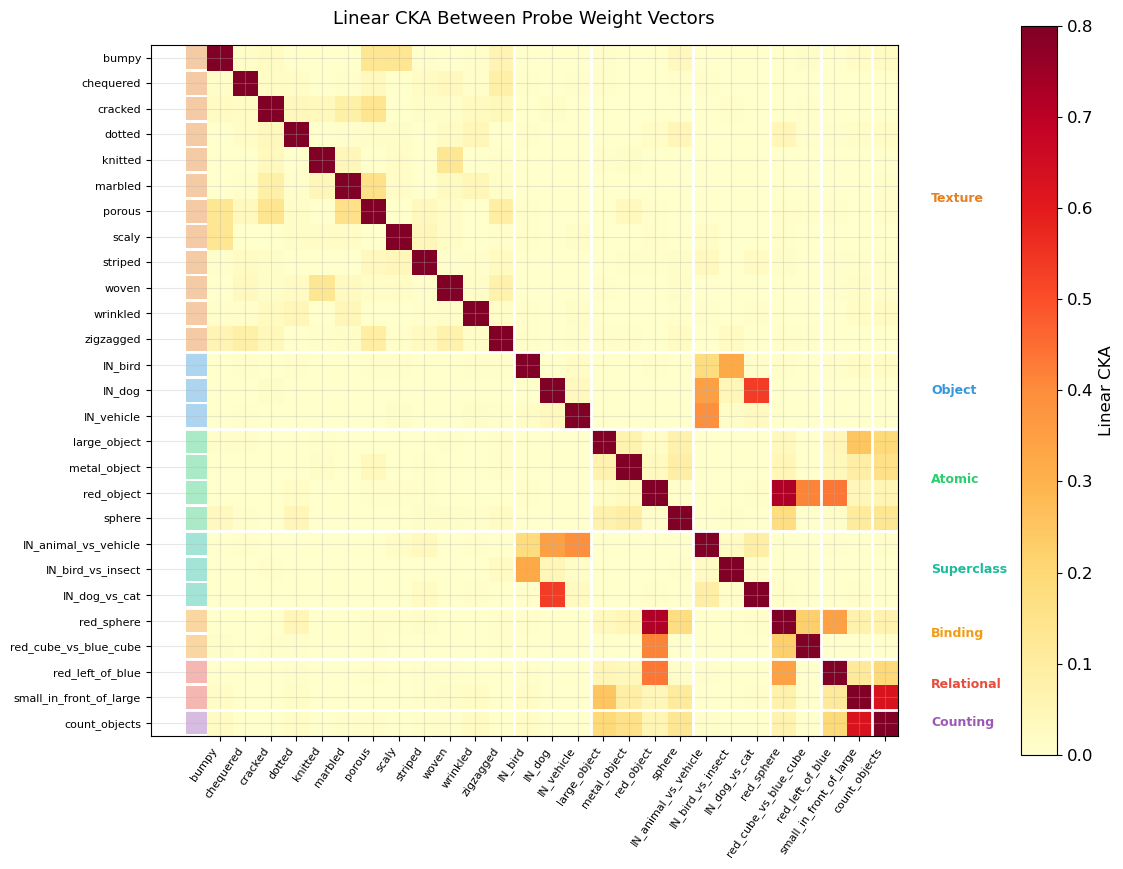


CKA: Within-Tier vs Between-Tier
Within-tier CKA:  0.033 ± 0.043 (n=80)
Between-tier CKA: 0.026 ± 0.089 (n=271)
Difference: +0.007

CKA: Within-Tier vs Between-Tier
Within-tier CKA:  0.033 ± 0.043 (n=80)
Between-tier CKA: 0.026 ± 0.089 (n=271)
Difference: +0.007
→ Concept types share largely overlapping representation subspaces


In [57]:
# ============================================================
# CKA between linear probe weight vectors
# ============================================================

def linear_cka(X, Y):
    """
    Compute linear CKA between two representation matrices.

    Here, we use it to compare linear probe weight matrices.
    For probe weights, X and Y are typically transposed weight matrices:
        X: (embedding_dim, n_classes_x)
        Y: (embedding_dim, n_classes_y)
    """
    # Gram matrices
    K = X @ X.T
    L = Y @ Y.T

    # Center Gram matrices
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n

    K_centered = H @ K @ H
    L_centered = H @ L @ H

    # CKA = HSIC(X, Y) / sqrt(HSIC(X, X) * HSIC(Y, Y))
    hsic_xy = np.sum(K_centered * L_centered)
    hsic_xx = np.sum(K_centered * K_centered)
    hsic_yy = np.sum(L_centered * L_centered)

    if hsic_xx == 0 or hsic_yy == 0:
        return 0.0

    return hsic_xy / np.sqrt(hsic_xx * hsic_yy)


def compute_cka_matrix():
    """
    Compute pairwise linear CKA between fitted linear probe weight vectors.
    """
    concept_tier_map = {
        # CLEVR-style atomic concepts
        "has_red_object": "Atomic",
        "has_sphere": "Atomic",
        "has_large_object": "Atomic",
        "has_metal_object": "Atomic",

        # Binding concepts
        "has_red_sphere": "Binding",
        "red_cube_vs_blue_cube": "Binding",

        # Relational concepts
        "red_left_of_blue": "Relational",
        "small_in_front_of_large": "Relational",

        # Counting
        "count_objects": "Counting",

        # ImageNetMini object concepts
        "imagenetmini_has_dog": "Object",
        "imagenetmini_has_bird": "Object",
        "imagenetmini_has_vehicle": "Object",

        # ImageNetMini superclass concepts
        "imagenetmini_dog_vs_cat": "Superclass",
        "imagenetmini_bird_vs_insect": "Superclass",
        "imagenetmini_animal_vs_vehicle": "Superclass",
        "imagenetmini_natural_vs_manmade": "Superclass",
    }

    # DTD texture concepts
    dtd_textures = [
        "striped", "dotted", "chequered", "zigzagged",
        "woven", "knitted", "scaly", "cracked",
        "bumpy", "marbled", "porous", "wrinkled",
    ]

    for texture in dtd_textures:
        concept_tier_map[f"dtd_has_{texture}"] = "Texture"

    if "all_results" not in globals():
        print("all_results not found. Run the probe-training cell first.")
        return None

    concepts_with_weights = []
    weight_matrices = []

    for concept, tier in concept_tier_map.items():
        if concept not in all_results:
            continue

        clf = all_results[concept].get("linear_clf")

        if clf is None or not hasattr(clf, "coef_"):
            continue

        W = clf.coef_

        # Ensure W is 2D
        if W.ndim == 1:
            W = W.reshape(1, -1)

        concepts_with_weights.append((concept, tier))
        weight_matrices.append(W)

    if len(concepts_with_weights) < 2:
        print("Not enough concepts with linear probe weights for CKA analysis.")
        return None

    n = len(concepts_with_weights)
    cka_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            Wi = weight_matrices[i]
            Wj = weight_matrices[j]

            # Treat each embedding dimension as a sample and each class weight as a feature.
            cka_matrix[i, j] = linear_cka(Wi.T, Wj.T)

    concept_names = [concept for concept, _ in concepts_with_weights]
    tier_labels = [tier for _, tier in concepts_with_weights]

    # Sort by tier for visual clarity
    tier_order = [
        "Texture",
        "Object",
        "Atomic",
        "Superclass",
        "Binding",
        "Relational",
        "Counting",
    ]

    tier_rank = {tier: i for i, tier in enumerate(tier_order)}

    sort_idx = sorted(
        range(n),
        key=lambda i: (
            tier_rank.get(tier_labels[i], 99),
            concept_names[i],
        ),
    )

    cka_sorted = cka_matrix[np.ix_(sort_idx, sort_idx)]
    names_sorted = [concept_names[i] for i in sort_idx]
    tiers_sorted = [tier_labels[i] for i in sort_idx]

    # Plot
    
    # Sort concepts by tier for visual blocking
    tier_order = ['Texture', 'Object', 'Atomic', 'Superclass', 'Binding', 'Relational', 'Counting']
    tier_rank = {t: i for i, t in enumerate(tier_order)}
    
    concept_tier_list = [(c, t) for c, t in zip(concept_names, tier_labels)]
    concept_tier_list.sort(key=lambda x: (tier_rank.get(x[1], 99), x[0]))
    
    sorted_names = [c for c, t in concept_tier_list]
    sorted_tiers = [t for c, t in concept_tier_list]
    
    # Reorder CKA matrix
    name_to_idx = {n: i for i, n in enumerate(concept_names)}
    sort_idx = [name_to_idx[n] for n in sorted_names]
    cka_sorted = cka_matrix[np.ix_(sort_idx, sort_idx)]
    
    # Find tier boundaries for separator lines
    boundaries = []
    prev_tier = None
    for i, t in enumerate(sorted_tiers):
        if t != prev_tier and prev_tier is not None:
            boundaries.append(i)
        prev_tier = t
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    im = ax.imshow(cka_sorted, cmap='YlOrRd', vmin=0, vmax=0.8, aspect='equal')
    
    # Tier separator lines
    for b in boundaries:
        ax.axhline(y=b - 0.5, color='white', linewidth=2)
        ax.axvline(x=b - 0.5, color='white', linewidth=2)
    
    # Clean labels — shorten concept names
    short_names = [n.replace('dtd_has_', '').replace('imagenetmini_', 'IN_').replace('has_', '')
                   for n in sorted_names]
    
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=55, ha='right', fontsize=8)
    ax.set_yticks(range(len(short_names)))
    ax.set_yticklabels(short_names, fontsize=8)
    
    # Tier labels on the right margin
    tier_positions = {}
    for i, t in enumerate(sorted_tiers):
        tier_positions.setdefault(t, []).append(i)
    
    tier_colors = {
        'Texture': '#e67e22', 'Object': '#3498db', 'Atomic': '#2ecc71',
        'Superclass': '#1abc9c', 'Binding': '#f39c12',
        'Relational': '#e74c3c', 'Counting': '#9b59b6',
    }
    
    for tier, positions in tier_positions.items():
        mid = np.mean(positions)
        ax.text(len(sorted_names) + 0.8, mid, tier, fontsize=9,
                va='center', ha='left', color=tier_colors.get(tier, 'black'),
                fontweight='bold')
        # Coloured bracket on the left
        ax.barh(positions, [-0.8] * len(positions), left=-0.5, height=0.9,
                color=tier_colors.get(tier, '#999'), alpha=0.4, clip_on=False)
    
    plt.colorbar(im, ax=ax, label='Linear CKA', shrink=0.8, pad=0.12)
    ax.set_title('Linear CKA Between Probe Weight Vectors', fontsize=13, pad=15)
    
    plt.tight_layout()
    save_fig("cka")
    plt.show()
    
    # Summary stats
    print(f"\n{'='*60}")
    print("CKA: Within-Tier vs Between-Tier")
    print(f"{'='*60}")
    n = len(cka_sorted)
    within, between = [], []
    for i in range(n):
        for j in range(i + 1, n):
            if sorted_tiers[i] == sorted_tiers[j]:
                within.append(cka_sorted[i, j])
            else:
                between.append(cka_sorted[i, j])
    
    within, between = np.array(within), np.array(between)
    print(f"Within-tier CKA:  {within.mean():.3f} ± {within.std():.3f} (n={len(within)})")
    print(f"Between-tier CKA: {between.mean():.3f} ± {between.std():.3f} (n={len(between)})")
    print(f"Difference: {within.mean() - between.mean():+.3f}")

    # Compute within-tier vs between-tier CKA
    within_tier = []
    between_tier = []

    for i in range(n):
        for j in range(i + 1, n):
            if tiers_sorted[i] == tiers_sorted[j]:
                within_tier.append(cka_sorted[i, j])
            else:
                between_tier.append(cka_sorted[i, j])

    print("\n" + "=" * 60)
    print("CKA: Within-Tier vs Between-Tier")
    print("=" * 60)

    if len(within_tier) > 0:
        print(
            f"Within-tier CKA:  "
            f"{np.mean(within_tier):.3f} ± {np.std(within_tier):.3f} "
            f"(n={len(within_tier)})"
        )

    if len(between_tier) > 0:
        print(
            f"Between-tier CKA: "
            f"{np.mean(between_tier):.3f} ± {np.std(between_tier):.3f} "
            f"(n={len(between_tier)})"
        )

    if len(within_tier) > 0 and len(between_tier) > 0:
        diff = np.mean(within_tier) - np.mean(between_tier)

        print(f"Difference: {diff:+.3f}")

        if diff > 0.05:
            print("→ CLIP uses partially distinct subspaces for different concept types")
        else:
            print("→ Concept types share largely overlapping representation subspaces")

    return cka_sorted, names_sorted, tiers_sorted


cka_result = compute_cka_matrix()

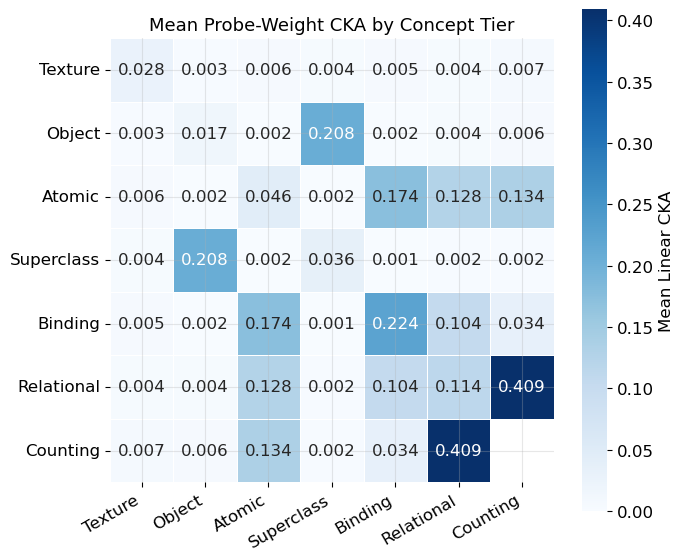

Saved cka_cleaner.png + .pdf


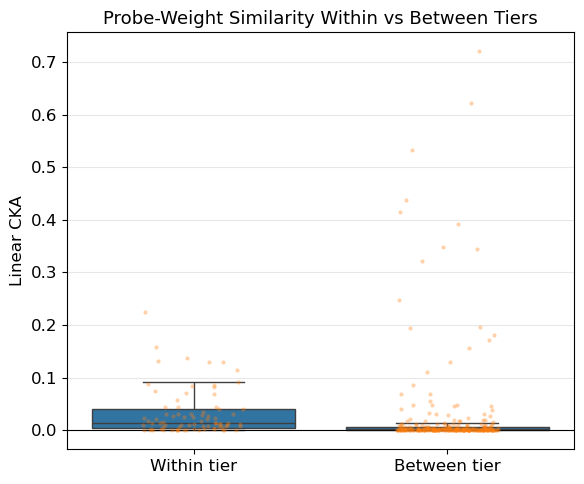


CKA Summary
              mean   std  count
Comparison                     
Between tier 0.026 0.090    271
Within tier  0.033 0.044     80

Within - between difference: +0.007


In [58]:
# ============================================================
# Cleaner CKA visualization: tier-level heatmap + summary boxplot
# ============================================================

def plot_clean_cka_summary(cka_result):
    """
    Make cleaner CKA plots from the output of compute_cka_matrix().

    cka_result should be:
        cka_sorted, names_sorted, tiers_sorted
    """
    if cka_result is None:
        print("No CKA result found.")
        return

    cka_sorted, names_sorted, tiers_sorted = cka_result

    tier_order = [
        "Texture",
        "Object",
        "Atomic",
        "Superclass",
        "Binding",
        "Relational",
        "Counting",
    ]

    tiers_present = [t for t in tier_order if t in set(tiers_sorted)]

    # --------------------------------------------------------
    # 1. Compute average CKA between tiers
    # --------------------------------------------------------
    tier_cka = pd.DataFrame(
        index=tiers_present,
        columns=tiers_present,
        dtype=float,
    )

    for tier_i in tiers_present:
        idx_i = [k for k, t in enumerate(tiers_sorted) if t == tier_i]

        for tier_j in tiers_present:
            idx_j = [k for k, t in enumerate(tiers_sorted) if t == tier_j]

            values = cka_sorted[np.ix_(idx_i, idx_j)].flatten()

            # Remove diagonal self-similarity when comparing a tier to itself
            if tier_i == tier_j:
                values = values[values < 0.999]

            tier_cka.loc[tier_i, tier_j] = np.mean(values)

    # --------------------------------------------------------
    # 2. Compute within-tier vs between-tier values
    # --------------------------------------------------------
    summary_rows = []

    for i in range(len(tiers_sorted)):
        for j in range(i + 1, len(tiers_sorted)):
            comparison = (
                "Within tier"
                if tiers_sorted[i] == tiers_sorted[j]
                else "Between tier"
            )

            summary_rows.append({
                "Comparison": comparison,
                "CKA": cka_sorted[i, j],
                "Concept 1": names_sorted[i],
                "Concept 2": names_sorted[j],
                "Tier 1": tiers_sorted[i],
                "Tier 2": tiers_sorted[j],
            })

    summary_df = pd.DataFrame(summary_rows)

    # --------------------------------------------------------
    # Plot A: tier-level heatmap
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        tier_cka,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=max(0.1, np.nanmax(tier_cka.values)),
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Mean Linear CKA"},
        ax=ax,
    )

    ax.set_title("Mean Probe-Weight CKA by Concept Tier", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Plot B: within-tier vs between-tier CKA
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.boxplot(
        data=summary_df,
        x="Comparison",
        y="CKA",
        ax=ax,
        showfliers=False,
    )

    sns.stripplot(
        data=summary_df,
        x="Comparison",
        y="CKA",
        ax=ax,
        alpha=0.35,
        jitter=0.2,
        size=3,
    )

    ax.set_title("Probe-Weight Similarity Within vs Between Tiers", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Linear CKA")
    ax.axhline(0, color="black", linewidth=0.8)

    plt.tight_layout()
    save_fig("cka_cleaner")
    plt.show()

    # --------------------------------------------------------
    # Print numerical summary
    # --------------------------------------------------------
    print("\n" + "=" * 60)
    print("CKA Summary")
    print("=" * 60)

    print(
        summary_df
        .groupby("Comparison")["CKA"]
        .agg(["mean", "std", "count"])
        .to_string(float_format="%.3f")
    )

    within_mean = summary_df.loc[
        summary_df["Comparison"] == "Within tier", "CKA"
    ].mean()

    between_mean = summary_df.loc[
        summary_df["Comparison"] == "Between tier", "CKA"
    ].mean()

    diff = within_mean - between_mean

    print(f"\nWithin - between difference: {diff:+.3f}")

    return tier_cka, summary_df


tier_cka, cka_summary_df = plot_clean_cka_summary(cka_result)

# Combined Geometry Summary

Bringing together the linearity gap, intrinsic dimensionality, silhouette score, and CKA results into a unified picture of how CLIP organises visual concepts geometrically.


Combined Geometry Summary
                Concept       Tier  Silhouette   ΔAUC  Intrinsic Dim
       has_large_object     Atomic       0.141  0.012         20.342
       has_metal_object     Atomic       0.203  0.002         19.964
         has_red_object     Atomic       0.047 -0.000         23.323
             has_sphere     Atomic       0.197 -0.000         22.256
         has_red_sphere    Binding       0.051  0.025         24.954
  red_cube_vs_blue_cube    Binding       0.038  0.007         24.675
       red_left_of_blue Relational       0.038  0.013         24.791
small_in_front_of_large Relational       0.047  0.034         21.025
          count_objects   Counting       0.032  0.019         21.426

Tier-Level Geometry Summary
            ΔAUC             Silhouette       Intrinsic Dim      
            mean   std count       mean   std          mean   std
Tier                                                             
Atomic     0.003 0.006     4      0.147 0.072        21.4

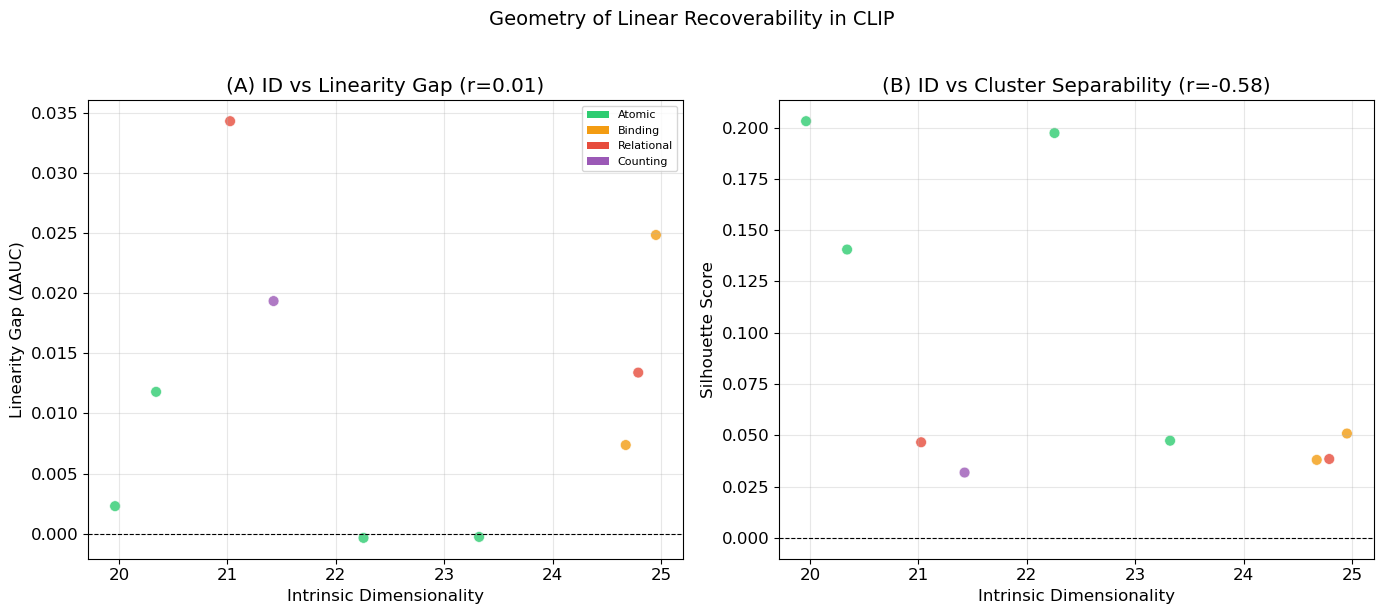

In [59]:
# ============================================================
# Merge all geometry metrics into one summary table
# ============================================================

if "id_df" not in globals() or "sil_df" not in globals():
    print("Run the intrinsic-dimensionality and silhouette cells first.")

elif len(id_df) == 0 or len(sil_df) == 0:
    print("id_df or sil_df is empty. Nothing to merge.")

else:
    tier_order = [
        "Texture",
        "Object",
        "Atomic",
        "Superclass",
        "Binding",
        "Relational",
        "Counting",
    ]

    tier_colors = {
        "Texture": "#e67e22",
        "Object": "#3498db",
        "Atomic": "#2ecc71",
        "Superclass": "#1abc9c",
        "Binding": "#f39c12",
        "Relational": "#e74c3c",
        "Counting": "#9b59b6",
    }

    # --------------------------------------------------------
    # Merge silhouette, linearity gap, and intrinsic dimension
    # --------------------------------------------------------
    geom_df = pd.merge(
        sil_df[["Concept", "Tier", "Silhouette", "ΔAUC"]],
        id_df[["Concept", "Intrinsic Dim"]],
        on="Concept",
        how="outer",
    )

    geom_df["Tier"] = pd.Categorical(
        geom_df["Tier"],
        categories=tier_order,
        ordered=True,
    )

    geom_df = geom_df.sort_values(["Tier", "Concept"]).reset_index(drop=True)

    # --------------------------------------------------------
    # Print full concept-level summary
    # --------------------------------------------------------
    print("Combined Geometry Summary")
    print("=" * 80)

    print(
        geom_df.to_string(
            index=False,
            float_format="%.3f",
        )
    )

    # --------------------------------------------------------
    # Print tier-level summary
    # --------------------------------------------------------
    print("\n" + "=" * 80)
    print("Tier-Level Geometry Summary")
    print("=" * 80)

    tier_summary = (
        geom_df
        .groupby("Tier", observed=True)
        .agg({
            "ΔAUC": ["mean", "std", "count"],
            "Silhouette": ["mean", "std"],
            "Intrinsic Dim": ["mean", "std"],
        })
    )

    print(tier_summary.to_string(float_format="%.3f"))

    # --------------------------------------------------------
    # Plot geometry relationships
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --------------------------------------------------------
    # Panel A: intrinsic dimensionality vs linearity gap
    # --------------------------------------------------------
    ax = axes[0]

    valid_gap = geom_df.dropna(subset=["ΔAUC", "Intrinsic Dim"])

    if len(valid_gap) > 1:
        colors = [
            tier_colors.get(t, "#95a5a6")
            for t in valid_gap["Tier"]
        ]

        ax.scatter(
            valid_gap["Intrinsic Dim"],
            valid_gap["ΔAUC"],
            c=colors,
            s=60,
            edgecolors="white",
            linewidths=0.5,
            alpha=0.8,
        )

        corr = np.corrcoef(
            valid_gap["Intrinsic Dim"],
            valid_gap["ΔAUC"],
        )[0, 1]

        ax.set_title(f"(A) ID vs Linearity Gap (r={corr:.2f})")

    else:
        ax.text(
            0.5,
            0.5,
            "Not enough valid points",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

        ax.set_title("(A) ID vs Linearity Gap")

    ax.set_xlabel("Intrinsic Dimensionality")
    ax.set_ylabel("Linearity Gap (ΔAUC)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    # --------------------------------------------------------
    # Panel B: intrinsic dimensionality vs silhouette score
    # --------------------------------------------------------
    ax2 = axes[1]

    valid_sil = geom_df.dropna(subset=["Silhouette", "Intrinsic Dim"])

    if len(valid_sil) > 1:
        colors = [
            tier_colors.get(t, "#95a5a6")
            for t in valid_sil["Tier"]
        ]

        ax2.scatter(
            valid_sil["Intrinsic Dim"],
            valid_sil["Silhouette"],
            c=colors,
            s=60,
            edgecolors="white",
            linewidths=0.5,
            alpha=0.8,
        )

        corr = np.corrcoef(
            valid_sil["Intrinsic Dim"],
            valid_sil["Silhouette"],
        )[0, 1]

        ax2.set_title(f"(B) ID vs Cluster Separability (r={corr:.2f})")

    else:
        ax2.text(
            0.5,
            0.5,
            "Not enough valid points",
            ha="center",
            va="center",
            transform=ax2.transAxes,
        )

        ax2.set_title("(B) ID vs Cluster Separability")

    ax2.set_xlabel("Intrinsic Dimensionality")
    ax2.set_ylabel("Silhouette Score")
    ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")

    # --------------------------------------------------------
    # Shared legend
    # --------------------------------------------------------
    tiers_in_plot = [
        tier for tier in tier_order
        if tier in geom_df["Tier"].dropna().unique()
    ]

    legend_elements = [
        mpatches.Patch(facecolor=tier_colors[tier], label=tier)
        for tier in tiers_in_plot
    ]

    axes[0].legend(
        handles=legend_elements,
        fontsize=8,
        loc="best",
    )

    plt.suptitle(
        "Geometry of Linear Recoverability in CLIP",
        fontsize=14,
        y=1.02,
    )

    plt.tight_layout()
    save_fig("combined_geometry")
    plt.show()

# Save All Results


In [62]:
SAVE_DIR = os.path.join(os.getcwd(), "results_cache")

# Everything that should be persisted
save_targets = {
    # Core probe results
    "all_results": globals().get("all_results"),
    "dtd_results": globals().get("dtd_results"),
    
    # ARO
    "aro_df": globals().get("aro_df"),
    "aro_results": globals().get("aro_results"),
    "aro_group_tables": globals().get("aro_group_tables"),
    "aro_probe_results": globals().get("aro_probe_results"),
    
    # Additivity
    "additivity_results": globals().get("additivity_results"),
    "concept_vectors": globals().get("concept_vectors"),
    "group_embeddings": globals().get("group_embeddings"),
    
    # Interaction analysis
    "interactions": globals().get("interactions"),
    
    # Geometry
    "id_df": globals().get("id_df"),
    "sil_df": globals().get("sil_df"),
    
    # Layerwise
    "layerwise_results": globals().get("layerwise_results"),
    
    # ARO per-group probes
    "vga_group_result": globals().get("vga_group_result"),
    "vgr_group_result": globals().get("vgr_group_result"),
    "vga_correct_result": globals().get("vga_correct_result"),
    "vgr_correct_result": globals().get("vgr_correct_result"),
    "vgr_per_relation_df": globals().get("vgr_per_relation_df"),
    "vga_per_attr_df": globals().get("vga_per_attr_df"),
}

os.makedirs(SAVE_DIR, exist_ok=True)

for name, obj in save_targets.items():
    path = os.path.join(SAVE_DIR, f"{name}.pkl")
    already_cached = os.path.exists(path)
    in_memory = obj is not None
    
    if in_memory and not already_cached:
        status = "⚠️  IN MEMORY BUT NOT CACHED — saving now"
        # Convert DataFrames in layerwise_results dict
        if name == "layerwise_results" and isinstance(obj, dict):
            obj = {k: v.to_dict() if hasattr(v, 'to_dict') else v for k, v in obj.items()}
        with open(path, "wb") as f:
            pickle.dump(obj, f)
    elif in_memory and already_cached:
        status = "✓  cached + in memory"
    elif not in_memory and already_cached:
        status = "✓  cached (not in memory)"
    else:
        status = "✗  missing entirely"
    
    print(f"  {name:30s} {status}")

  all_results                    ✓  cached + in memory
  dtd_results                    ✓  cached + in memory
  aro_df                         ✓  cached + in memory
  aro_results                    ✓  cached + in memory
  aro_group_tables               ✓  cached + in memory
  aro_probe_results              ✓  cached + in memory
  additivity_results             ✓  cached + in memory
  concept_vectors                ✓  cached + in memory
  group_embeddings               ✓  cached + in memory
  interactions                   ✗  missing entirely
  id_df                          ✓  cached + in memory
  sil_df                         ✓  cached + in memory
  layerwise_results              ✓  cached (not in memory)
  vga_group_result               ✓  cached + in memory
  vgr_group_result               ✓  cached + in memory
  vga_correct_result             ✓  cached + in memory
  vgr_correct_result             ✓  cached + in memory
  vgr_per_relation_df            ✓  cached + in memory
  vga_pe

In [61]:
# ============================================================
# Final persistence — save all results including geometry analysis
# ============================================================

SAVE_DIR = os.path.join(os.getcwd(), "results_cache")
os.makedirs(SAVE_DIR, exist_ok=True)

save_objects = {
    "all_results": all_results,
    "aro_df": aro_df if "aro_df" in dir() else None,
    "aro_results": aro_results if "aro_results" in dir() else None,
    "aro_group_tables": aro_group_tables if "aro_group_tables" in dir() else None,
    "dtd_results": dtd_results if "dtd_results" in dir() else None,
    "id_df": id_df if "id_df" in dir() else None,
    "sil_df": sil_df if "sil_df" in dir() else None,
}

for name, obj in save_objects.items():
    if obj is not None:
        with open(f"{SAVE_DIR}/{name}.pkl", "wb") as f:
            pickle.dump(obj, f)
        print(f"Saved {name}")

if os.path.exists("feature_cache"):
    shutil.copytree("feature_cache", f"{SAVE_DIR}/feature_cache", dirs_exist_ok=True)
    print(f"Saved feature_cache ({len(os.listdir('feature_cache'))} files)")

print("\nDone — all saved to", SAVE_DIR)


Saved all_results
Saved aro_df
Saved aro_results
Saved aro_group_tables
Saved dtd_results
Saved id_df
Saved sil_df
Saved feature_cache (39 files)

Done — all saved to /home/ayela/CV/results_cache


# Layer-wise Linear Recoverability

In [65]:
# ============================================================
# Extract features from every ViT transformer block
# ============================================================

def extract_layerwise_features(images, batch_size=64):
    """
    Extract features from every transformer block of CLIP ViT,
    replicating the exact forward path: _embeds → transformer blocks → ln_post → CLS pool → proj → L2 norm
    """
    visual = model.visual
    n_layers = len(visual.transformer.resblocks)
    proj = visual.proj
    
    layer_features = {i: [] for i in range(n_layers + 1)}
    
    for start in tqdm(range(0, len(images), batch_size), desc="Extracting layerwise"):
        batch = images[start:start + batch_size]
        batch_tensors = torch.stack([preprocess(img) for img in batch]).to(device)
        
        with torch.no_grad():
            # _embeds: conv1 → reshape → CLS prepend → pos embed → patch_dropout → ln_pre
            x = visual._embeds(batch_tensors)  # (B, seq_len, 768)
            
            # Layer 0: pre-transformer
            pooled = visual.ln_post(x)[:, 0]  # CLS token after ln_post
            if proj is not None:
                pooled = pooled @ proj
            pooled = pooled / pooled.norm(dim=-1, keepdim=True)
            layer_features[0].append(pooled.cpu().numpy())
            
            # Each transformer block
            for i, block in enumerate(visual.transformer.resblocks):
                x = block(x)
                
                pooled = visual.ln_post(x)[:, 0]  # CLS token after ln_post
                if proj is not None:
                    pooled = pooled @ proj
                pooled = pooled / pooled.norm(dim=-1, keepdim=True)
                layer_features[i + 1].append(pooled.cpu().numpy())
    
    return {k: np.concatenate(v, axis=0) for k, v in layer_features.items()}

In [66]:
# ============================================================
# Load all concepts for layerwise probing
# ============================================================

layerwise_data = {}

# --- CLEVR: all tiers ---
clevr_layerwise = {
    'has_red_object': has_red_object,
    'has_sphere': has_sphere,
    'has_large_object': has_large_object,
    'has_metal_object': has_metal_object,
    'has_red_sphere': has_red_sphere,
    'red_cube_vs_blue_cube': red_cube_vs_blue_cube,
    'red_left_of_blue': red_left_of_blue,
    'small_in_front_of_large': object_in_front,
    'count_objects': count_objects,
}

for name, labeler in clevr_layerwise.items():
    print(f"Loading CLEVR: {name}...")
    images, labels = load_clevr_concept(clevr_scenes, labeler)
    layerwise_data[name] = (images, labels)

# --- ImageNet-Mini: all concepts ---
imagenet_layerwise = {
    'imagenetmini_has_dog': imagenet_is_dog,
    'imagenetmini_has_bird': imagenet_is_bird,
    'imagenetmini_has_vehicle': imagenet_is_vehicle,
    'imagenetmini_dog_vs_cat': imagenet_dog_vs_cat,
    'imagenetmini_bird_vs_insect': imagenet_bird_vs_insect,
    'imagenetmini_animal_vs_vehicle': imagenet_animal_vs_vehicle,
    'imagenetmini_supercategory_4way': imagenet_supercategory_4way,
}

for name, labeler in imagenet_layerwise.items():
    print(f"Loading ImageNet: {name}...")
    images, labels = load_imagenetmini_concept(
        labeler, root=IMAGENET_MINI_ROOT, split="val",
        max_per_class=500, seed=42,
    )
    layerwise_data[name] = (images, labels)

# --- DTD: all 12 textures ---
dtd_layerwise = [
    'striped', 'dotted', 'chequered', 'zigzagged', 'woven',
    'knitted', 'scaly', 'cracked', 'bumpy', 'marbled', 'porous', 'wrinkled',
]

for texture in dtd_layerwise:
    name = f"dtd_has_{texture}"
    print(f"Loading DTD: {name}...")
    images, labels = load_dtd_concept(target_texture=texture, splits=("train", "val", "test"), seed=42)
    layerwise_data[name] = (images, labels)

print(f"\nTotal concepts for layerwise probing: {len(layerwise_data)}")

Loading CLEVR: has_red_object...
  Classes found: [0, 1]
  Raw counts: {0: 6514, 1: 8486}
  Using 500 per class
Loading CLEVR: has_sphere...
  Classes found: [1, 0]
  Raw counts: {0: 1644, 1: 13356}
  Using 500 per class
Loading CLEVR: has_large_object...
  Classes found: [1, 0]
  Raw counts: {0: 516, 1: 14484}
  Using 500 per class
Loading CLEVR: has_metal_object...
  Classes found: [1, 0]
  Raw counts: {0: 435, 1: 14565}
  Using 435 per class
Loading CLEVR: has_red_sphere...
  Classes found: [0, 1]
  Raw counts: {0: 11365, 1: 3635}
  Using 500 per class
Loading CLEVR: red_cube_vs_blue_cube...
  Classes found: [1, 0]
  Raw counts: {0: 2756, 1: 2736}
  Using 500 per class
Loading CLEVR: red_left_of_blue...
  Classes found: [0, 1]
  Raw counts: {0: 12047, 1: 2953}
  Using 500 per class
Loading CLEVR: small_in_front_of_large...
  Classes found: [1, 0]
  Raw counts: {0: 2308, 1: 12692}
  Using 500 per class
Loading CLEVR: count_objects...
  Classes found: [1, 2, 0]
  Raw counts: {0: 1898,

In [67]:
# ============================================================
# Extract layerwise features for each concept and probe
# ============================================================

layerwise_results = {}

for concept_name, (images, labels) in layerwise_data.items():
    print(f"\n{'='*60}")
    print(f"Layerwise probing: {concept_name}")
    print(f"{'='*60}")
    
    cache_path = f"feature_cache/layerwise_{concept_name}.npz"
    
    if os.path.exists(cache_path):
        print(f"Loading cached layerwise features...")
        cached = np.load(cache_path, allow_pickle=True)
        layer_feats = {int(k): cached[k] for k in cached.files}
    else:
        layer_feats = extract_layerwise_features(images)
        np.savez(cache_path, **{str(k): v for k, v in layer_feats.items()})
        print(f"Cached to {cache_path}")
    
    n_layers = len(layer_feats)
    concept_results = []
    
    for layer_idx in range(n_layers):
        feats = layer_feats[layer_idx]
        
        lin_acc, lin_std, lin_auc, lin_auc_std = run_linear_probe_cv(feats, labels)
        
        # Just run the 2-layer MLP as representative nonlinear probe
        mlp_acc, mlp_std, mlp_auc, mlp_auc_std = run_mlp_probe_cv(
            feats, labels, hidden_layers=(128, 64)
        )
        
        concept_results.append({
            'layer': layer_idx,
            'linear_acc': lin_acc,
            'linear_auc': lin_auc,
            'mlp_acc': mlp_acc,
            'mlp_auc': mlp_auc,
            'gap': mlp_auc - lin_auc,
        })
        
        print(f"  Layer {layer_idx:2d}  |  lin_auc={lin_auc:.3f}  mlp_auc={mlp_auc:.3f}  Δ={mlp_auc - lin_auc:+.3f}")
    
    layerwise_results[concept_name] = pd.DataFrame(concept_results)


Layerwise probing: has_red_object
Loading cached layerwise features...
  Layer  0  |  lin_auc=0.500  mlp_auc=0.500  Δ=+0.000
  Layer  1  |  lin_auc=0.651  mlp_auc=0.645  Δ=-0.006
  Layer  2  |  lin_auc=0.724  mlp_auc=0.738  Δ=+0.014
  Layer  3  |  lin_auc=0.775  mlp_auc=0.854  Δ=+0.080
  Layer  4  |  lin_auc=0.783  mlp_auc=0.905  Δ=+0.122
  Layer  5  |  lin_auc=0.805  mlp_auc=0.920  Δ=+0.115
  Layer  6  |  lin_auc=0.791  mlp_auc=0.948  Δ=+0.157
  Layer  7  |  lin_auc=0.826  mlp_auc=0.973  Δ=+0.147
  Layer  8  |  lin_auc=0.849  mlp_auc=0.978  Δ=+0.129
  Layer  9  |  lin_auc=0.815  mlp_auc=0.951  Δ=+0.136
  Layer 10  |  lin_auc=0.799  mlp_auc=0.968  Δ=+0.169
  Layer 11  |  lin_auc=0.829  mlp_auc=0.986  Δ=+0.157
  Layer 12  |  lin_auc=0.994  mlp_auc=0.994  Δ=-0.000

Layerwise probing: has_sphere
Loading cached layerwise features...
  Layer  0  |  lin_auc=0.500  mlp_auc=0.500  Δ=+0.000
  Layer  1  |  lin_auc=0.727  mlp_auc=0.729  Δ=+0.001
  Layer  2  |  lin_auc=0.755  mlp_auc=0.752  Δ=-0.

Saved layerwise_line_plots.png + .pdf


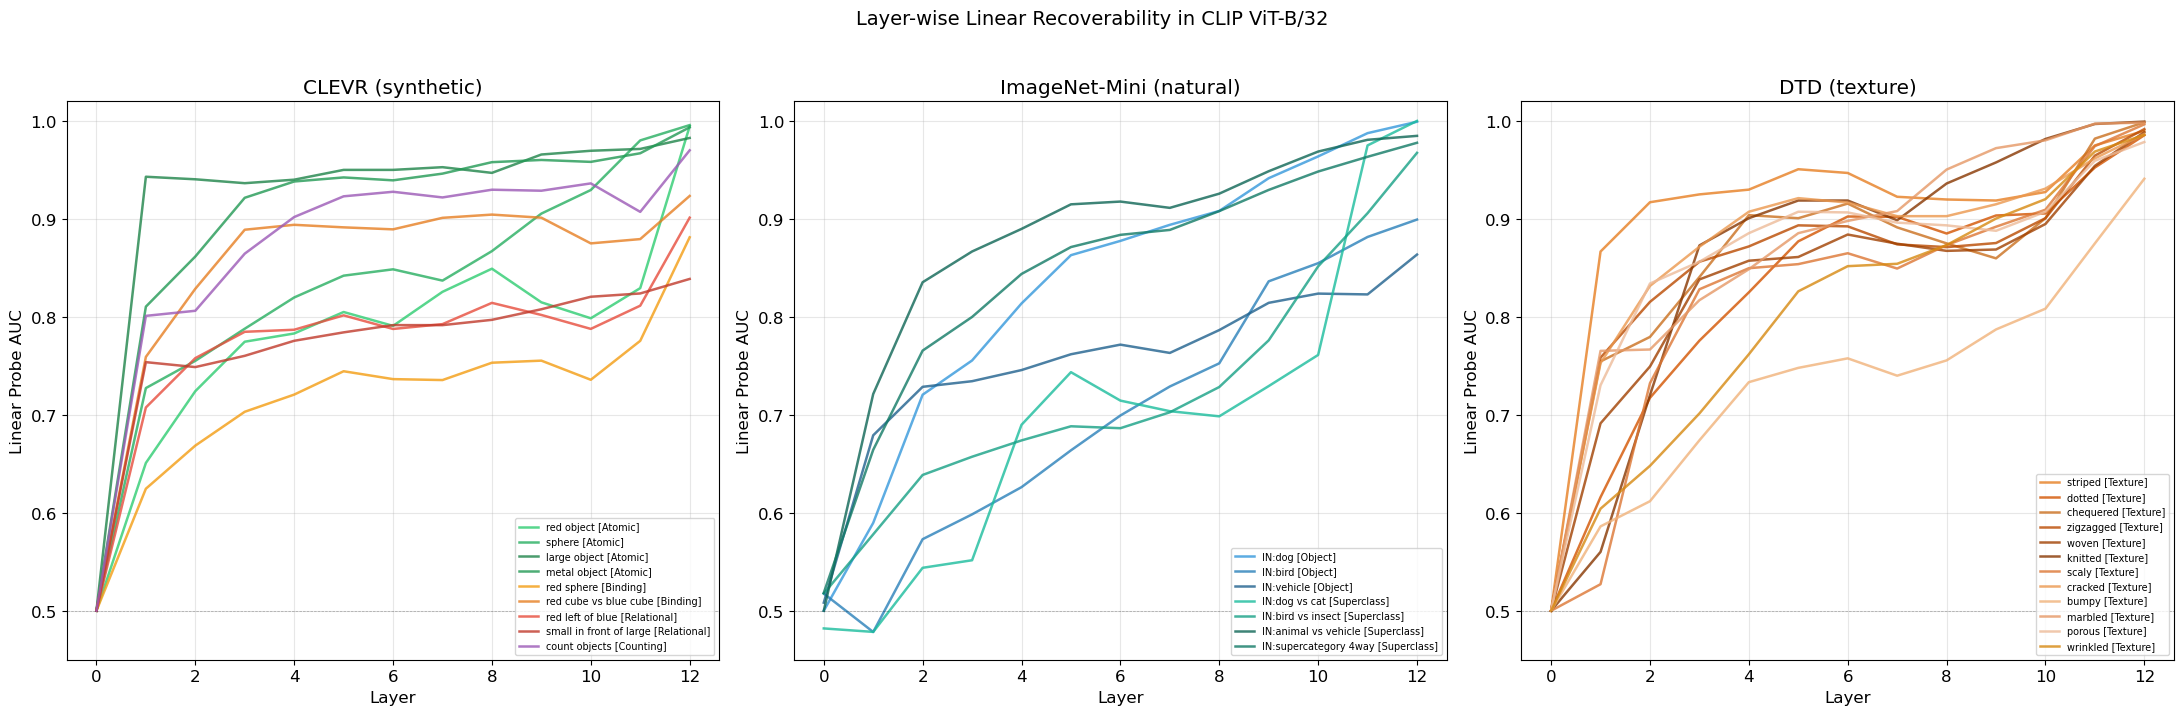

Saved layerwise_heatmaps.png + .pdf


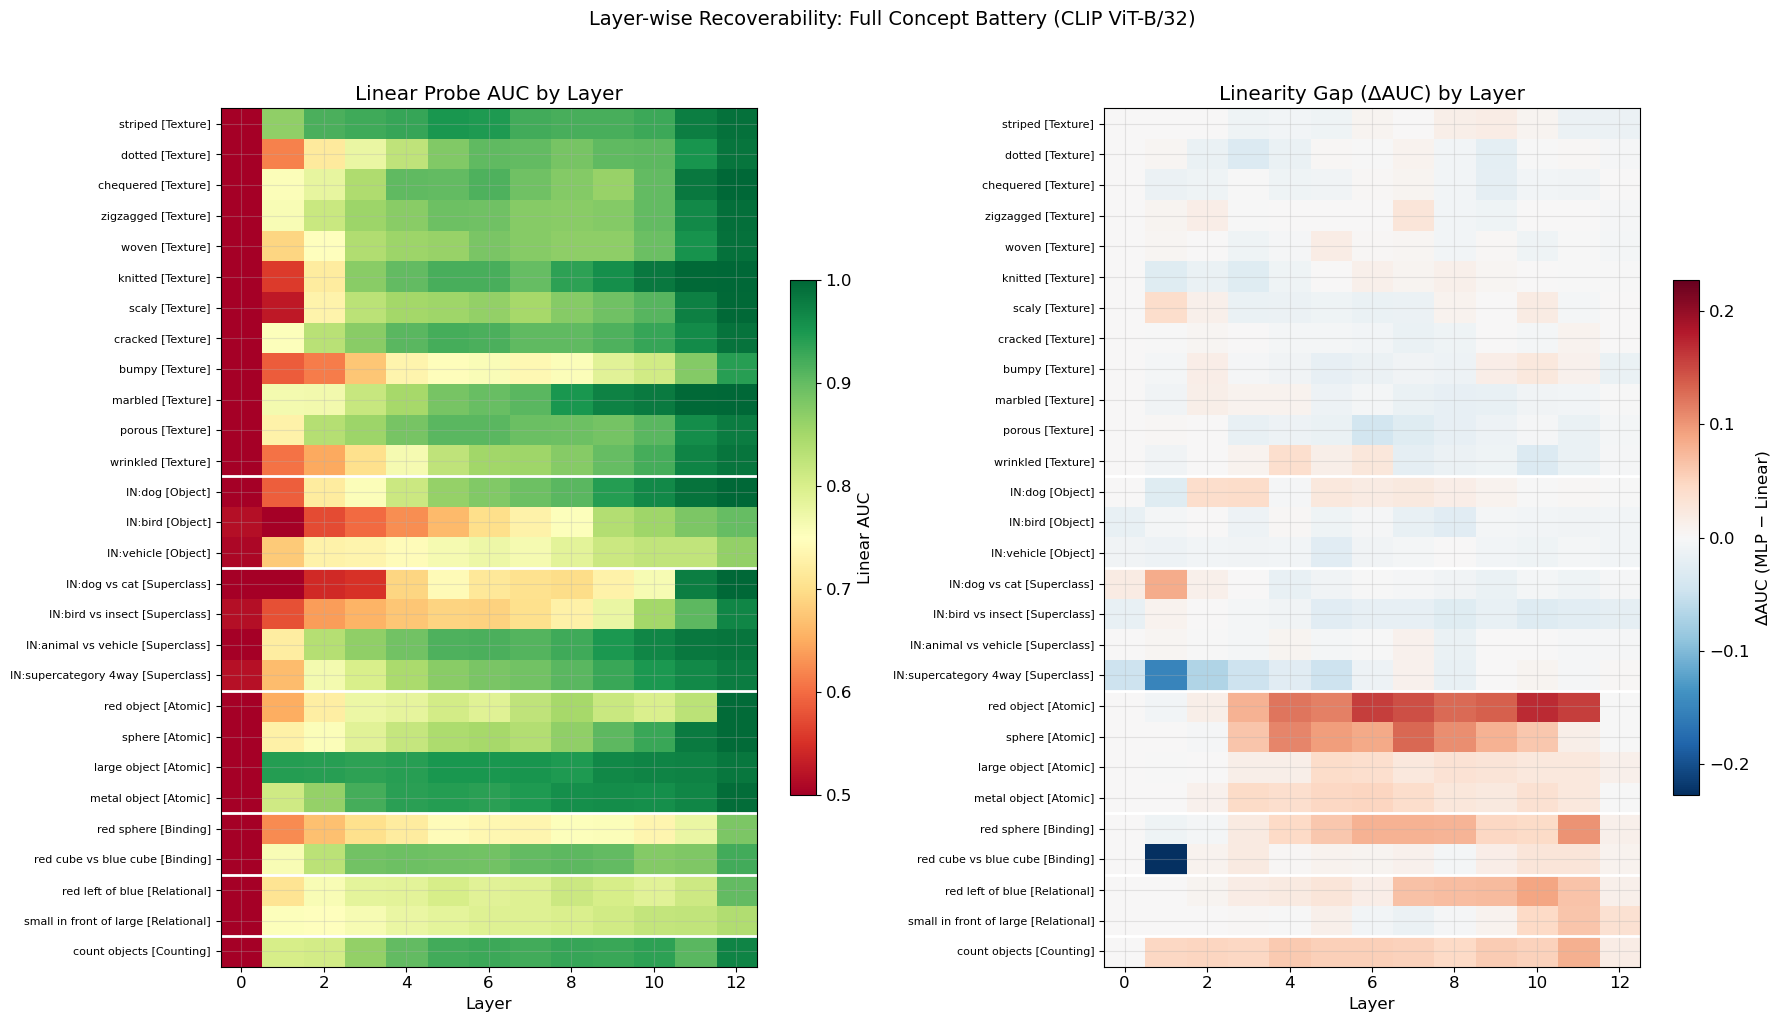


Layer at which linear probe AUC first exceeds 0.9
  dtd_has_striped                          [Texture   ]  layer  2
  dtd_has_dotted                           [Texture   ]  layer  6
  dtd_has_chequered                        [Texture   ]  layer  4
  dtd_has_zigzagged                        [Texture   ]  layer 10
  dtd_has_woven                            [Texture   ]  layer 11
  dtd_has_knitted                          [Texture   ]  layer  4
  dtd_has_scaly                            [Texture   ]  layer 10
  dtd_has_cracked                          [Texture   ]  layer  4
  dtd_has_bumpy                            [Texture   ]  layer 12
  dtd_has_marbled                          [Texture   ]  layer  7
  dtd_has_porous                           [Texture   ]  layer  5
  dtd_has_wrinkled                         [Texture   ]  layer  9
  imagenetmini_has_dog                     [Object    ]  layer  8
  imagenetmini_has_bird                    [Object    ]  never (peak 0.899)
  imagenetmini_

In [68]:
# ============================================================
# Plot: layer-wise recoverability curves (full battery)
# ============================================================

tier_map = {
    # CLEVR
    'has_red_object':            ('Atomic',      '#2ecc71'),
    'has_sphere':                ('Atomic',      '#27ae60'),
    'has_large_object':          ('Atomic',      '#1e8449'),
    'has_metal_object':          ('Atomic',      '#229954'),
    'has_red_sphere':            ('Binding',     '#f39c12'),
    'red_cube_vs_blue_cube':     ('Binding',     '#e67e22'),
    'red_left_of_blue':          ('Relational',  '#e74c3c'),
    'small_in_front_of_large':   ('Relational',  '#c0392b'),
    'count_objects':             ('Counting',    '#9b59b6'),
    # ImageNet
    'imagenetmini_has_dog':             ('Object',     '#3498db'),
    'imagenetmini_has_bird':            ('Object',     '#2980b9'),
    'imagenetmini_has_vehicle':         ('Object',     '#1f618d'),
    'imagenetmini_dog_vs_cat':          ('Superclass', '#1abc9c'),
    'imagenetmini_bird_vs_insect':      ('Superclass', '#16a085'),
    'imagenetmini_animal_vs_vehicle':   ('Superclass', '#0e6655'),
    'imagenetmini_supercategory_4way':  ('Superclass', '#117a65'),
    # DTD
    'dtd_has_striped':    ('Texture', '#e67e22'),
    'dtd_has_dotted':     ('Texture', '#d35400'),
    'dtd_has_chequered':  ('Texture', '#ca6f1e'),
    'dtd_has_zigzagged':  ('Texture', '#ba4a00'),
    'dtd_has_woven':      ('Texture', '#a04000'),
    'dtd_has_knitted':    ('Texture', '#873600'),
    'dtd_has_scaly':      ('Texture', '#dc7633'),
    'dtd_has_cracked':    ('Texture', '#eb984e'),
    'dtd_has_bumpy':      ('Texture', '#f0b27a'),
    'dtd_has_marbled':    ('Texture', '#e59866'),
    'dtd_has_porous':     ('Texture', '#edbb99'),
    'dtd_has_wrinkled':   ('Texture', '#d68910'),
}

# --- Figure 1: Line plots, one panel per dataset ---

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

dataset_groups = {
    'CLEVR (synthetic)': [k for k in layerwise_results if k.startswith('has_') or k.startswith('red_') or k.startswith('small_') or k == 'count_objects'],
    'ImageNet-Mini (natural)': [k for k in layerwise_results if k.startswith('imagenetmini_')],
    'DTD (texture)': [k for k in layerwise_results if k.startswith('dtd_')],
}

for ax, (dataset_title, concepts) in zip(axes, dataset_groups.items()):
    for concept in concepts:
        df = layerwise_results[concept]
        tier_name, color = tier_map[concept]
        short = concept.replace('imagenetmini_', 'IN:').replace('dtd_has_', '').replace('has_', '').replace('_', ' ')
        ax.plot(df['layer'], df['linear_auc'], color=color, linewidth=1.8,
                alpha=0.8, label=f"{short} [{tier_name}]")
    ax.set_xlabel('Layer')
    ax.set_ylabel('Linear Probe AUC')
    ax.set_title(dataset_title)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_ylim(0.45, 1.02)
    ax.axhline(y=0.5, color='black', linewidth=0.5, linestyle='--', alpha=0.3)

plt.suptitle('Layer-wise Linear Recoverability in CLIP ViT-B/32', fontsize=14, y=1.02)
plt.tight_layout()
save_fig("layerwise_line_plots")
plt.show()


# --- Figure 2: Full heatmap ---

concept_order = (
    [c for c in layerwise_results if c.startswith('dtd_')] +
    [c for c in layerwise_results if c.startswith('imagenetmini_')] +
    ['has_red_object', 'has_sphere', 'has_large_object', 'has_metal_object',
     'has_red_sphere', 'red_cube_vs_blue_cube',
     'red_left_of_blue', 'small_in_front_of_large',
     'count_objects']
)
concept_order = [c for c in concept_order if c in layerwise_results]

short_labels = {}
for c in concept_order:
    tier_name = tier_map[c][0]
    short = c.replace('imagenetmini_', 'IN:').replace('dtd_has_', '').replace('has_', '').replace('_', ' ')
    short_labels[c] = f"{short} [{tier_name}]"

heatmap_data = np.array([
    layerwise_results[c]['linear_auc'].values for c in concept_order
])

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Panel A: Linear AUC
ax = axes[0]
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xlabel('Layer')
ax.set_yticks(range(len(concept_order)))
ax.set_yticklabels([short_labels[c] for c in concept_order], fontsize=8)
ax.set_title('Linear Probe AUC by Layer')
plt.colorbar(im, ax=ax, label='Linear AUC', shrink=0.6)

# Tier separators
prev_tier = None
for i, c in enumerate(concept_order):
    t = tier_map[c][0]
    if t != prev_tier and prev_tier is not None:
        ax.axhline(y=i - 0.5, color='white', linewidth=2)
    prev_tier = t

# Panel B: Linearity gap
gap_data = np.array([
    layerwise_results[c]['gap'].values for c in concept_order
])

ax2 = axes[1]
max_gap = max(0.05, np.nanmax(np.abs(gap_data)))
im2 = ax2.imshow(gap_data, aspect='auto', cmap='RdBu_r', vmin=-max_gap, vmax=max_gap)
ax2.set_xlabel('Layer')
ax2.set_yticks(range(len(concept_order)))
ax2.set_yticklabels([short_labels[c] for c in concept_order], fontsize=8)
ax2.set_title('Linearity Gap (ΔAUC) by Layer')
plt.colorbar(im2, ax=ax2, label='ΔAUC (MLP − Linear)', shrink=0.6)

prev_tier = None
for i, c in enumerate(concept_order):
    t = tier_map[c][0]
    if t != prev_tier and prev_tier is not None:
        ax2.axhline(y=i - 0.5, color='white', linewidth=2)
    prev_tier = t

plt.suptitle('Layer-wise Recoverability: Full Concept Battery (CLIP ViT-B/32)', fontsize=14, y=1.02)
plt.tight_layout()
save_fig("layerwise_heatmaps")
plt.show()


# --- Summary stats: at which layer does each concept cross 0.9 AUC? ---

print(f"\n{'='*60}")
print("Layer at which linear probe AUC first exceeds 0.9")
print(f"{'='*60}")

for concept in concept_order:
    df = layerwise_results[concept]
    tier_name = tier_map[concept][0]
    crossed = df[df['linear_auc'] >= 0.9]
    if len(crossed) > 0:
        first_layer = crossed['layer'].iloc[0]
        print(f"  {concept:40s} [{tier_name:10s}]  layer {first_layer:2d}")
    else:
        peak = df['linear_auc'].max()
        print(f"  {concept:40s} [{tier_name:10s}]  never (peak {peak:.3f})")

# Residual Analysis

In [69]:
# ============================================================
# Deep dive: why are cross-shape residuals anti-correlated?
#
# If v_red is the concept vector for "red", and we predict
# z(red, cube) = z(*, cube) + v_red, the residual tells us
# what the linear model misses. Anti-correlation across shapes
# means: when the model over-shoots for cubes, it under-shoots
# for spheres by a similar amount. This implies a systematic
# color×shape interaction term that the additive model ignores.
# ============================================================

def deep_residual_analysis(group_embeddings):
    """
    Decompose the embedding space into additive and interaction components.
    
    Full decomposition:
      z(color, shape) = grand_mean + v_color + v_shape + interaction(color, shape)
    
    The interaction term is exactly the residual from the additive model.
    If linear representation holds, interaction ≈ 0.
    """
    colors = sorted(set(k[0] for k in group_embeddings))
    shapes = sorted(set(k[1] for k in group_embeddings))
    
    # Grand mean
    grand_mean = np.mean(list(group_embeddings.values()), axis=0)
    
    # Color marginals (centered)
    color_vecs = {}
    for color in colors:
        vecs = [group_embeddings[(color, s)] for s in shapes if (color, s) in group_embeddings]
        if len(vecs) >= 2:
            color_vecs[color] = np.mean(vecs, axis=0) - grand_mean
    
    # Shape marginals (centered)
    shape_vecs = {}
    for shape in shapes:
        vecs = [group_embeddings[(c, shape)] for c in colors if (c, shape) in group_embeddings]
        if len(vecs) >= 2:
            shape_vecs[shape] = np.mean(vecs, axis=0) - grand_mean
    
    # Interaction terms: what's left after subtracting the additive model
    interactions = {}
    for color in colors:
        if color not in color_vecs:
            continue
        for shape in shapes:
            if (color, shape) not in group_embeddings or shape not in shape_vecs:
                continue
            z_actual = group_embeddings[(color, shape)]
            z_additive = grand_mean + color_vecs[color] + shape_vecs[shape]
            interactions[(color, shape)] = z_actual - z_additive
    
    # --- Analysis 1: Variance decomposition ---
    # How much of the total variance is explained by color, shape, and interaction?
    all_vecs = np.stack(list(group_embeddings.values()))
    total_var = np.sum(np.var(all_vecs, axis=0))
    
    color_contrib = np.stack(list(color_vecs.values()))
    shape_contrib = np.stack(list(shape_vecs.values()))
    inter_contrib = np.stack(list(interactions.values()))
    
    # Weight by number of times each appears
    color_var = np.sum(np.var(color_contrib, axis=0)) * len(shapes) / len(all_vecs)
    shape_var = np.sum(np.var(shape_contrib, axis=0)) * len(colors) / len(all_vecs)
    inter_var = np.sum(np.var(inter_contrib, axis=0))
    
    # Simpler: just report norms
    color_norm = np.mean([np.linalg.norm(v) for v in color_vecs.values()])
    shape_norm = np.mean([np.linalg.norm(v) for v in shape_vecs.values()])
    inter_norm = np.mean([np.linalg.norm(v) for v in interactions.values()])
    
    print("=" * 60)
    print("Variance Decomposition: z = grand_mean + v_color + v_shape + interaction")
    print("=" * 60)
    print(f"  Mean ||v_color||:      {color_norm:.4f}")
    print(f"  Mean ||v_shape||:      {shape_norm:.4f}")
    print(f"  Mean ||interaction||:  {inter_norm:.4f}")
    print(f"  Ratio interaction/color: {inter_norm/color_norm:.3f}")
    print(f"  Ratio interaction/shape: {inter_norm/shape_norm:.3f}")
    
    # --- Analysis 2: Interaction structure ---
    # Do interaction terms cluster by color or shape?
    print(f"\n{'='*60}")
    print("Interaction term structure")
    print(f"{'='*60}")
    
    # For each color, compute pairwise cosine sim of interaction vectors across shapes
    print("\nWithin-color consistency of interactions:")
    for color in colors:
        inter_vecs = [interactions[(color, s)] for s in shapes if (color, s) in interactions]
        if len(inter_vecs) >= 2:
            inter_vecs_normed = np.stack([v / (np.linalg.norm(v) + 1e-10) for v in inter_vecs])
            sim = cosine_similarity(inter_vecs_normed)
            n = len(sim)
            off_diag = [sim[i, j] for i in range(n) for j in range(i + 1, n)]
            print(f"  {color:8s}: mean cosine = {np.mean(off_diag):+.3f}  (this is what's -0.5)")
    
    # For each shape, same thing across colors
    print("\nWithin-shape consistency of interactions:")
    for shape in shapes:
        inter_vecs = [interactions[(c, shape)] for c in colors if (c, shape) in interactions]
        if len(inter_vecs) >= 2:
            inter_vecs_normed = np.stack([v / (np.linalg.norm(v) + 1e-10) for v in inter_vecs])
            sim = cosine_similarity(inter_vecs_normed)
            n = len(sim)
            off_diag = [sim[i, j] for i in range(n) for j in range(i + 1, n)]
            print(f"  {shape:8s}: mean cosine = {np.mean(off_diag):+.3f}")
    
    # --- Analysis 3: PCA of interaction terms ---
    # If interactions are low-rank, they live in a small subspace
    # = structured non-additivity
    print(f"\n{'='*60}")
    print("PCA of interaction terms")
    print(f"{'='*60}")
    
    inter_matrix = np.stack(list(interactions.values()))
    inter_centered = inter_matrix - inter_matrix.mean(axis=0)
    
    U, S, Vt = np.linalg.svd(inter_centered, full_matrices=False)
    explained = (S ** 2) / (S ** 2).sum()
    cumulative = np.cumsum(explained)
    
    print(f"  Top singular values: {S[:10].round(4)}")
    print(f"  Variance explained by top 1 PC: {explained[0]:.3f}")
    print(f"  Variance explained by top 3 PC: {cumulative[2]:.3f}")
    print(f"  Variance explained by top 5 PC: {cumulative[4]:.3f}")
    print(f"  Effective rank (90% var): {np.searchsorted(cumulative, 0.9) + 1}")
    
    return interactions, color_vecs, shape_vecs, inter_matrix, S, explained


interactions, color_vecs, shape_vecs, inter_matrix, S, explained = deep_residual_analysis(group_embeddings)

Variance Decomposition: z = grand_mean + v_color + v_shape + interaction
  Mean ||v_color||:      0.0530
  Mean ||v_shape||:      0.0466
  Mean ||interaction||:  0.0421
  Ratio interaction/color: 0.793
  Ratio interaction/shape: 0.903

Interaction term structure

Within-color consistency of interactions:
  blue    : mean cosine = -0.497  (this is what's -0.5)
  brown   : mean cosine = -0.500  (this is what's -0.5)
  cyan    : mean cosine = -0.495  (this is what's -0.5)
  gray    : mean cosine = -0.494  (this is what's -0.5)
  green   : mean cosine = -0.485  (this is what's -0.5)
  purple  : mean cosine = -0.497  (this is what's -0.5)
  red     : mean cosine = -0.488  (this is what's -0.5)
  yellow  : mean cosine = -0.500  (this is what's -0.5)

Within-shape consistency of interactions:
  cube    : mean cosine = -0.141
  cylinder: mean cosine = -0.142
  sphere  : mean cosine = -0.141

PCA of interaction terms
  Top singular values: [0.0915 0.0824 0.0704 0.065  0.0565 0.0493 0.049  0.047

Saved interaction_structure.png + .pdf


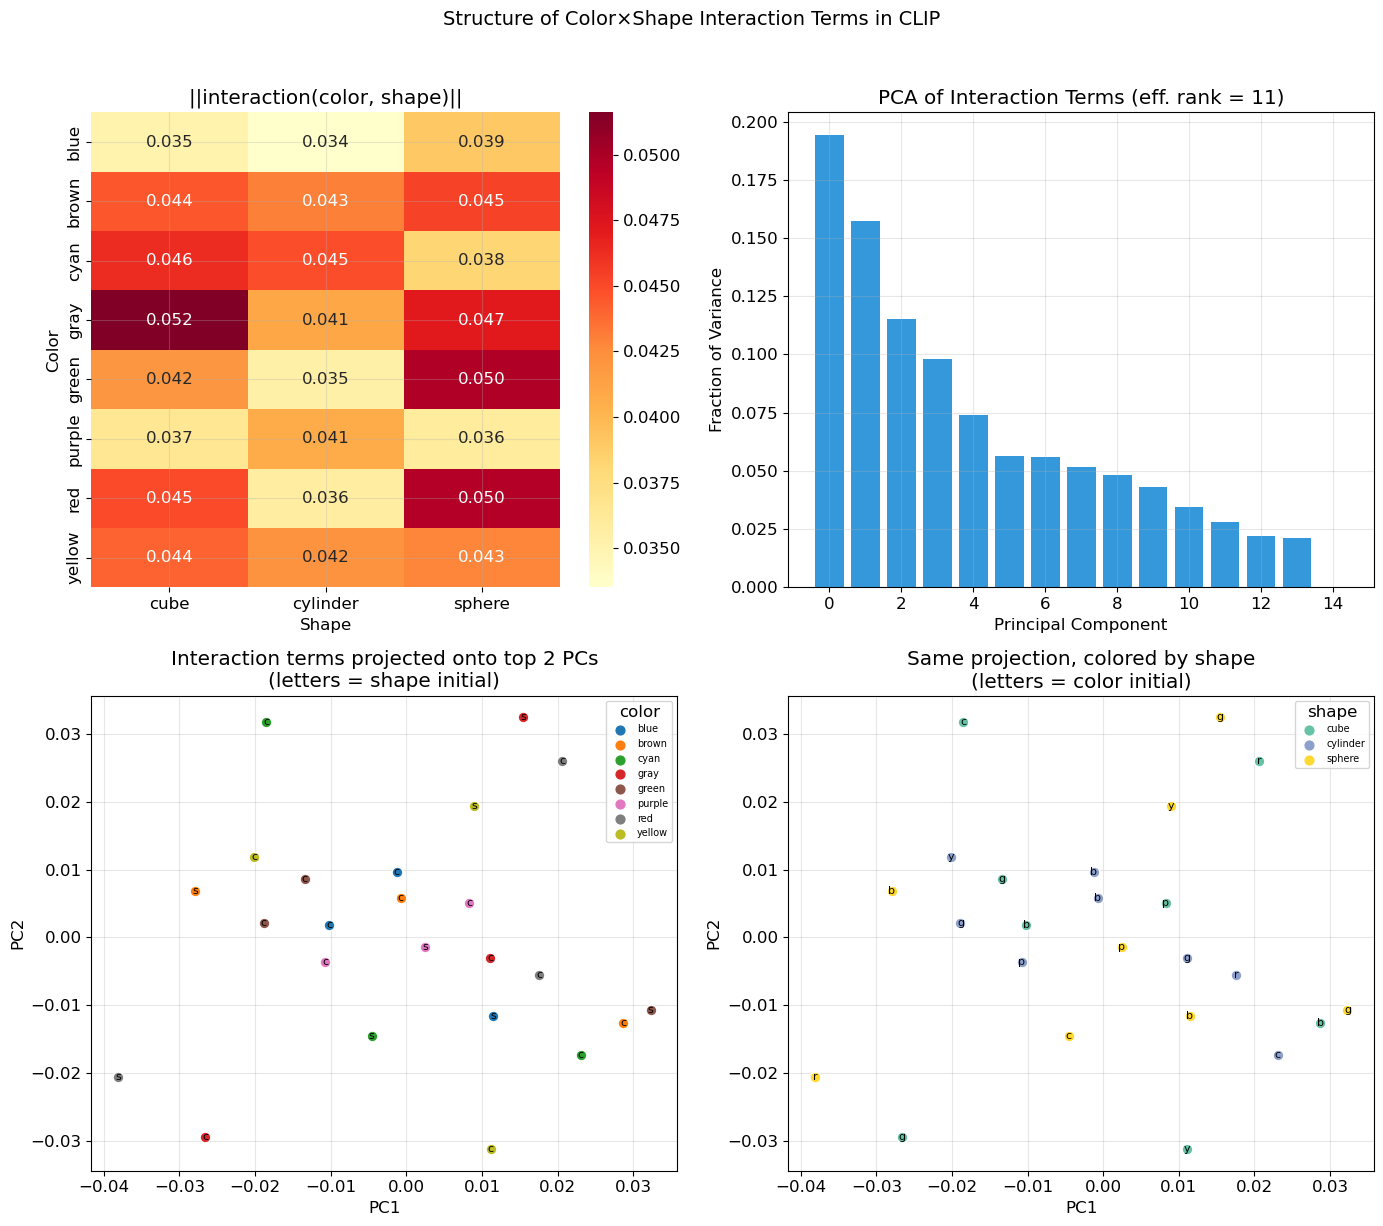

In [70]:
# ============================================================
# Visualise interaction structure
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors_list = sorted(set(k[0] for k in interactions))
shapes_list = sorted(set(k[1] for k in interactions))

# --- Panel A: Interaction norm heatmap ---
ax = axes[0, 0]
inter_norms = np.array([
    [np.linalg.norm(interactions.get((c, s), np.zeros(1))) for s in shapes_list]
    for c in colors_list
])
sns.heatmap(inter_norms, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=shapes_list, yticklabels=colors_list, ax=ax)
ax.set_title('||interaction(color, shape)||')
ax.set_ylabel('Color')
ax.set_xlabel('Shape')

# --- Panel B: PCA scree plot ---
ax2 = axes[0, 1]
ax2.bar(range(min(15, len(explained))), explained[:15], color='#3498db')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Fraction of Variance')
ax2.set_title(f'PCA of Interaction Terms (eff. rank = {np.searchsorted(np.cumsum(explained), 0.9) + 1})')

# --- Panel C: Project interactions onto top 2 PCs, color by color ---
ax3 = axes[1, 0]
inter_centered = inter_matrix - inter_matrix.mean(axis=0)
U, S_vals, Vt = np.linalg.svd(inter_centered, full_matrices=False)
projected = inter_centered @ Vt[:2].T

cmap = plt.cm.tab10
keys = list(interactions.keys())
for i, (color, shape) in enumerate(keys):
    c_idx = colors_list.index(color)
    ax3.scatter(projected[i, 0], projected[i, 1], color=cmap(c_idx / len(colors_list)),
                s=60, edgecolors='white', zorder=3)
    ax3.annotate(f"{shape[0]}", (projected[i, 0], projected[i, 1]),
                 fontsize=8, ha='center', va='center')

# Legend for colors
for i, color in enumerate(colors_list):
    ax3.scatter([], [], color=cmap(i / len(colors_list)), s=40, label=color)
ax3.legend(fontsize=7, title='color', loc='best')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('Interaction terms projected onto top 2 PCs\n(letters = shape initial)')

# --- Panel D: Project interactions onto top 2 PCs, color by shape ---
ax4 = axes[1, 1]
shape_cmap = plt.cm.Set2
for i, (color, shape) in enumerate(keys):
    s_idx = shapes_list.index(shape)
    ax4.scatter(projected[i, 0], projected[i, 1], color=shape_cmap(s_idx / len(shapes_list)),
                s=60, edgecolors='white', zorder=3)
    ax4.annotate(f"{color[0]}", (projected[i, 0], projected[i, 1]),
                 fontsize=8, ha='center', va='center')

for i, shape in enumerate(shapes_list):
    ax4.scatter([], [], color=shape_cmap(i / len(shapes_list)), s=40, label=shape)
ax4.legend(fontsize=7, title='shape', loc='best')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_title('Same projection, colored by shape\n(letters = color initial)')

plt.suptitle('Structure of Color×Shape Interaction Terms in CLIP', fontsize=14, y=1.02)
plt.tight_layout()
save_fig("interaction_structure")
plt.show()